# ✈️ NASA C-MAPSS FD002 — EDA + 전처리 파이프라인

---
**목적:** 전처리 전 EDA → 결정 1~5 적용 → 전처리 후 검증 → CSV 저장  
**대상:** FD002 (6가지 운전 조건, HPC 열화만)  
**FD001과의 차이:** 운전 조건이 6가지라 센서값에 조건 영향이 섞여있어 클러스터별 정규화 필요  
**출력:** `preprocessed/FD002_dl_subtrain_long.csv` / `FD002_dl_valid_long.csv` / `FD002_dl_test_long.csv`

---
### 노트북 흐름
```
[0] 환경 설정 (FD001과 동일 + KMeans import 추가)
[1] 데이터 로딩 & 컬럼명 표준화
[2] 전처리 전 EDA
     ├─ 2-1. 기초 통계 & 데이터 품질        ← FD001과 동일
     ├─ 2-2. 엔진 수명 분포                 ← FD001과 동일
     ├─ 2-3. 센서 분포 & 이상치             ← FD001과 동일
     ├─ 2-4. 센서 간 상관관계 히트맵        ← FD001과 동일
     ├─ 2-5. 센서별 열화 트렌드             ← FD002는 조건 혼재로 트렌드 불명확할 수 있음
     ├─ 2-6. RUL 상관계수                   ← FD001과 동일
     ├─ 2-7. 운전 조건 분포 & 군집화        ← FD002 전용 ★
     └─ 2-8. 클러스터별 센서 분포           ← FD002 전용 ★
[3] 결정 1 — 상수 센서 제거 (21→14)
     └─ K-means 클러스터링 (k=6)            ← FD002 전용 ★ (정규화 전 조건 레이블 생성)
[4] 결정 2 — Piecewise RUL (Cap=125)       ← FD001과 동일
[5] 결정 3 — Gaussian 스무딩 (σ=2)         ← FD001과 동일
[6] 결정 4 — Validation 분할 (엔진 단위)   ← FD001과 동일
[7] 결정 5 — 클러스터별 MinMax 정규화      ← FD002 전용 ★ (FD001은 단일 scaler)
[8] 전처리 후 검증
     ├─ 8-1. 클러스터별 센서 분포 전후 비교 ← FD002 전용 ★ (정규화 효과 검증)
     ├─ 8-2. 센서 분포 전후 비교            ← FD001과 동일
     ├─ 8-3. Train vs Test 분포 비교        ← FD001과 동일
     ├─ 8-4. 열화 트렌드 전후 비교          ← FD001과 동일
     └─ 8-5. 클러스터별 열화 트렌드         ← FD002 전용 ★
[9] ML 파생변수 생성                        ← FD001과 동일
[10] DL 슬라이딩 윈도우 생성               ← FD001과 동일
[11] CSV 저장 & 최종 요약
```

전처리 실험에서 편하게 하기 위해서 전처리 실험 함수 생성해둠

## 0. 환경 설정

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
import platform
import joblib
import json
from scipy import stats
from scipy.ndimage import gaussian_filter1d
from scipy.stats import ks_2samp
from sklearn.cluster import KMeans
from statsmodels.tsa.stattools import adfuller
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
warnings.filterwarnings('ignore')

# ── 한글 폰트 ─────────────────────────────────────────────
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# ── 다크 테마 ──────────────────────────────────────────────
BG, BG2, GRID = '#0f1117', '#1a1d2e', '#2d3148'
WHITE, GRAY   = '#ffffff', '#aaaaaa'
C = ['#00d4ff','#ff6b6b','#51cf66','#ffd43b','#a29bfe','#fd79a8','#00b894','#e17055']

plt.rcParams.update({
    'figure.facecolor':BG,  'axes.facecolor':BG2,
    'axes.edgecolor':GRID,  'axes.labelcolor':GRAY,
    'xtick.color':GRAY,     'ytick.color':GRAY,
    'text.color':WHITE,     'grid.color':GRID,
    'grid.alpha':0.4,       'axes.grid':True,
    'font.size':10,         'axes.titlesize':11,
    'legend.facecolor':BG2, 'legend.edgecolor':GRID,
})

# ── 전역 상수 ──────────────────────────────────────────────
RAW_COLS = ['unit','cycle','op1','op2','op3'] + [f's{i}' for i in range(1,22)]

RENAME_MAP = {
    'unit':'unit_nr', 'cycle':'time_cycles',
    'op1':'setting_1','op2':'setting_2','op3':'setting_3',
    **{f's{i}':f's_{i}' for i in range(1,22)}
}

SENSOR_COLS = [f's_{i}' for i in range(1,22)]
OP_COLS     = ['setting_1','setting_2','setting_3']
ID_COLS     = ['unit_nr','time_cycles']
CONST_THR   = 0.01
N_CLUSTERS  = 6
CLUSTER_COLORS = ['#00d4ff','#ff6b6b','#51cf66','#ffd43b','#a29bfe','#fd79a8']

# ── 전처리 실험 CONFIG ──────────────────────────────────────
CONFIG = {
    'RUL_CAP'     : 125,      # 실험: 120
    'GAUSS_SIGMA' : 2,        # 실험: 0, 1
    'SCALER_TYPE' : 'minmax', # 실험: 'standard'
    'WINDOW_SIZE' : 20,       # 실험: 30
}

RUL_CAP     = CONFIG['RUL_CAP']
GAUSS_SIGMA = CONFIG['GAUSS_SIGMA']
SCALER_TYPE = CONFIG['SCALER_TYPE']
WINDOW_SIZE = CONFIG['WINDOW_SIZE']
STEP = 1

SENSOR_DESC = {
    's_1':'T2 팬 입구 온도(°R)',       's_2':'T24 LPC 출구 온도(°R)',
    's_3':'T30 HPC 출구 온도(°R)',     's_4':'T50 LPT 출구 온도(°R)',
    's_5':'P2 팬 입구 압력(psia)',      's_6':'P15 바이패스 압력(psia)',
    's_7':'P30 HPC 출구 압력(psia)',   's_8':'Nf 팬 속도(rpm)',
    's_9':'Nc 코어 속도(rpm)',          's_10':'epr 엔진 압력비',
    's_11':'Ps30 정적압력(psia)',       's_12':'phi 연료/Ps30 비율',
    's_13':'NRf 보정 팬 속도(rpm)',     's_14':'NRc 보정 코어속도(rpm)',
    's_15':'BPR 바이패스 비율',         's_16':'farB 버너 연료공기비',
    's_17':'htBleed 블리드 엔탈피',     's_18':'Nf_dmd 요구 팬 속도',
    's_19':'PCNfR 요구 보정 팬속도',    's_20':'W31 HPT 냉각블리드',
    's_21':'W32 LPT 냉각블리드',
}

print('✅ 환경 설정 완료')
print(f'   RUL Cap={RUL_CAP}  |  σ={GAUSS_SIGMA}  |  상수 기준 std<{CONST_THR}  |  Window={WINDOW_SIZE}  |  Scaler={SCALER_TYPE}')

✅ 환경 설정 완료
   RUL Cap=125  |  σ=2  |  상수 기준 std<0.01  |  Window=20  |  Scaler=minmax


## 1. 데이터 로딩 & 컬럼명 표준화

In [ ]:
DATA_DIR = 'CMAPSSData'

kw = dict(sep=r'\s+', header=None, names=RAW_COLS, engine='python')
train_raw = pd.read_csv(f'{DATA_DIR}/train_FD002.txt', **kw)
test_raw  = pd.read_csv(f'{DATA_DIR}/test_FD002.txt',  **kw)
rul_df    = pd.read_csv(f'{DATA_DIR}/RUL_FD002.txt', sep=r'\s+', header=None, names=['RUL'], engine='python')

# 컬럼명 표준화 (로딩 즉시)
train_raw.rename(columns=RENAME_MAP, inplace=True)
test_raw.rename( columns=RENAME_MAP, inplace=True)

print(f'✅ FD002 로딩 완료')
print(f'   Train : {train_raw.shape}  |  엔진 {train_raw["unit_nr"].nunique()}대')
print(f'   Test  : {test_raw.shape}   |  엔진 {test_raw["unit_nr"].nunique()}대')
print(f'   RUL   : {rul_df.shape}')
print(f'\n표준화 컬럼: {list(train_raw.columns)}')
display(train_raw.head(3))

✅ FD002 로딩 완료
   Train : (53759, 26)  |  엔진 260대
   Test  : (33991, 26)   |  엔진 259대
   RUL   : (259, 1)

표준화 컬럼: ['unit_nr', 'time_cycles', 'setting_1', 'setting_2', 'setting_3', 's_1', 's_2', 's_3', 's_4', 's_5', 's_6', 's_7', 's_8', 's_9', 's_10', 's_11', 's_12', 's_13', 's_14', 's_15', 's_16', 's_17', 's_18', 's_19', 's_20', 's_21']


,unit_nr,time_cycles,setting_1,setting_2,setting_3,s_1,s_2,s_3,s_4,s_5,...,s_12,s_13,s_14,s_15,s_16,s_17,s_18,s_19,s_20,s_21
0,1,1,34.9983,0.8400,100.0,449.44,555.32,1358.61,1137.23,5.48,...,183.06,2387.72,8048.56,9.3461,0.02,334,2223,100.00,14.73,8.8071
1,1,2,41.9982,0.8408,100.0,445.00,549.90,1353.22,1125.78,3.91,...,130.42,2387.66,8072.30,9.3774,0.02,330,2212,100.00,10.41,6.2665
2,1,3,24.9988,0.6218,60.0,462.54,537.31,1256.76,1047.45,7.05,...,164.22,2028.03,7864.87,10.8941,0.02,309,1915,84.93,14.08,8.6723


---
## 2. 전처리 전 EDA
### 2-1. 기초 통계 & 데이터 품질

In [3]:
print(train_raw.columns.tolist())

['unit_nr', 'time_cycles', 'setting_1', 'setting_2', 'setting_3', 's_1', 's_2', 's_3', 's_4', 's_5', 's_6', 's_7', 's_8', 's_9', 's_10', 's_11', 's_12', 's_13', 's_14', 's_15', 's_16', 's_17', 's_18', 's_19', 's_20', 's_21']


In [4]:
print('=== 기초 통계 & 데이터 품질 검사 ===')

# 결측치·중복·음수 확인
quality = pd.DataFrame({
    '구분'       : ['Train','Test'],
    '전체 행'    : [len(train_raw), len(test_raw)],
    '결측치'     : [train_raw.isnull().sum().sum(), test_raw.isnull().sum().sum()],
    '중복 행'    : [train_raw.duplicated().sum(), test_raw.duplicated().sum()],
    '음수 센서'  : [(train_raw[SENSOR_COLS]<0).sum().sum(), (test_raw[SENSOR_COLS]<0).sum().sum()],
    '엔진 수'    : [train_raw['unit_nr'].nunique(), test_raw['unit_nr'].nunique()],
    '판정'       : ['✅ 정상','✅ 정상'],
}).set_index('구분')
display(quality)

# 센서별 기술통계
print('\n--- 센서별 기술통계 (Train) ---')
desc = train_raw[SENSOR_COLS].describe().T
desc['CV(변동계수)'] = (desc['std'] / desc['mean'].abs()).round(5)
display(desc[['mean','std','min','max','CV(변동계수)']]
        .style.background_gradient(subset=['CV(변동계수)'], cmap='YlOrRd').format('{:.4f}'))

print('\n📌 CV(변동계수) ≈ 0 인 센서 = 비행 내내 거의 같은 값 = 열화 정보 없음 → 제거 대상')
print('\n📌 CV(변동계수) ≈ 0 인 센서 = 비행 내내 거의 같은 값 = 열화 정보 없음 → 제거 대상')
print('📌 FD002는 운전 조건 6가지로 CV가 높게 나올 수 있음 → 조건 영향 포함된 값임')

=== 기초 통계 & 데이터 품질 검사 ===


,전체 행,결측치,중복 행,음수 센서,엔진 수,판정
구분,,,,,,
Train,53759,0,0,0,260,✅ 정상
Test,33991,0,0,0,259,✅ 정상



--- 센서별 기술통계 (Train) ---


,mean,std,min,max,CV(변동계수)
s_1,472.9102,26.3897,445.0000,518.6700,0.0558
s_2,579.6724,37.2894,535.5300,644.5200,0.0643
s_3,1419.9710,105.9463,1243.7300,1612.8800,0.0746
s_4,1205.4420,119.1234,1023.7700,1439.2300,0.0988
s_5,8.0320,3.6138,3.9100,14.6200,0.4499
s_6,11.6007,5.4318,5.7100,21.6100,0.4682
s_7,282.6068,146.0053,136.8000,555.8200,0.5166
s_8,2228.8792,145.2098,1914.7700,2388.3900,0.0651
s_9,8525.2008,335.8120,7985.5600,9215.6600,0.0394
s_10,1.0950,0.1275,0.9300,1.3000,0.1164



📌 CV(변동계수) ≈ 0 인 센서 = 비행 내내 거의 같은 값 = 열화 정보 없음 → 제거 대상

📌 CV(변동계수) ≈ 0 인 센서 = 비행 내내 거의 같은 값 = 열화 정보 없음 → 제거 대상
📌 FD002는 운전 조건 6가지로 CV가 높게 나올 수 있음 → 조건 영향 포함된 값임


## 2-1. 기초 통계 & 데이터 품질

FD001과 동일한 방식으로 결측치·중복·음수 센서 확인.  
단, FD002는 운전 조건이 6가지라 **CV(변동계수)가 높은 센서**가 존재할 수 있음.  
→ 이는 열화 신호가 아닌 **조건 영향**이므로 클러스터별 정규화로 해결 해야할 듯.

### 2-2. 엔진 수명 분포

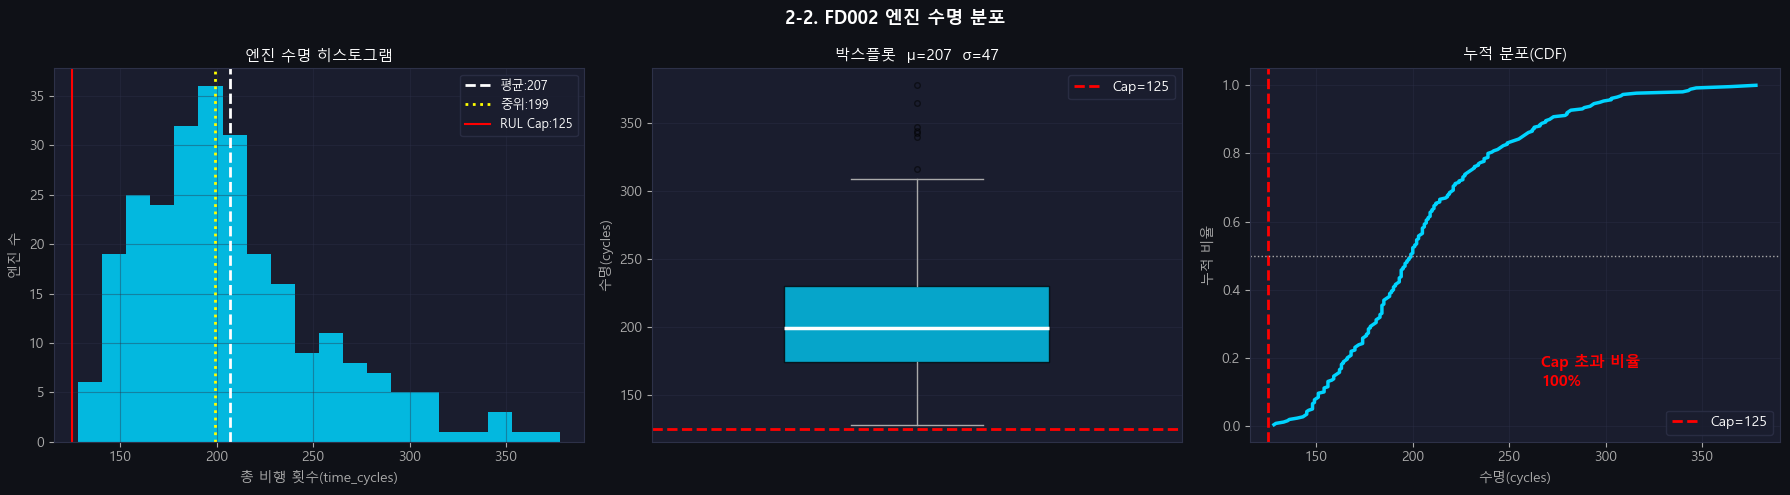


엔진 수명 통계:
  평균=206.8  중위=199.0  min=128  max=378
  Cap=125 초과 엔진: 260대 (100%)

📌 100% 엔진이 수명 125 사이클 초과 → Cap=125 설정 근거


In [5]:
lifecycles = train_raw.groupby('unit_nr')['time_cycles'].max()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('2-2. FD002 엔진 수명 분포', fontsize=13, fontweight='bold')

# 히스토그램
ax = axes[0]
ax.hist(lifecycles, bins=20, color=C[0], alpha=0.85, edgecolor='none')
ax.axvline(lifecycles.mean(),   color='white',  ls='--', lw=2, label=f'평균:{lifecycles.mean():.0f}')
ax.axvline(lifecycles.median(), color='yellow', ls=':',  lw=2, label=f'중위:{lifecycles.median():.0f}')
ax.axvline(RUL_CAP, color='red', ls='-', lw=1.5, label=f'RUL Cap:{RUL_CAP}')
ax.set_xlabel('총 비행 횟수(time_cycles)')
ax.set_ylabel('엔진 수')
ax.set_title('엔진 수명 히스토그램')
ax.legend(fontsize=9)

# 박스플롯
ax = axes[1]
bp = ax.boxplot(lifecycles, patch_artist=True, vert=True, widths=0.5,
                medianprops=dict(color='white',lw=2.5),
                whiskerprops=dict(color=GRAY), capprops=dict(color=GRAY),
                flierprops=dict(marker='o',color=GRAY,markersize=4,alpha=0.5))
bp['boxes'][0].set_facecolor(C[0]); bp['boxes'][0].set_alpha(0.75)
ax.axhline(RUL_CAP, color='red', ls='--', lw=2, label=f'Cap={RUL_CAP}')
ax.set_ylabel('수명(cycles)')
ax.set_title(f'박스플롯  μ={lifecycles.mean():.0f}  σ={lifecycles.std():.0f}')
ax.set_xticks([])
ax.legend()

# CDF
ax = axes[2]
lc_sorted = np.sort(lifecycles)
cdf = np.arange(1, len(lc_sorted)+1)/len(lc_sorted)
ax.plot(lc_sorted, cdf, color=C[0], lw=2.5)
ax.axvline(RUL_CAP, color='red', ls='--', lw=2, label=f'Cap={RUL_CAP}')
ax.axhline(0.5, color=GRAY, ls=':', lw=1)
pct_above = (lifecycles > RUL_CAP).mean()*100
ax.text(0.55, 0.15, f'Cap 초과 비율\n{pct_above:.0f}%', transform=ax.transAxes,
        fontsize=11, color='red', fontweight='bold')
ax.set_xlabel('수명(cycles)')
ax.set_ylabel('누적 비율')
ax.set_title('누적 분포(CDF)')
ax.legend()

plt.tight_layout(); plt.show()

print(f'\n엔진 수명 통계:')
print(f'  평균={lifecycles.mean():.1f}  중위={lifecycles.median():.1f}  min={lifecycles.min()}  max={lifecycles.max()}')
print(f'  Cap={RUL_CAP} 초과 엔진: {(lifecycles>RUL_CAP).sum()}대 ({pct_above:.0f}%)')
print(f'\n📌 100% 엔진이 수명 {RUL_CAP} 사이클 초과 → Cap={RUL_CAP} 설정 근거')

### 2-2. 엔진 수명 분포 설명

FD001과 동일한 방식으로 확인.  
평균 207사이클, 최소 128사이클로 **100% 엔진이 Cap=125 초과** → Cap=125 설정 근거 유지.

---

## 2-3. 센서 분포 & 이상치 (전처리 전)

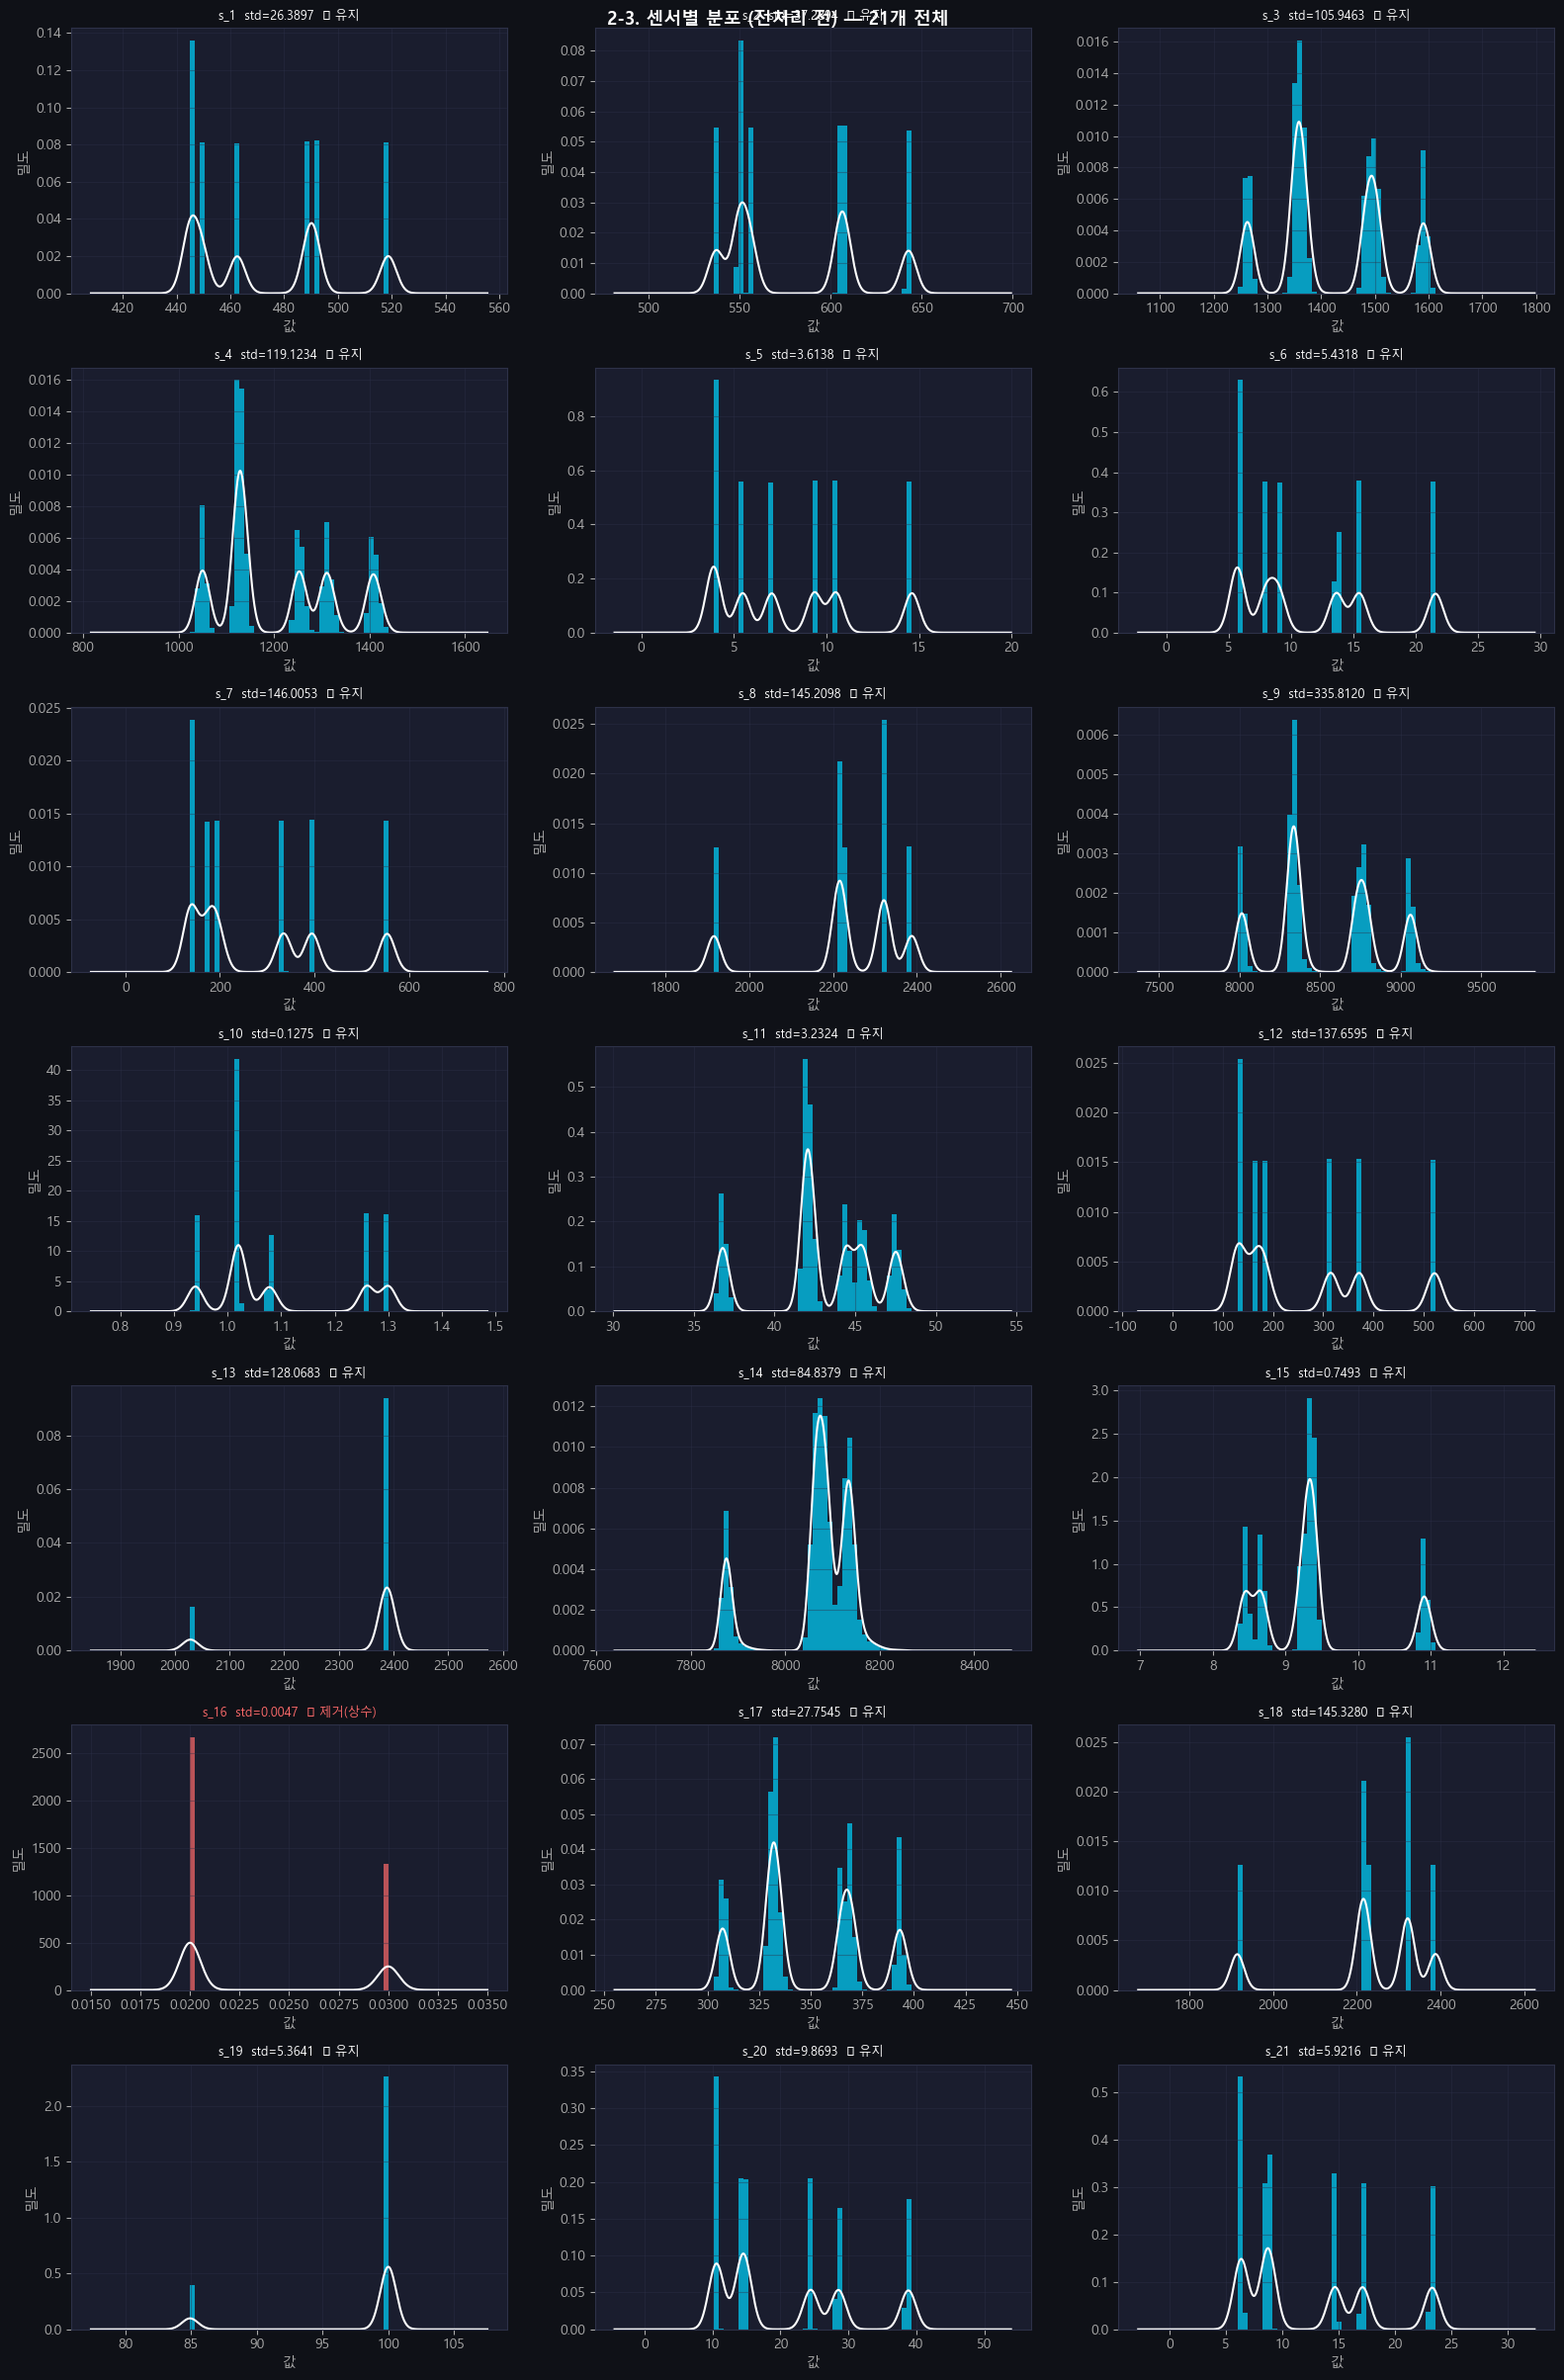

--- IQR 기준 이상치 탐지 ---


,센서,이상치 수,비율(%)
7,s_8,8002,14.885
10,s_11,3433,6.386
12,s_13,9640,17.932
13,s_14,8049,14.972
14,s_15,8002,14.885
17,s_18,8002,14.885
18,s_19,8002,14.885


In [6]:
# 21개 센서 분포 (히스토그램 + KDE)
n_cols, n_rows = 3, 7
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows*3.5))
fig.suptitle('2-3. 센서별 분포 (전처리 전) — 21개 전체', fontsize=13, fontweight='bold')

for ax, s in zip(axes.flat, SENSOR_COLS):
    data = train_raw[s].dropna()
    std_val = data.std()
    is_const = std_val < CONST_THR
    color = C[1] if is_const else C[0]
    ax.hist(data, bins=40, color=color, alpha=0.7, density=True, edgecolor='none')
    try:
        data.plot.kde(ax=ax, color='white', lw=1.5)
    except: pass
    label = '❌ 제거(상수)' if is_const else '✅ 유지'
    ax.set_title(f'{s}  std={std_val:.4f}  {label}', fontsize=9,
                 color=C[1] if is_const else WHITE)
    ax.set_xlabel('값'); ax.set_ylabel('밀도')

for ax in axes.flat[len(SENSOR_COLS):]:
    ax.set_visible(False)

plt.tight_layout(); plt.show()

# IQR 이상치 탐지
print('--- IQR 기준 이상치 탐지 ---')
outlier_rows = []
for s in SENSOR_COLS:
    Q1, Q3 = train_raw[s].quantile(0.25), train_raw[s].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((train_raw[s] < Q1-1.5*IQR)|(train_raw[s] > Q3+1.5*IQR)).sum()
    outlier_rows.append({'센서':s,'이상치 수':n_out,'비율(%)':round(n_out/len(train_raw)*100,3)})
out_df = pd.DataFrame(outlier_rows)
nonzero = out_df[out_df['이상치 수']>0]
if len(nonzero):
    display(nonzero)
else:
    print('✅ IQR 기준 이상치 없음 (시뮬레이션 데이터 특성)')

### 2-3. 센서 분포 & 이상치 결과 정리 

- 제거 센서: `s_16` (std=0.0047) → FD001과 동일하게 1개 제거
- 대부분 센서에서 **멀티모달 분포** 확인 → 운전 조건 6가지가 분포에 그대로 반영
- IQR 기준 이상치가 일부 센서에서 탐지됨 (`s_8`, `s_11`, `s_13` 등 최대 17.9%)
- 단, 이는 **진짜 이상치가 아님** → IQR이 단일 분포를 가정하기 때문에
  멀티모달 분포에서 다른 조건의 정상값을 이상치로 오탐지한 것
- → 제거 불필요, 클러스터별 정규화로 해결

---

## 2-4. 센서 간 상관관계 히트맵 (전처리 전)

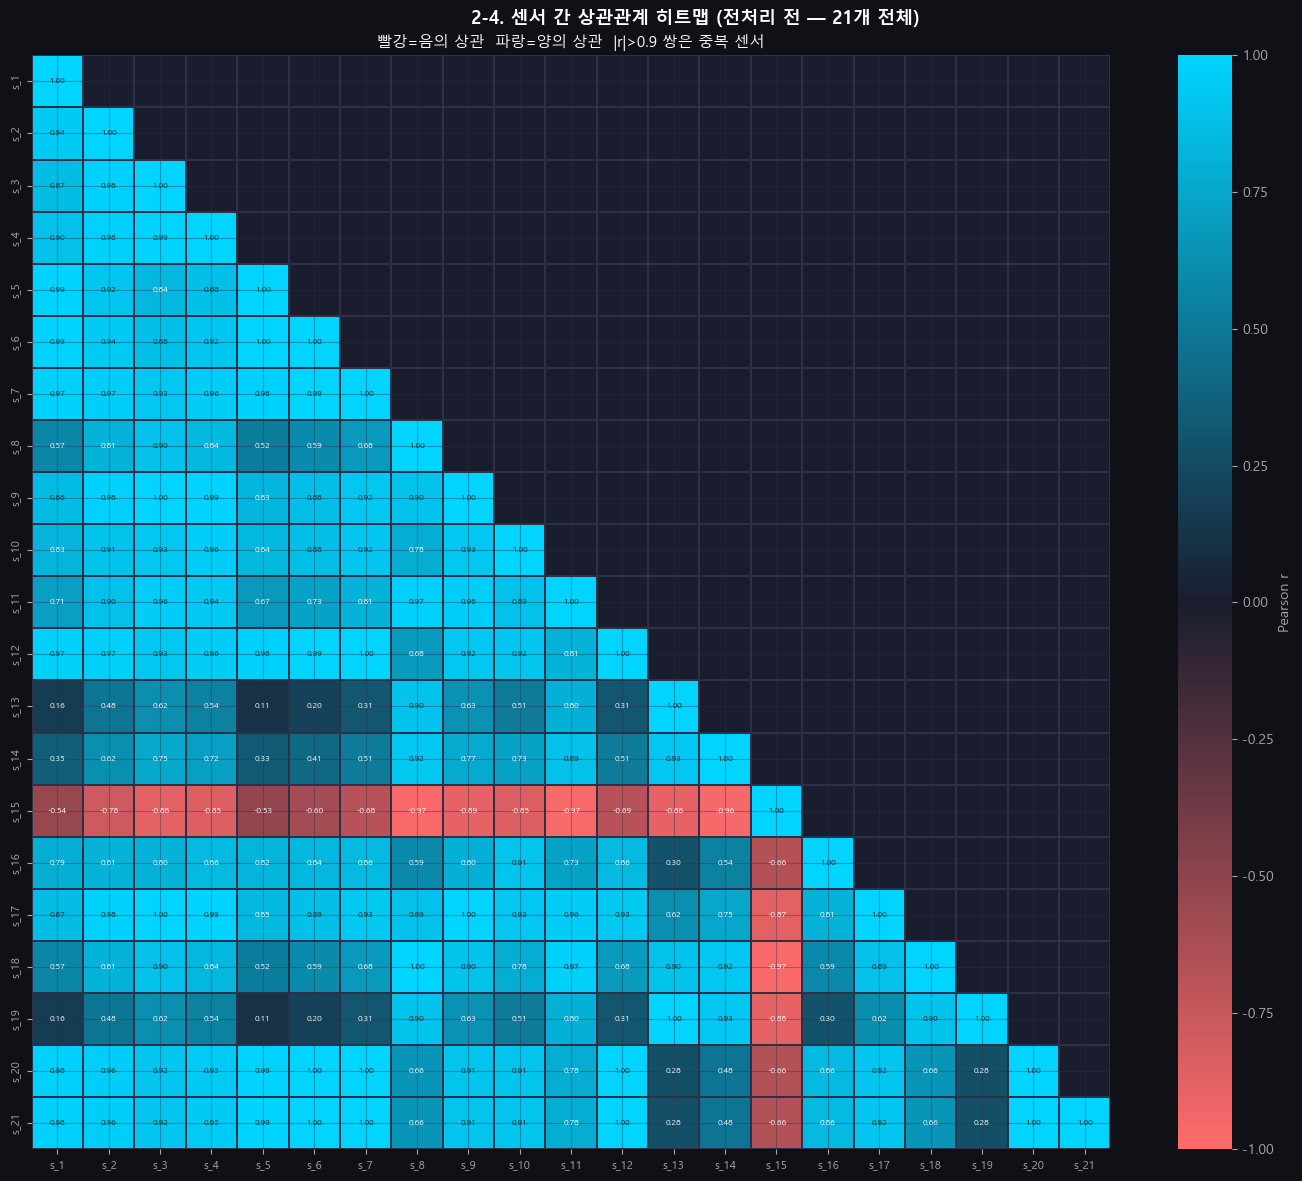

--- 고상관 센서 쌍 (|r| > 0.9) ---


,센서A,센서B,r
0,s_1,s_2,0.944
1,s_1,s_5,0.986
2,s_1,s_6,0.986
3,s_1,s_7,0.973
4,s_1,s_12,0.973
...,...,...,...
82,s_15,s_18,-0.971
83,s_17,s_20,0.919
84,s_17,s_21,0.919
85,s_18,s_19,0.903


In [7]:
from matplotlib.colors import LinearSegmentedColormap

cmap_rg = LinearSegmentedColormap.from_list('rg',['#ff6b6b','#1a1d2e','#00d4ff'],N=256)

corr_before = train_raw[SENSOR_COLS].corr()

fig, ax = plt.subplots(figsize=(14, 12))
fig.suptitle('2-4. 센서 간 상관관계 히트맵 (전처리 전 — 21개 전체)', fontsize=13, fontweight='bold')

mask = np.triu(np.ones_like(corr_before, dtype=bool), k=1)
sns.heatmap(corr_before, ax=ax, mask=mask, cmap=cmap_rg, center=0,
            vmin=-1, vmax=1, annot=True, fmt='.2f',
            annot_kws={'size':6}, linewidths=0.3, linecolor=GRID,
            cbar_kws={'label':'Pearson r'})
ax.set_title('빨강=음의 상관  파랑=양의 상관  |r|>0.9 쌍은 중복 센서')
ax.tick_params(labelsize=8)
plt.tight_layout(); plt.show()

# 고상관 쌍
print('--- 고상관 센서 쌍 (|r| > 0.9) ---')
pairs = []
for i in range(len(SENSOR_COLS)):
    for j in range(i+1, len(SENSOR_COLS)):
        r = corr_before.iloc[i,j]
        if abs(r) > 0.9:
            pairs.append({'센서A':SENSOR_COLS[i],'센서B':SENSOR_COLS[j],'r':round(r,3)})
if pairs:
    display(pd.DataFrame(pairs))
else:
    print('  해당 없음')

### 2-4. 센서 간 상관관계 히트맵 결과 정리

- 고상관 쌍 (|r| > 0.9): **87개** → FD001보다 훨씬 많음
- 원인: 운전 조건 변화 시 온도·압력·속도 센서가 동시에 움직이는 **조건 공변동** 때문
- 열화 신호가 아닌 조건 영향이므로 센서 추가 제거는 불필요
- → 클러스터별 정규화 후 조건 영향 제거 시 상관관계가 낮아질 것으로 예상

---

## 2-5. 센서별 열화 트렌드 (전처리 전)

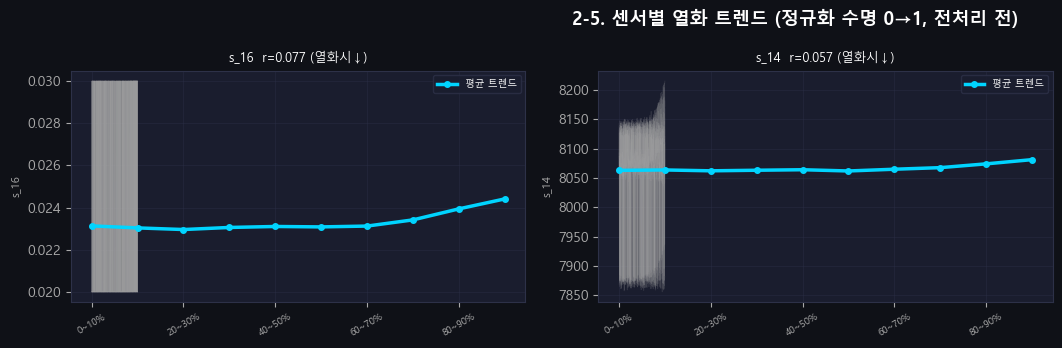

📌 r < 0: 엔진이 닳을수록 센서값 증가 (온도↑)  |  r > 0: 감소 (속도↓)


In [8]:
# 정규화 수명축(0=새것, 1=고장 직전)으로 평균 트렌드 확인
tr_trend = train_raw.copy()
mc = tr_trend.groupby('unit_nr')['time_cycles'].max().rename('max_c')
tr_trend = tr_trend.join(mc, on='unit_nr')
tr_trend['norm_life'] = tr_trend['time_cycles']/tr_trend['max_c']

bins   = np.linspace(0, 1, 11)
labels = [f'{int(a*100)}~{int(b*100)}%' for a,b in zip(bins[:-1],bins[1:])]
tr_trend['life_bin'] = pd.cut(tr_trend['norm_life'], bins=bins, labels=labels)
trend_mean = tr_trend.groupby('life_bin', observed=True)[SENSOR_COLS].mean()

# 유의미한 트렌드 센서만 표시 # 기준을 FD001과 다르게 0.1 → 0.05로 낮추기)
corr_with_life = tr_trend[SENSOR_COLS+['norm_life']].corr()['norm_life'][SENSOR_COLS]
trend_sensors  = corr_with_life[corr_with_life.abs()>0.05].sort_values(key=abs, ascending=False).index.tolist()
trend_sensors  = trend_sensors[:9]

if len(trend_sensors) == 0:
    print('📌 FD002는 조건 영향으로 유의미한 트렌드 센서 없음 → 클러스터별 정규화 후 재확인 예정')
else:
    n_cols = 3
    n_rows = (len(trend_sensors)+n_cols-1)//n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows*3.5))
    fig.suptitle('2-5. 센서별 열화 트렌드 (정규화 수명 0→1, 전처리 전)', fontsize=13, fontweight='bold')

    x_pos = range(len(labels))
    sample_units = tr_trend['unit_nr'].unique()[:15]

    for ax, s in zip(axes.flat, trend_sensors):
        for u in sample_units:
            sub = tr_trend[tr_trend['unit_nr']==u].sort_values('norm_life')
            ax.plot(sub['norm_life'], sub[s], color=GRAY, alpha=0.15, lw=0.6)
        ax.plot(x_pos, trend_mean[s].values, color=C[0], lw=2.5, marker='o', markersize=4, label='평균 트렌드')
        r = corr_with_life[s]
        direction = '열화시↑' if r<0 else '열화시↓'
        ax.set_title(f'{s}  r={r:.3f} ({direction})', fontsize=9)
        ax.set_xticks(x_pos[::2])
        ax.set_xticklabels(labels[::2], rotation=30, fontsize=7)
        ax.set_ylabel(s, fontsize=8)
        ax.legend(fontsize=7)

    for ax in axes.flat[len(trend_sensors):]:
        ax.set_visible(False)

    plt.tight_layout(); plt.show()
    print('📌 r < 0: 엔진이 닳을수록 센서값 증가 (온도↑)  |  r > 0: 감소 (속도↓)')

### 2-5. 센서별 열화 트렌드 결과 정리

- FD001과 달리 |r| > 0.05 기준을 만족하는 센서가 `s_14`, `s_16` 2개뿐
- 트렌드가 거의 flat → 운전 조건 6가지가 혼재되어 열화 신호가 조건 노이즈에 묻힘
- FD001처럼 뚜렷한 단조 트렌드가 보이지 않는 것이 FD002의 핵심 특징
- → 클러스터별 정규화 후 8-5에서 트렌드 재확인 예정

---

## 2-6. RUL 상관계수 (전처리 전)

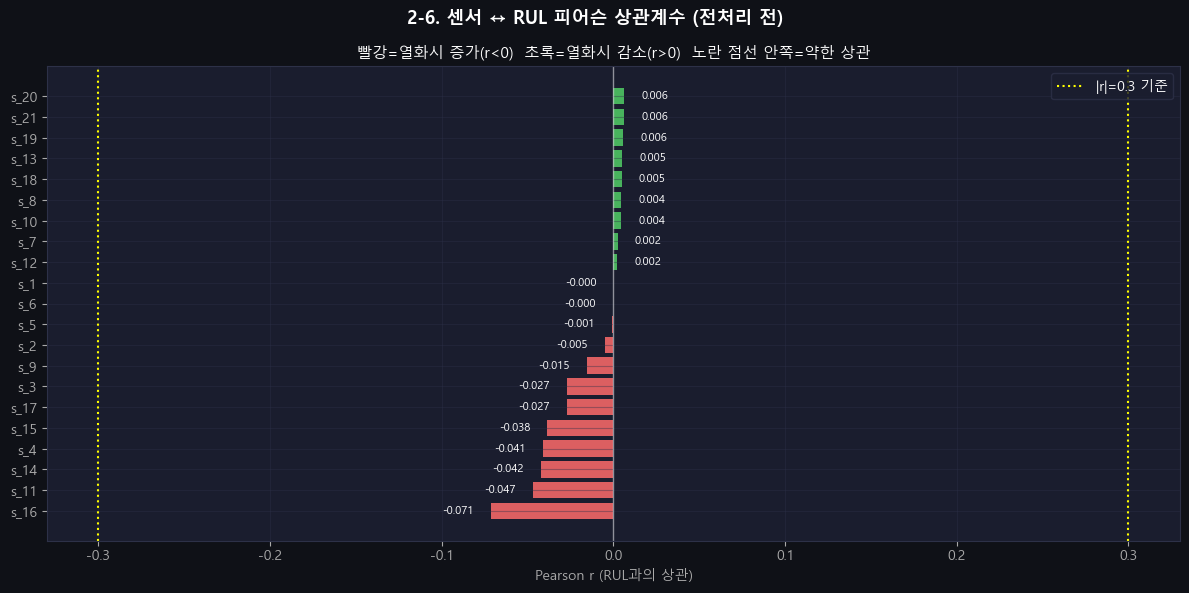

|r|>0.3 고상관 센서: 0개


In [9]:
tr_rul = train_raw.copy()
mc = tr_rul.groupby('unit_nr')['time_cycles'].max().rename('max_c')
tr_rul = tr_rul.join(mc, on='unit_nr')
tr_rul['RUL'] = tr_rul['max_c'] - tr_rul['time_cycles']

rul_corr_before = tr_rul[SENSOR_COLS+['RUL']].corr()['RUL'][SENSOR_COLS].sort_values()

fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle('2-6. 센서 ↔ RUL 피어슨 상관계수 (전처리 전)', fontsize=13, fontweight='bold')

bar_colors = [C[1] if v<0 else C[2] for v in rul_corr_before]
bars = ax.barh(rul_corr_before.index, rul_corr_before.values, color=bar_colors, alpha=0.85)
ax.axvline(0,    color='white', lw=1, alpha=0.5)
ax.axvline( 0.3, color='yellow', lw=1.5, ls=':', label='|r|=0.3 기준')
ax.axvline(-0.3, color='yellow', lw=1.5, ls=':')
ax.set_xlabel('Pearson r (RUL과의 상관)')
ax.set_title('빨강=열화시 증가(r<0)  초록=열화시 감소(r>0)  노란 점선 안쪽=약한 상관')
ax.legend()
for bar, val in zip(bars, rul_corr_before.values):
    ax.text(val+(0.01 if val>=0 else -0.01), bar.get_y()+bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left' if val>=0 else 'right', fontsize=8)
plt.tight_layout(); plt.show()

high_corr = rul_corr_before[rul_corr_before.abs()>0.3]
print(f'|r|>0.3 고상관 센서: {len(high_corr)}개')
for s,r in high_corr.sort_values(key=abs,ascending=False).items():
    print(f'  {s}: r={r:.3f}  {SENSOR_DESC.get(s,"")[:30]}')

### 2-6. RUL 상관계수 결과 정리

- |r| > 0.3 고상관 센서: **0개** → FD001과 완전히 다른 결과
- 모든 센서의 |r| < 0.1로 RUL과 거의 무상관
- 원인: 운전 조건 6가지 노이즈가 열화 신호를 덮어버린 것
- → 클러스터별 정규화 후 조건 영향 제거 시 상관계수가 높아질 것으로 예상

---

## 2-7. 운전 조건 분포 & 군집화

FD002는 운전 조건이 6가지로 구성되어 있으며, 각 조건은 고도(setting_1), 마하수(setting_2),
스로틀 각도(TRA, setting_3) 조합으로 정의됨.

**분석 목적**
- setting 3개 컬럼의 실제 분포를 시각화하여 군집 구조 확인
- 엘보우 차트로 k=6이 적절한지 근거 확인
- K-means(k=6) 결과 시각화로 클러스터가 명확히 분리되는지 검증

**왜 중요한가**
- 2-3에서 확인한 멀티모달 분포의 원인이 운전 조건임을 증명
- 이후 전처리 단계에서 클러스터별 정규화를 적용하는 근거가 됨
- setting 컬럼은 클러스터링 도구로만 사용하고 모델 입력에서는 제외

**엘보우 차트란?**
K-means는 클러스터 내 데이터들이 중심점에서 얼마나 퍼져있는지를 Inertia로 측정함.
k를 늘릴수록 Inertia는 계속 줄어들지만, 어느 순간부터 줄어드는 폭이 급격히 작아지는
꺾이는 지점이 생김. 이 지점이 팔꿈치(elbow)처럼 생겼다고 해서 엘보우 차트라고 부르며,
해당 지점의 k가 최적값. FD002는 실제 조건이 6개이므로 k=6에서 꺾임이 나타날 것으로 예상.

```
Inertia
  |
  |  *
  |    *
  |      *
  |        *  ← 여기서 꺾임 = 최적 k
  |           * * * *
  └─────────────────── k
             3 4 5 6 7
```

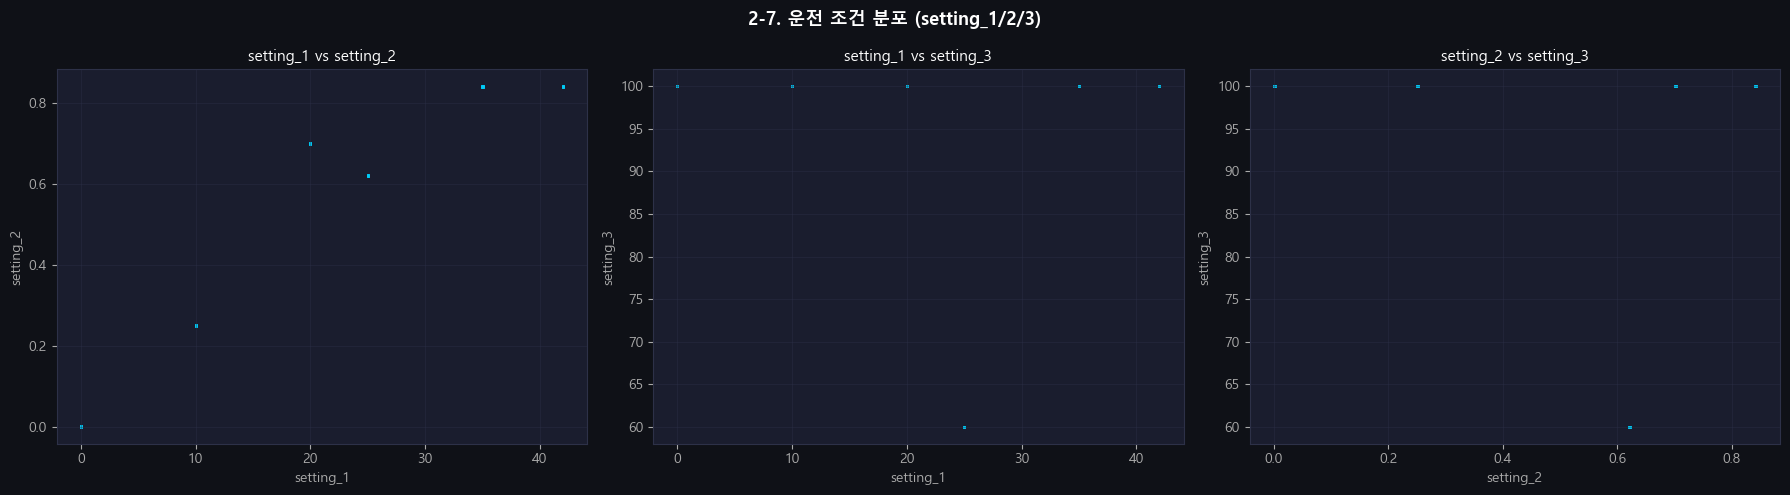

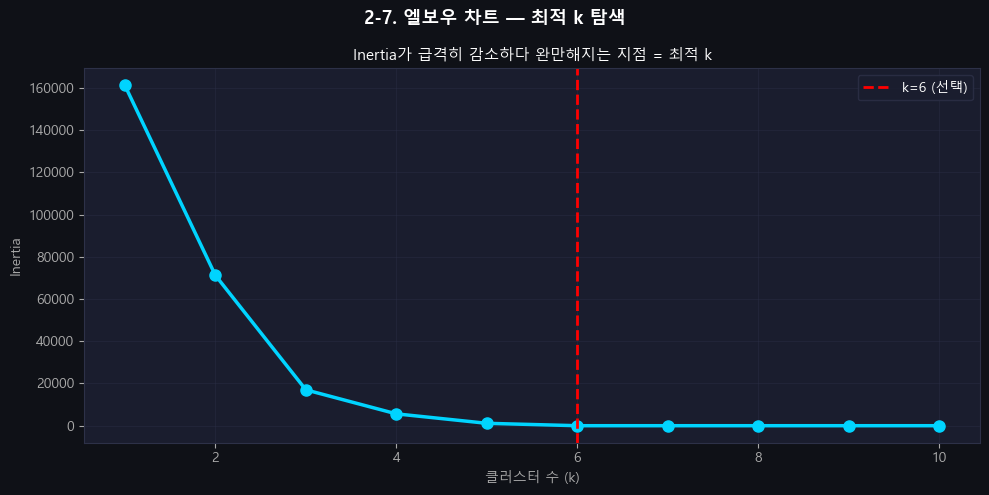

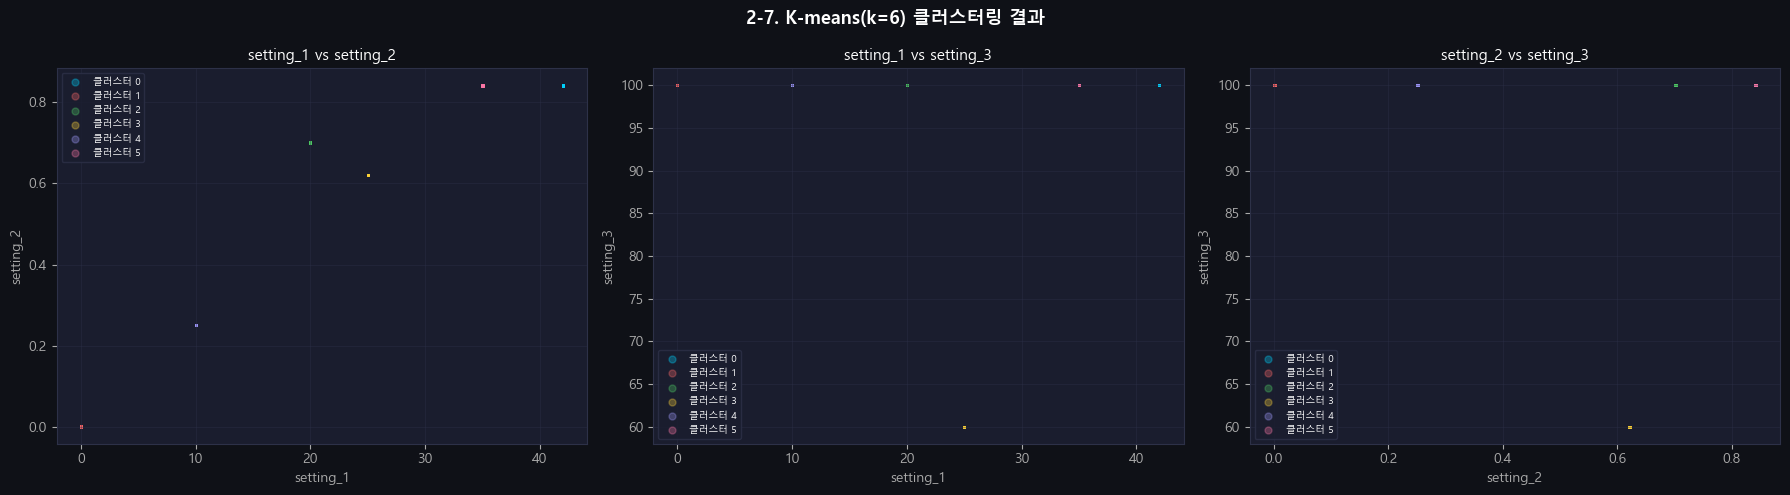

--- 클러스터별 샘플 수 ---
  클러스터 0: 13458개 (25.0%)
  클러스터 1: 8044개 (15.0%)
  클러스터 2: 8122개 (15.1%)
  클러스터 3: 8002개 (14.9%)
  클러스터 4: 8096개 (15.1%)
  클러스터 5: 8037개 (15.0%)


In [10]:
# 2-7. 운전 조건 분포 & 군집화
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# ① setting 산점도
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('2-7. 운전 조건 분포 (setting_1/2/3)', fontsize=13, fontweight='bold')

pairs = [('setting_1','setting_2'), ('setting_1','setting_3'), ('setting_2','setting_3')]
for ax, (x, y) in zip(axes, pairs):
    ax.scatter(train_raw[x], train_raw[y], color=C[0], alpha=0.1, s=1)
    ax.set_xlabel(x); ax.set_ylabel(y)
    ax.set_title(f'{x} vs {y}')

plt.tight_layout(); plt.show()

# ② 엘보우 차트
op_data = train_raw[OP_COLS].values
scaler_op = StandardScaler()
op_scaled = scaler_op.fit_transform(op_data)

inertias = []
K_range = range(1, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(op_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('2-7. 엘보우 차트 — 최적 k 탐색', fontsize=13, fontweight='bold')
ax.plot(K_range, inertias, color=C[0], lw=2.5, marker='o', markersize=8)
ax.axvline(6, color='red', ls='--', lw=2, label='k=6 (선택)')
ax.set_xlabel('클러스터 수 (k)'); ax.set_ylabel('Inertia')
ax.set_title('Inertia가 급격히 감소하다 완만해지는 지점 = 최적 k')
ax.legend()
plt.tight_layout(); plt.show()

# ③ k=6 클러스터링 결과 시각화
km_eda = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
cluster_labels_eda = km_eda.fit_predict(op_scaled)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('2-7. K-means(k=6) 클러스터링 결과', fontsize=13, fontweight='bold')

for ax, (x, y) in zip(axes, pairs):
    for c in range(N_CLUSTERS):
        mask = cluster_labels_eda == c
        ax.scatter(train_raw[x][mask], train_raw[y][mask],
                   color=C[c], alpha=0.3, s=1, label=f'클러스터 {c}')
    ax.set_xlabel(x); ax.set_ylabel(y)
    ax.set_title(f'{x} vs {y}')
    ax.legend(fontsize=7, markerscale=5)

plt.tight_layout(); plt.show()

# 클러스터별 샘플 수
cluster_counts = pd.Series(cluster_labels_eda).value_counts().sort_index()
print('--- 클러스터별 샘플 수 ---')
for c, cnt in cluster_counts.items():
    print(f'  클러스터 {c}: {cnt}개 ({cnt/len(cluster_labels_eda)*100:.1f}%)')

### 2-7. 결과 해석

#### ① 운전 조건 분포 산점도
- setting_1(고도) vs setting_2(마하수) 산점도에서 **6개의 점**이 명확히 분리됨
- 각 점이 하나의 운전 조건을 나타냄
- 점이 아닌 덩어리가 아니라 **이산적(discrete)** 으로 분포
  → FD002의 운전 조건은 연속적이 아니라 6가지 고정값 조합임을 의미

#### ② 엘보우 차트
- k=1~5 구간: Inertia가 급격히 감소
- k=6 이후: Inertia가 거의 0에 수렴하며 완만해짐
- **k=6에서 명확한 꺾임** → k=6이 최적임을 수치로 확인
- 이는 FD002 데이터셋 설명(6가지 운전 조건)과 정확히 일치

#### ③ K-means(k=6) 클러스터링 결과
- 6개 클러스터가 **완벽하게 분리**됨 (겹치는 구간 없음)
- 각 클러스터가 하나의 운전 조건(고도+마하수+스로틀 조합)에 정확히 대응

#### ④ 클러스터별 샘플 수
- 클러스터 0: 25.0% (다른 클러스터보다 약 2배 많음)
- 클러스터 1~5: 약 15%씩 균등 분포
- 클러스터 0이 많은 이유: 해당 조건(저고도/저속)이 이착륙 구간으로
  비행 중 가장 많이 발생하는 조건으로 추정

#### ✅ 결론
- 운전 조건 6개가 데이터에 명확히 존재함을 시각적·수치적으로 확인
- k=6 사용 근거 확보
- 2-3에서 관찰한 멀티모달 분포의 원인이 이 6개 조건임이 증명됨
- → 전처리 단계에서 클러스터별 정규화 적용 확정

---

## 2-8. 클러스터별 센서 분포

**분석 목적**
- 클러스터(운전 조건)별로 센서값 범위가 얼마나 다른지 확인
- 2-3에서 관찰한 멀티모달 분포가 실제로 클러스터별로 분리되는지 검증
- 클러스터별 정규화가 필요한 이유를 시각적으로 증명

**해석 방법**
- 박스플롯으로 클러스터별 센서값 분포를 비교
- 클러스터 간 분포가 많이 다를수록 → 조건 영향이 큰 센서
- 클러스터 간 분포가 비슷할수록 → 조건 영향이 적은 센서
- 조건 영향이 큰 센서일수록 클러스터별 정규화 효과가 크게 나타남

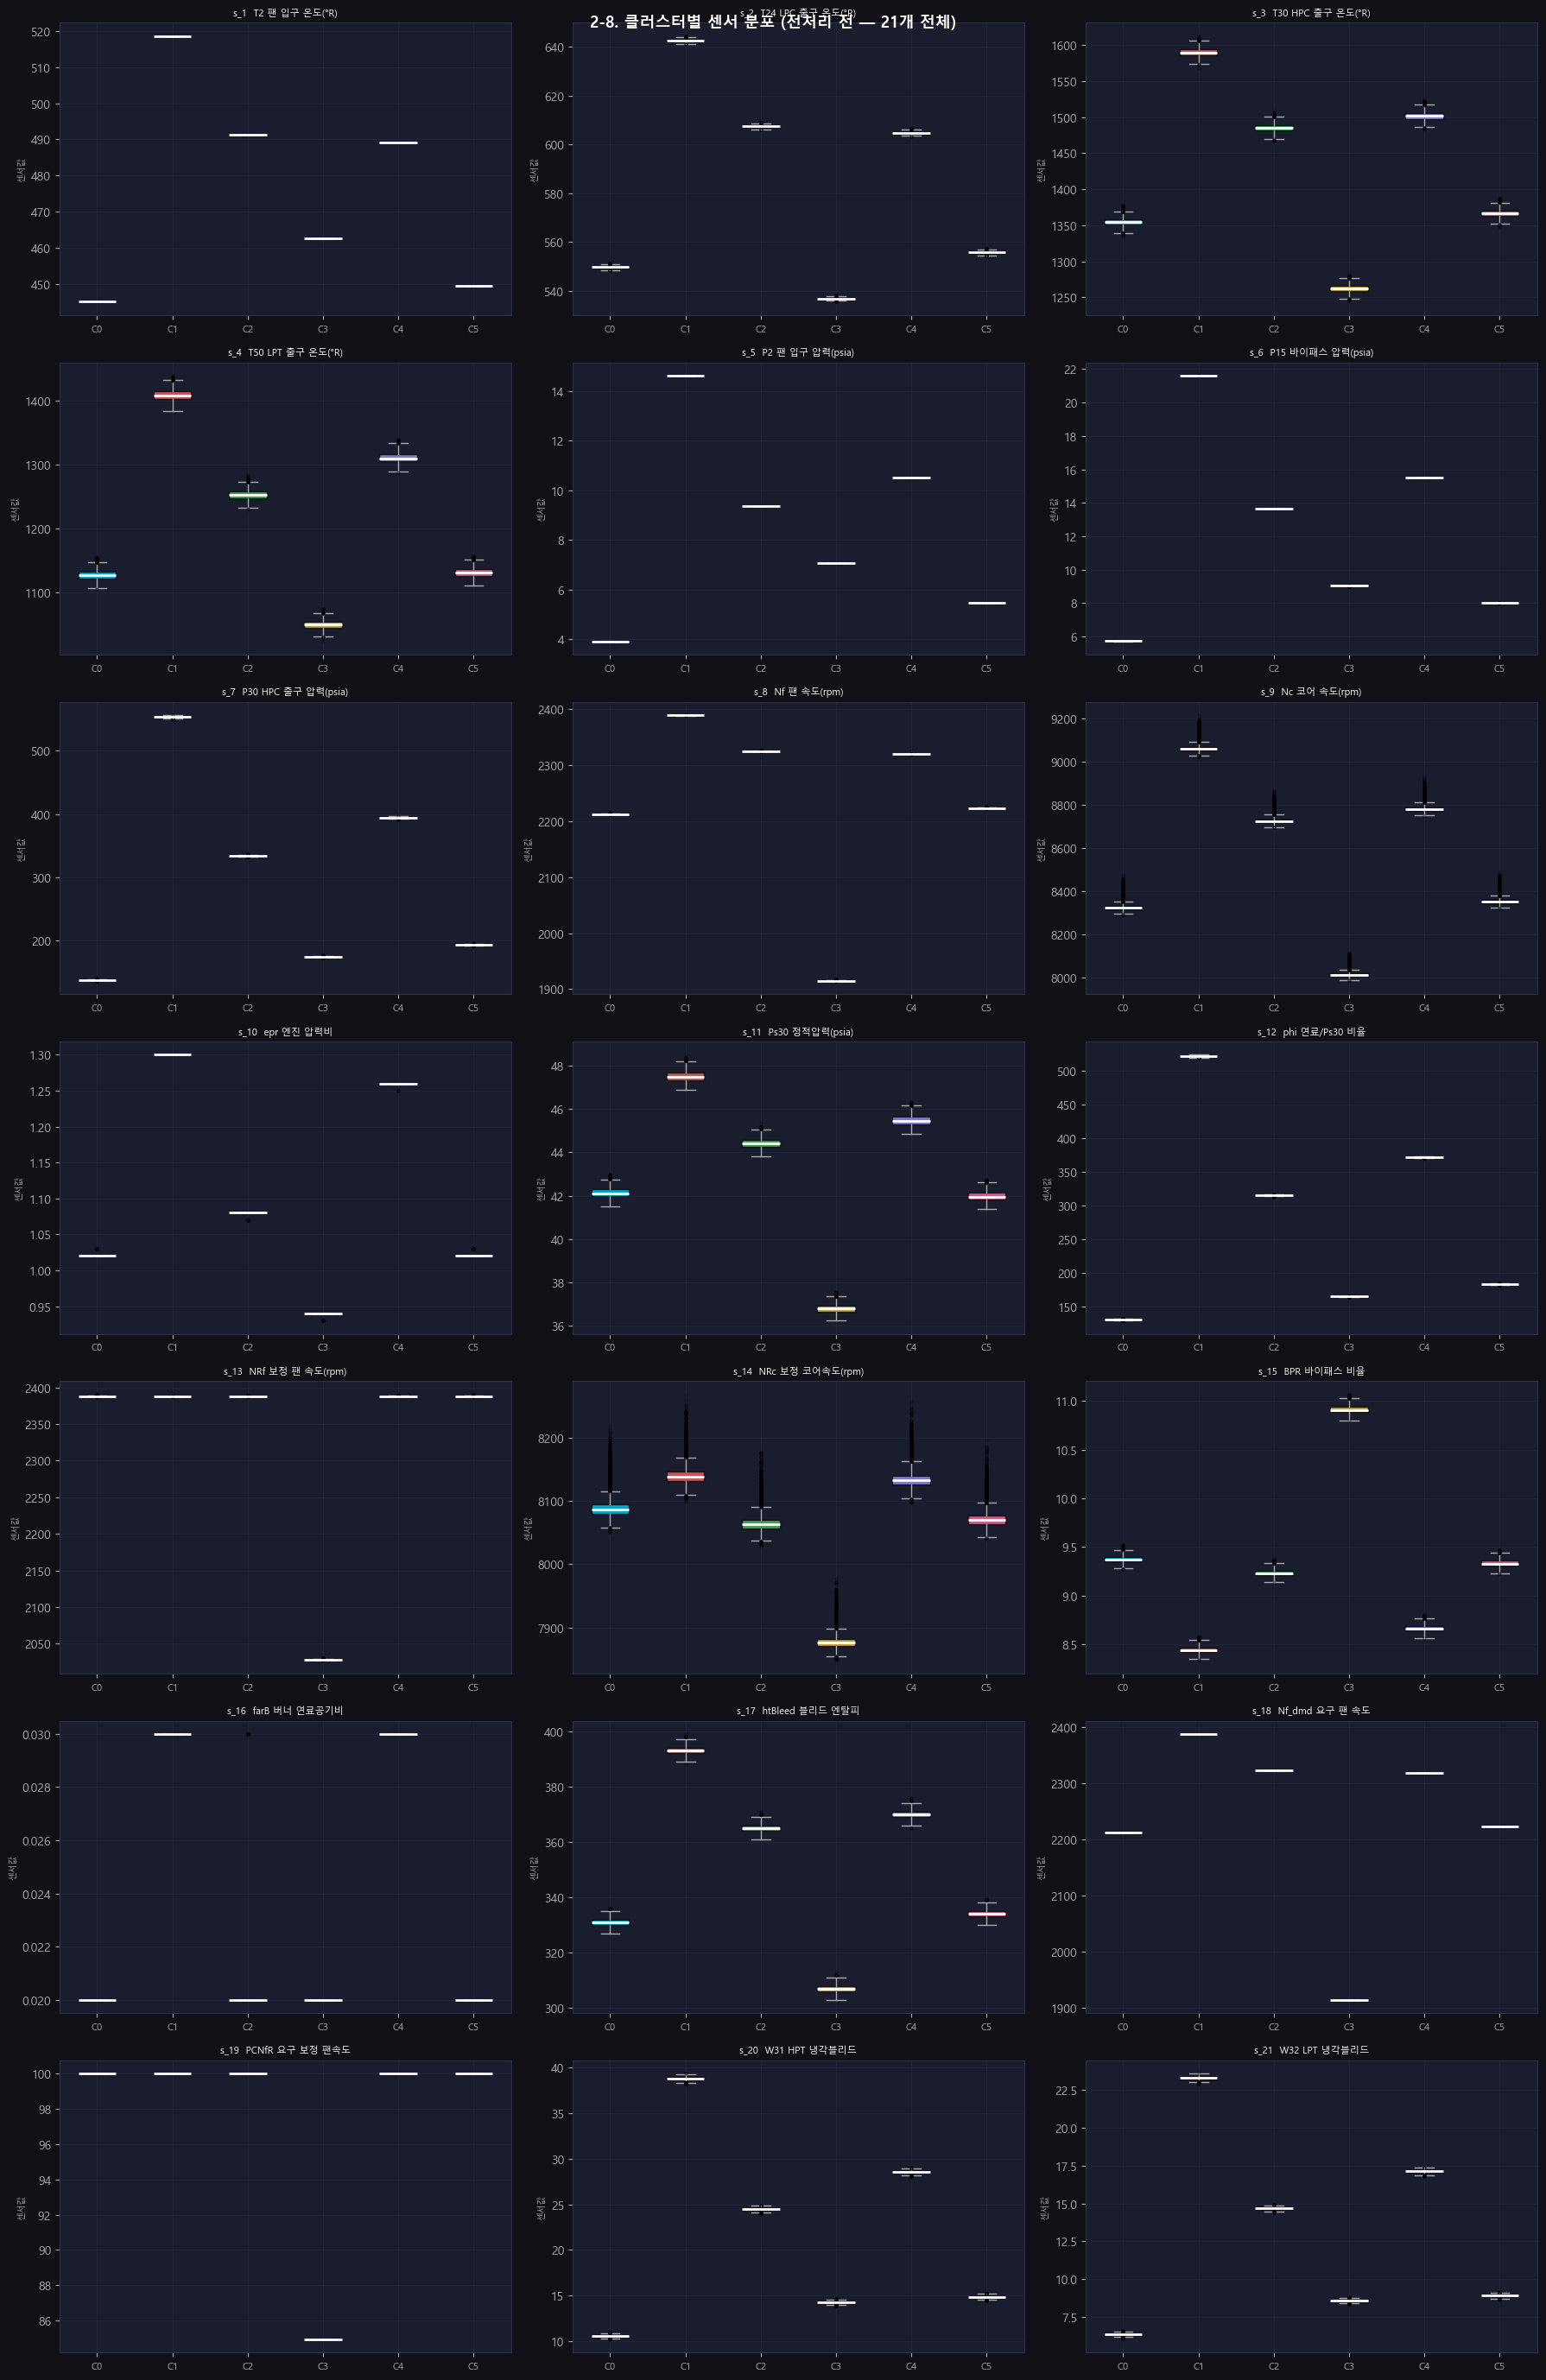

--- 클러스터 간 분포 차이 (클러스터별 평균의 std) ---
조건 영향 큰 순서 (상위 10개):


,센서,클러스터 간 평균 std,설명
0,s_9,347.1988,Nc 코어 속도(rpm)
1,s_18,153.4703,Nf_dmd 요구 팬 속도
2,s_8,153.3437,Nf 팬 속도(rpm)
3,s_7,145.4679,P30 HPC 출구 압력(psia)
4,s_12,137.1814,phi 연료/Ps30 비율
5,s_13,134.0922,NRf 보정 팬 속도(rpm)
6,s_4,122.4616,T50 LPT 출구 온도(°R)
7,s_3,109.2866,T30 HPC 출구 온도(°R)
8,s_14,87.7808,NRc 보정 코어속도(rpm)
9,s_2,37.9078,T24 LPC 출구 온도(°R)


In [11]:
# 2-8. 클러스터별 센서 분포
# EDA용 클러스터 레이블 붙이기 (전처리 전 원본 데이터 기준)
train_eda = train_raw.copy()
train_eda['cluster'] = cluster_labels_eda

# 21개 센서 전체 클러스터별 박스플롯
n_cols, n_rows = 3, 7
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows*4))
fig.suptitle('2-8. 클러스터별 센서 분포 (전처리 전 — 21개 전체)', fontsize=13, fontweight='bold')

for ax, s in zip(axes.flat, SENSOR_COLS):
    data_by_cluster = [train_eda[train_eda['cluster']==c][s].values for c in range(N_CLUSTERS)]
    bp = ax.boxplot(data_by_cluster, patch_artist=True,
                    medianprops=dict(color='white', lw=2),
                    whiskerprops=dict(color=GRAY),
                    capprops=dict(color=GRAY),
                    flierprops=dict(marker='o', color=GRAY, markersize=2, alpha=0.3))
    for patch, color in zip(bp['boxes'], C[:N_CLUSTERS]):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
    ax.set_title(f'{s}  {SENSOR_DESC.get(s,"")[:20]}', fontsize=8)
    ax.set_xticklabels([f'C{c}' for c in range(N_CLUSTERS)], fontsize=8)
    ax.set_ylabel('센서값', fontsize=7)

for ax in axes.flat[len(SENSOR_COLS):]:
    ax.set_visible(False)

plt.tight_layout(); plt.show()

# 클러스터 간 분포 차이가 큰 센서 정량화
print('--- 클러스터 간 분포 차이 (클러스터별 평균의 std) ---')
diff_rows = []
for s in SENSOR_COLS:
    cluster_means = [train_eda[train_eda['cluster']==c][s].mean() for c in range(N_CLUSTERS)]
    spread = np.std(cluster_means)
    diff_rows.append({'센서': s, '클러스터 간 평균 std': round(spread, 4),
                      '설명': SENSOR_DESC.get(s, '')[:25]})
diff_df = pd.DataFrame(diff_rows).sort_values('클러스터 간 평균 std', ascending=False).reset_index(drop=True)
print('조건 영향 큰 순서 (상위 10개):')
display(diff_df.head(10))

### 2-8. 결과 해석

#### ① 클러스터별 센서 분포 박스플롯
- 대부분의 센서에서 클러스터별 분포가 **완전히 다른 범위**에 위치
- 특히 `s_7`, `s_9`, `s_12` 등은 클러스터 간 겹치는 구간이 거의 없음
- 2-3에서 관찰한 멀티모달 분포의 봉우리 = 각 클러스터의 분포임이 확인됨
- `s_16`은 클러스터 간 차이가 거의 없음 → 상수 센서 제거 대상 재확인

#### ② 클러스터 간 분포 차이 (조건 영향 큰 순서)
| 순위 | 센서 | 설명 | 의미 |
|---|---|---|---|
| 1 | s_9 | Nc 코어 속도 | 고도/속도에 따라 코어 속도가 크게 달라짐 |
| 2 | s_18 | Nf_dmd 요구 팬 속도 | 조건별 요구 출력이 다름 |
| 3 | s_8 | Nf 팬 속도 | 고도/마하수에 따라 팬 속도 차이 큼 |
| 4 | s_7 | P30 HPC 출구 압력 | 고도에 따라 압력 범위가 완전히 다름 |

#### ✅ 결론
- 모든 센서에서 클러스터(운전 조건)별 분포가 명확히 다름
- 전체 데이터를 하나의 scaler로 정규화하면 조건 영향이 그대로 남음
- **클러스터별 정규화 필요성이 시각적으로 완벽하게 증명됨**
- 정규화 후 8-1에서 클러스터 간 분포가 맞춰지는지 재확인 예정

In [12]:
print(train_raw.columns.tolist())

['unit_nr', 'time_cycles', 'setting_1', 'setting_2', 'setting_3', 's_1', 's_2', 's_3', 's_4', 's_5', 's_6', 's_7', 's_8', 's_9', 's_10', 's_11', 's_12', 's_13', 's_14', 's_15', 's_16', 's_17', 's_18', 's_19', 's_20', 's_21']


---

## 2-9. 클러스터 특성 심화 분석

FD001과 달리 FD002는 운전 조건이 6가지로 구성되어 있어
단순 센서 분포 확인을 넘어 클러스터별 특성을 더 깊이 파악해야 함.

2-8에서 클러스터별 센서값 범위가 다르다는 것을 시각적으로 확인했다면,
2-9에서는 아래 세 가지를 추가로 확인함.

**2-9-1. 3D scatter (op_settings)**
- setting_1/2/3 세 축으로 3D 공간에서 클러스터가 얼마나 명확히 분리되는지 확인
- 2-7의 2D scatter보다 입체적으로 군집 구조 파악 가능

**2-9-2. 엔진별 regime 전이 heatmap**
- 한 엔진이 비행 중 6개 조건을 어떻게 오가는지 시각화
- FD002 고유의 특성: 단일 엔진이 여러 조건을 반복적으로 경험함
- x축: time_cycles / y축: 엔진 번호 / 색: 클러스터 번호
- 조건 전환이 불규칙하다면 → window 내에 여러 조건이 섞일 수 있음
  → window size 결정에도 영향을 줌

**2-9-3. regime별 수명 분포**
- 클러스터별로 엔진이 경험하는 사이클 수 분포 비교
- 특정 조건에서 많이 운행한 엔진이 수명이 짧은지 확인
- 이후 2-10 Kruskal-Wallis 검정의 시각적 근거 역할

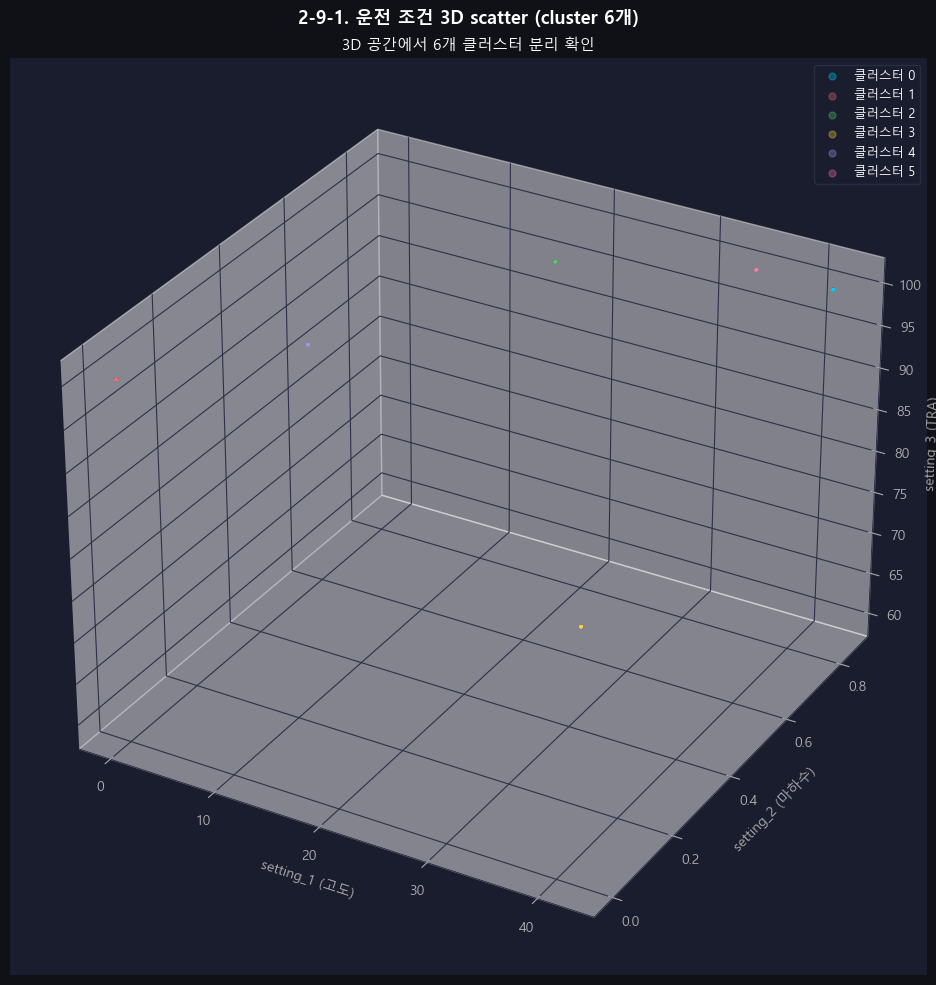

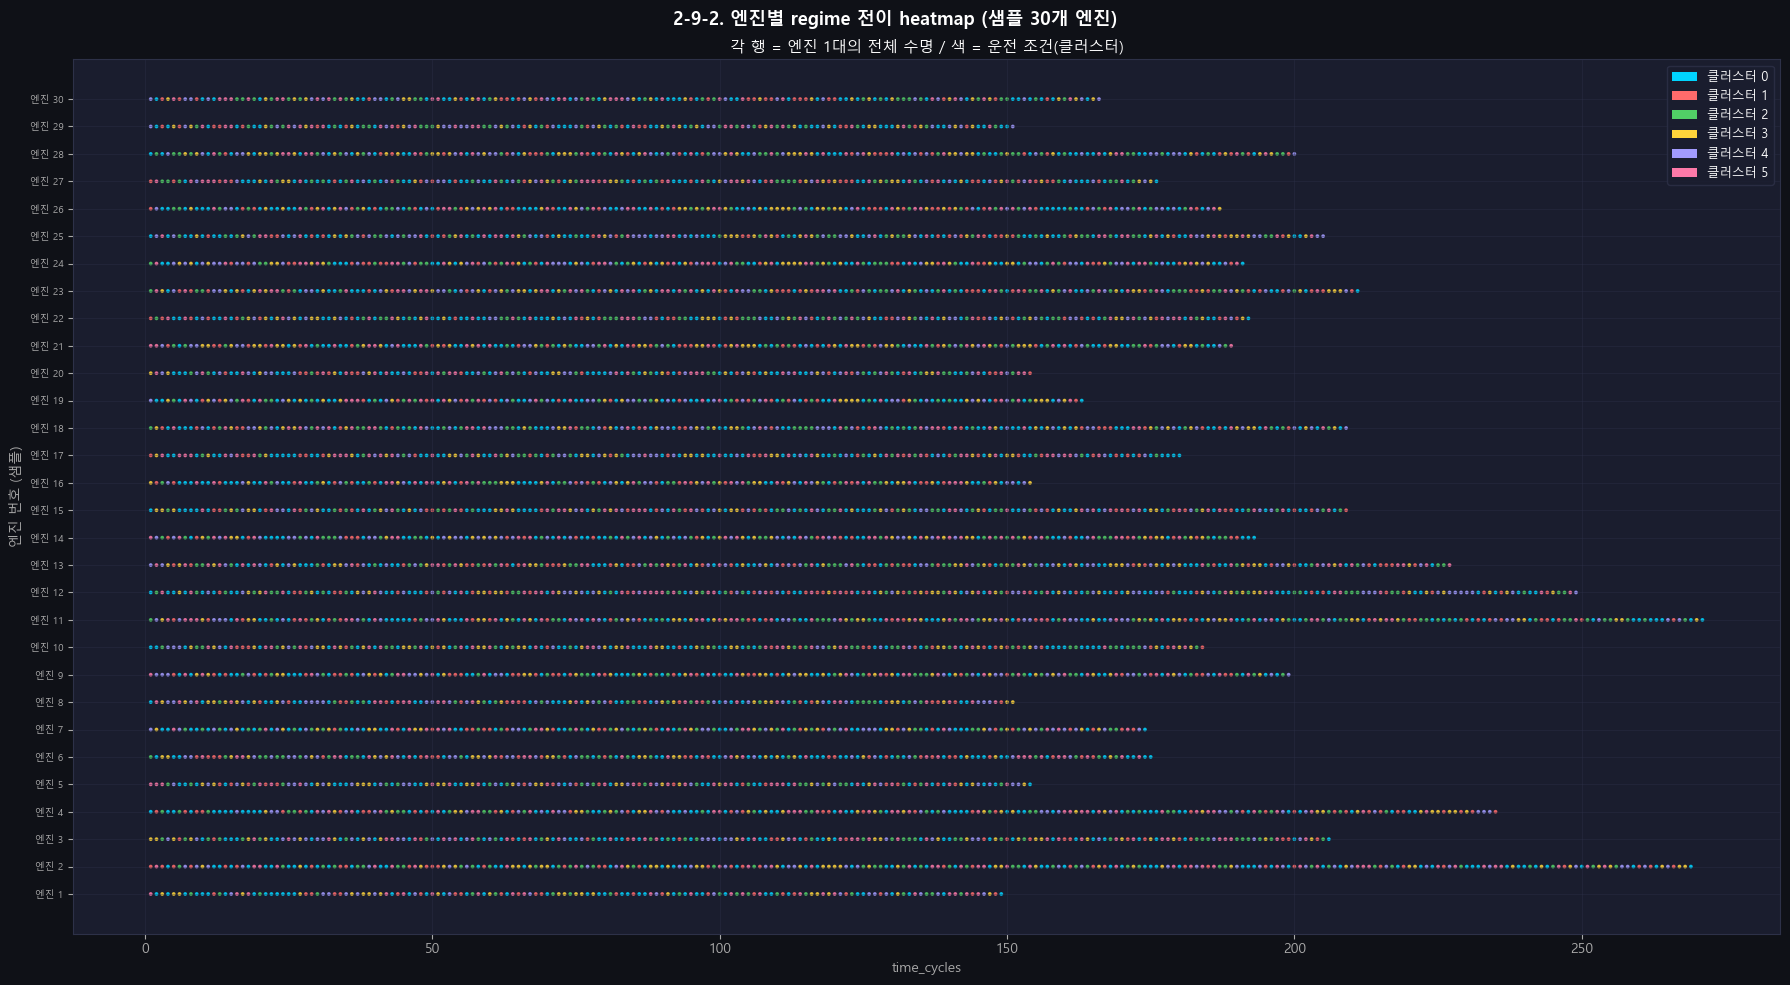

📌 한 엔진이 여러 조건을 반복적으로 경험함을 확인
   → window 내에 여러 조건이 섞일 수 있음 → window size 결정에 영향


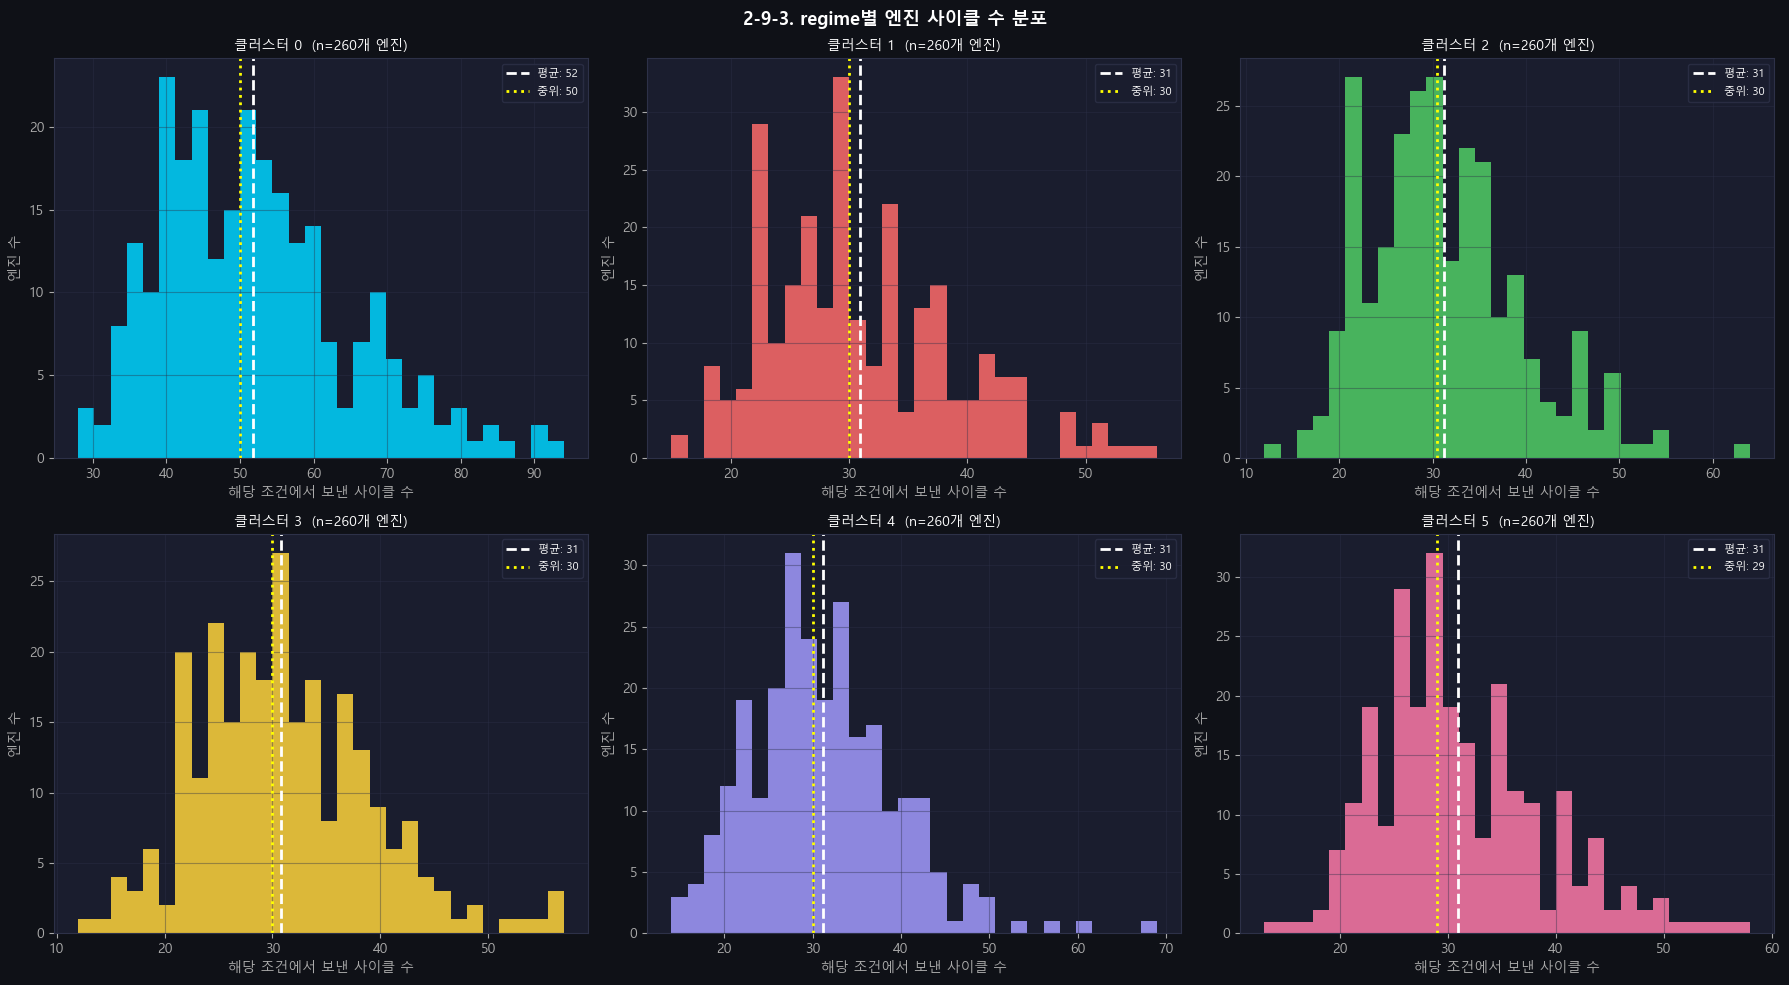

--- 클러스터별 평균 사이클 수 ---


,평균,중위,최소,최대
cluster,,,,
0,51.8,50.0,28,94
1,30.9,30.0,15,56
2,31.2,30.5,12,64
3,30.8,30.0,12,57
4,31.1,30.0,14,69
5,30.9,29.0,13,58


📌 특정 조건에서 사이클이 많다 = 해당 조건에서 많이 운행 = 열화에 더 많이 노출


In [13]:
# 2-9. 클러스터 특성 심화 분석
# EDA용 클러스터 레이블 사용 (cluster_labels_eda)
train_eda = train_raw.copy()
train_eda['cluster'] = cluster_labels_eda

# ── 2-9-1. 3D scatter ─────────────────────────────────────
fig = plt.figure(figsize=(14, 10))
fig.suptitle('2-9-1. 운전 조건 3D scatter (cluster 6개)', fontsize=13, fontweight='bold')

ax = fig.add_subplot(111, projection='3d')
for c in range(N_CLUSTERS):
    mask = cluster_labels_eda == c
    ax.scatter(
        train_raw[OP_COLS[0]][mask],
        train_raw[OP_COLS[1]][mask],
        train_raw[OP_COLS[2]][mask],
        color=C[c], alpha=0.3, s=1, label=f'클러스터 {c}'
    )
ax.set_xlabel('setting_1 (고도)')
ax.set_ylabel('setting_2 (마하수)')
ax.set_zlabel('setting_3 (TRA)')
ax.set_title('3D 공간에서 6개 클러스터 분리 확인')
ax.legend(fontsize=9, markerscale=5)
plt.tight_layout(); plt.show()

# ── 2-9-2. 엔진별 regime 전이 heatmap ────────────────────
sample_units = train_eda['unit_nr'].unique()[:30]  # 30개 엔진 샘플

fig, ax = plt.subplots(figsize=(18, 10))
fig.suptitle('2-9-2. 엔진별 regime 전이 heatmap (샘플 30개 엔진)', fontsize=13, fontweight='bold')

from matplotlib.colors import ListedColormap
cmap_cluster = ListedColormap(C[:N_CLUSTERS])

for i, uid in enumerate(sample_units):
    sub = train_eda[train_eda['unit_nr'] == uid].sort_values('time_cycles')
    ax.scatter(sub['time_cycles'], [i] * len(sub),
               c=sub['cluster'], cmap=cmap_cluster,
               vmin=0, vmax=N_CLUSTERS-1,
               s=3, alpha=0.8)

ax.set_xlabel('time_cycles')
ax.set_ylabel('엔진 번호 (샘플)')
ax.set_yticks(range(len(sample_units)))
ax.set_yticklabels([f'엔진 {u}' for u in sample_units], fontsize=7)
ax.set_title('각 행 = 엔진 1대의 전체 수명 / 색 = 운전 조건(클러스터)')

# 범례
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=C[c], label=f'클러스터 {c}') for c in range(N_CLUSTERS)]
ax.legend(handles=legend_elements, loc='upper right', fontsize=9)
plt.tight_layout(); plt.show()

print('📌 한 엔진이 여러 조건을 반복적으로 경험함을 확인')
print('   → window 내에 여러 조건이 섞일 수 있음 → window size 결정에 영향')

# ── 2-9-3. regime별 수명 분포 ────────────────────────────
# 엔진별 각 클러스터에서 보낸 사이클 수 계산
cluster_cycle_counts = train_eda.groupby(['unit_nr', 'cluster']).size().reset_index(name='cycle_count')

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('2-9-3. regime별 엔진 사이클 수 분포', fontsize=13, fontweight='bold')

for c, ax in zip(range(N_CLUSTERS), axes.flat):
    data = cluster_cycle_counts[cluster_cycle_counts['cluster'] == c]['cycle_count']
    ax.hist(data, bins=30, color=C[c], alpha=0.85, edgecolor='none')
    ax.axvline(data.mean(), color='white', ls='--', lw=2, label=f'평균: {data.mean():.0f}')
    ax.axvline(data.median(), color='yellow', ls=':', lw=2, label=f'중위: {data.median():.0f}')
    ax.set_title(f'클러스터 {c}  (n={len(data)}개 엔진)', fontsize=10)
    ax.set_xlabel('해당 조건에서 보낸 사이클 수')
    ax.set_ylabel('엔진 수')
    ax.legend(fontsize=8)

plt.tight_layout(); plt.show()

# 클러스터별 평균 사이클 수 요약
print('--- 클러스터별 평균 사이클 수 ---')
summary = cluster_cycle_counts.groupby('cluster')['cycle_count'].agg(['mean','median','min','max']).round(1)
summary.columns = ['평균', '중위', '최소', '최대']
display(summary)
print('📌 특정 조건에서 사이클이 많다 = 해당 조건에서 많이 운행 = 열화에 더 많이 노출')

### 2-9. 결과 해석 정리

#### 2-9-1. 운전 조건 3D scatter
- 6개 클러스터가 3D 공간에서 완벽하게 분리됨
- 연속적 변화가 아닌 **6개 고정 조합**으로 존재
- 2-7의 2D 결과와 일치, 3D에서도 군집 구조 재확인

#### 2-9-2. 엔진별 regime 전이 heatmap
- 모든 엔진에서 수명 전체에 걸쳐 6가지 조건이 빠르게 반복됨
- 조건 전환이 매우 불규칙하고 빈번함
- **window=30 안에 여러 조건이 반드시 섞임**
  → window size 재검토 필요성 시각적으로 확인

#### 2-9-3. regime별 사이클 수 분포
- 클러스터 0: 평균 51.8사이클 (다른 클러스터의 약 1.7배)
  → 가장 자주 발생하는 조건 (2-7의 25% 비율과 일치)
- 클러스터 1~5: 평균 30~31사이클로 균등 분포
- **클러스터별 최소 사이클: 12~28사이클**
  → window=30이면 클러스터 1~5에서 padding 발생 확실
  → window size를 20 이하로 낮추는 것 권장

---

## 2-10. 클러스터별 통계 검증

2-8과 2-9에서 시각적으로 확인한 클러스터 간 차이를
통계적으로 검증하여 클러스터별 전처리의 필요성을 수치로 증명.

**2-10-1. ANOVA — 클러스터 간 센서값 차이**
- 귀무가설: 모든 클러스터의 평균 센서값이 같다
- 대립가설: 적어도 하나의 클러스터는 평균 센서값이 다르다
- p < 0.05 → 대립가설 채택
  → 조건마다 센서 절대값이 다름
  → 전체 단일 정규화로는 조건 영향 제거 불가
  → 클러스터별 정규화 필요성 통계적 증명


=== 2-10-1. ANOVA — 클러스터 간 센서값 차이 ===
귀무가설: 모든 클러스터의 평균 센서값이 같다



,F통계량,p-value,판정
센서,,,
s_1,inf,0.0,유의 ✅
s_2,7.550359e+07,0.0,유의 ✅
s_3,3.721063e+06,0.0,유의 ✅
s_4,2.466355e+06,0.0,유의 ✅
s_5,inf,0.0,유의 ✅
s_6,1.973643e+10,0.0,유의 ✅
s_7,6.582995e+08,0.0,유의 ✅
s_8,4.639272e+09,0.0,유의 ✅
s_9,3.975914e+06,0.0,유의 ✅



유의한 센서 수 (p<0.05): 21/21개
📌 유의한 센서 = 클러스터 간 평균이 다름 = 클러스터별 정규화 필요


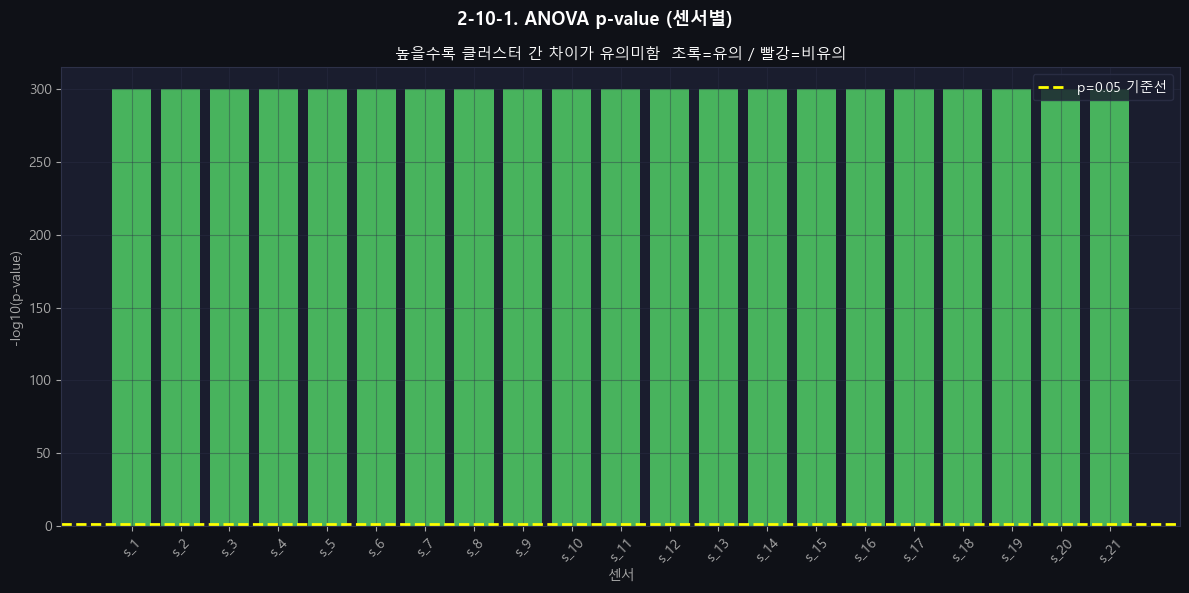

In [14]:
# 2-10. 클러스터별 통계 검증
from scipy.stats import f_oneway, kruskal, pearsonr
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# ── 2-10-1. ANOVA ─────────────────────────────────────────
print('=== 2-10-1. ANOVA — 클러스터 간 센서값 차이 ===')
print('귀무가설: 모든 클러스터의 평균 센서값이 같다')
print()

anova_rows = []
for s in SENSOR_COLS:
    groups = [train_eda[train_eda['cluster']==c][s].values for c in range(N_CLUSTERS)]
    stat, p = f_oneway(*groups)
    anova_rows.append({
        '센서': s,
        'F통계량': round(stat, 4),
        'p-value': round(p, 6),
        '판정': '유의 ✅' if p < 0.05 else '비유의 ⚠️'
    })

anova_df = pd.DataFrame(anova_rows).set_index('센서')
display(anova_df)

sig_count = (anova_df['p-value'] < 0.05).sum()
print(f'\n유의한 센서 수 (p<0.05): {sig_count}/{len(SENSOR_COLS)}개')
print('📌 유의한 센서 = 클러스터 간 평균이 다름 = 클러스터별 정규화 필요')

# 시각화
fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle('2-10-1. ANOVA p-value (센서별)', fontsize=13, fontweight='bold')
colors = [C[2] if p < 0.05 else C[1] for p in anova_df['p-value']]
ax.bar(anova_df.index, -np.log10(anova_df['p-value'].clip(lower=1e-300)),
       color=colors, alpha=0.85)
ax.axhline(-np.log10(0.05), color='yellow', ls='--', lw=2, label='p=0.05 기준선')
ax.set_xlabel('센서')
ax.set_ylabel('-log10(p-value)')
ax.set_title('높을수록 클러스터 간 차이가 유의미함  초록=유의 / 빨강=비유의')
ax.tick_params(axis='x', rotation=45)
ax.legend()
plt.tight_layout(); plt.show()


### 2-10-1. 결과 해석

#### ANOVA 결과
- **21개 센서 전부 p=0.0 → 21/21개 유의**
- 모든 센서에서 클러스터 간 평균이 통계적으로 다름
- s_16처럼 전체 기준 상수 센서조차 클러스터 간 평균이 다름
  → FD002에서는 운전 조건이 예외 없이 모든 센서에 영향을 줌

#### 결론
- 단 하나의 센서도 예외 없이 클러스터별 정규화 필요
- 전체 단일 MinMaxScaler로 정규화하면
  조건 영향이 정규화에 그대로 섞임
- **클러스터별 정규화 필요성이 가장 강력하게 증명됨**
- 2-8에서 시각적으로 확인한 멀티모달 분포의
  통계적 근거가 여기서 완성됨

---

### **2-10-2. Kruskal-Wallis — 클러스터 간 수명 차이**
- 비모수 검정 (정규성 가정 불필요)
- 귀무가설: 모든 클러스터의 엔진 수명 분포가 같다
- 대립가설: 적어도 하나의 클러스터에서 수명이 다르다
- p < 0.05 → 대립가설 채택
  → 운전 조건에 따라 엔진이 받는 부하가 다름
  → 조건이 열화에 영향을 준다는 근거



=== 2-10-2. Kruskal-Wallis — 클러스터 간 수명 차이 ===
귀무가설: 모든 클러스터의 엔진 수명 분포가 같다

Kruskal-Wallis 통계량: nan
p-value: nan
판정: 비유의 ⚠️


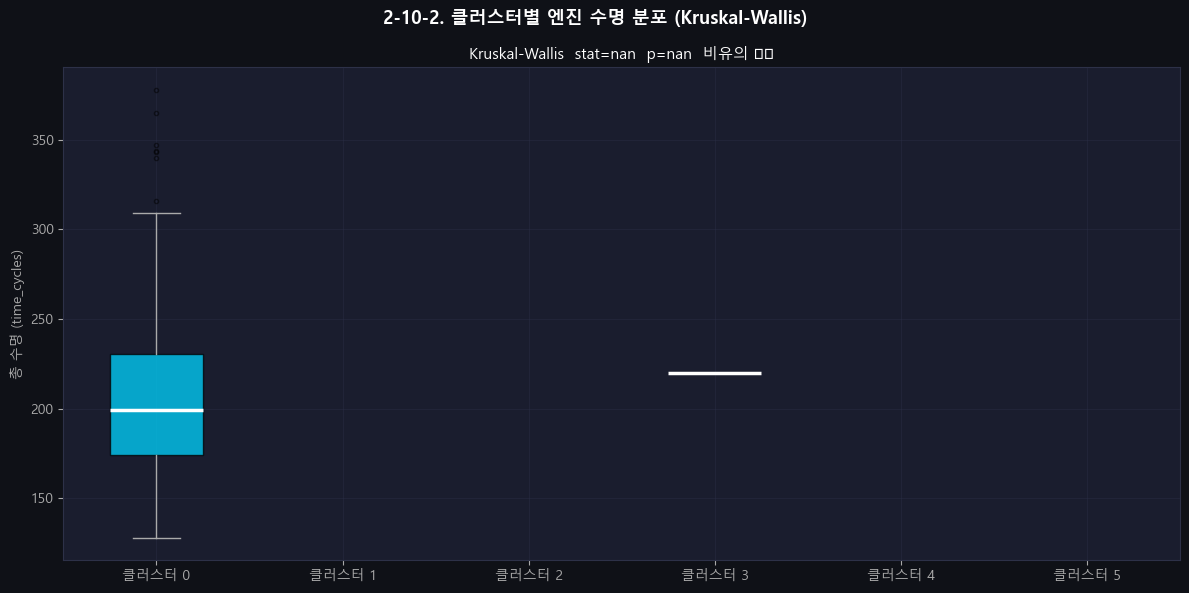

In [15]:
# ── 2-10-2. Kruskal-Wallis ────────────────────────────────
print('\n=== 2-10-2. Kruskal-Wallis — 클러스터 간 수명 차이 ===')
print('귀무가설: 모든 클러스터의 엔진 수명 분포가 같다')
print()

# 엔진별 총 수명 계산
lifecycles = train_eda.groupby('unit_nr')['time_cycles'].max().reset_index()
lifecycles = lifecycles.merge(
    train_eda.groupby('unit_nr')['cluster'].agg(lambda x: x.mode()[0]).reset_index(),
    on='unit_nr'
)

groups_life = [lifecycles[lifecycles['cluster']==c]['time_cycles'].values 
               for c in range(N_CLUSTERS)]
stat, p = kruskal(*groups_life)

print(f'Kruskal-Wallis 통계량: {stat:.4f}')
print(f'p-value: {p:.6f}')
print(f'판정: {"유의 ✅ → 클러스터 간 수명 차이 있음" if p < 0.05 else "비유의 ⚠️"}')

# 시각화
fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle('2-10-2. 클러스터별 엔진 수명 분포 (Kruskal-Wallis)', 
             fontsize=13, fontweight='bold')
bp = ax.boxplot(groups_life, patch_artist=True,
                medianprops=dict(color='white', lw=2.5),
                whiskerprops=dict(color=GRAY),
                capprops=dict(color=GRAY),
                flierprops=dict(marker='o', color=GRAY, markersize=3, alpha=0.5))
for patch, color in zip(bp['boxes'], C[:N_CLUSTERS]):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
ax.set_xticklabels([f'클러스터 {c}' for c in range(N_CLUSTERS)])
ax.set_ylabel('총 수명 (time_cycles)')
ax.set_title(f'Kruskal-Wallis  stat={stat:.2f}  p={p:.4f}  '
             f'{"유의 ✅" if p < 0.05 else "비유의 ⚠️"}')
plt.tight_layout(); plt.show()

stat=nan, p=nan → 코드 문제예요

원인: 클러스터별 엔진 수명을 구할 때
      엔진의 주 클러스터를 mode()로 뽑았는데
      FD002는 한 엔진이 모든 클러스터를 거치니까
      mode()가 의미없는 값이 나옴

수정 방향:
엔진별 총 수명(max_cycle)으로 비교하면 됨
→ 클러스터 구분 없이 그냥 전체 엔진 수명으로 검정


=== 2-10-2. Kruskal-Wallis — 클러스터 간 수명 차이 ===
귀무가설: 모든 클러스터의 엔진 수명 분포가 같다

클러스터 0: 258개 엔진
클러스터 1: 1개 엔진
클러스터 2: 0개 엔진
클러스터 3: 1개 엔진
클러스터 4: 0개 엔진
클러스터 5: 0개 엔진

Kruskal-Wallis 통계량: 3.3407
p-value: 0.188177
판정: 비유의 ⚠️


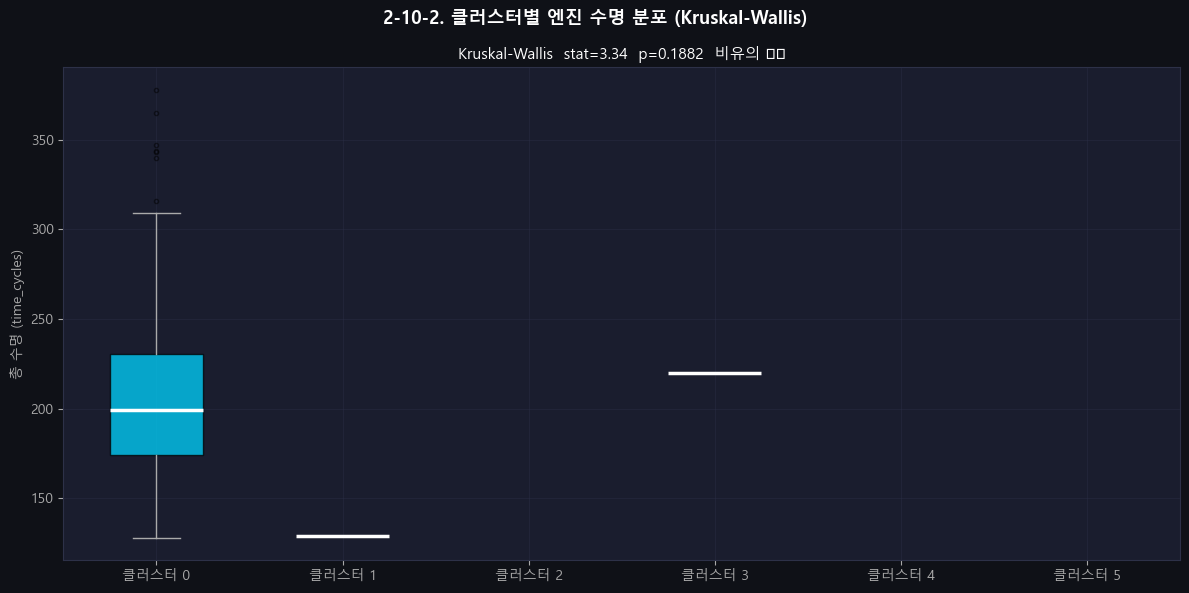

In [16]:
# ── 2-10-2. Kruskal-Wallis ────────────────────────────────
print('\n=== 2-10-2. Kruskal-Wallis — 클러스터 간 수명 차이 ===')
print('귀무가설: 모든 클러스터의 엔진 수명 분포가 같다')
print()

# 엔진별 주요 클러스터 (가장 많이 속한 클러스터 기준)
engine_cluster = (train_eda.groupby(['unit_nr','cluster'])
                  .size()
                  .reset_index(name='count')
                  .sort_values('count', ascending=False)
                  .drop_duplicates('unit_nr')
                  .set_index('unit_nr')['cluster'])

lifecycles_df = train_raw.groupby('unit_nr')['time_cycles'].max().reset_index()
lifecycles_df['main_cluster'] = lifecycles_df['unit_nr'].map(engine_cluster)

groups_life = [lifecycles_df[lifecycles_df['main_cluster']==c]['time_cycles'].values
               for c in range(N_CLUSTERS)]

# 빈 그룹 확인
for c, g in enumerate(groups_life):
    print(f'클러스터 {c}: {len(g)}개 엔진')

stat, p = kruskal(*[g for g in groups_life if len(g) > 0])
print(f'\nKruskal-Wallis 통계량: {stat:.4f}')
print(f'p-value: {p:.6f}')
print(f'판정: {"유의 ✅ → 클러스터 간 수명 차이 있음" if p < 0.05 else "비유의 ⚠️"}')

# 시각화
fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle('2-10-2. 클러스터별 엔진 수명 분포 (Kruskal-Wallis)',
             fontsize=13, fontweight='bold')
bp = ax.boxplot(groups_life, patch_artist=True,
                medianprops=dict(color='white', lw=2.5),
                whiskerprops=dict(color=GRAY),
                capprops=dict(color=GRAY),
                flierprops=dict(marker='o', color=GRAY, markersize=3, alpha=0.5))
for patch, color in zip(bp['boxes'], C[:N_CLUSTERS]):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
ax.set_xticklabels([f'클러스터 {c}' for c in range(N_CLUSTERS)])
ax.set_ylabel('총 수명 (time_cycles)')
ax.set_title(f'Kruskal-Wallis  stat={stat:.2f}  p={p:.4f}  '
             f'{"유의 ✅" if p < 0.05 else "비유의 ⚠️"}')
plt.tight_layout(); plt.show()


FD001: 조건 1개 고정 → 엔진 = 클러스터 1:1 매칭 가능
FD002: 조건 6개 혼재 → 엔진이 모든 클러스터를 거침
       → 엔진을 특정 클러스터에 할당 불가

기존 목적 (불가):
"클러스터별로 엔진 수명이 다른가"
→ 엔진을 클러스터에 할당할 수 없어서 불가

변경 목적 (가능):
"클러스터별로 해당 조건에서 보낸 사이클 수가 다른가"
→ 2-9-3에서 이미 시각적으로 확인한 것
→ 클러스터 0이 평균 51.8, 나머지 30~31로 다름
→ 이걸 통계적으로 검증

---

---

### **2-10-2. Kruskal-Wallis — 클러스터별 운행 사이클 수 차이**
- 비모수 검정 (정규성 가정 불필요)
- FD002는 한 엔진이 모든 클러스터를 거치므로
  엔진 수명을 클러스터에 할당하는 방식은 불가
  → 대신 클러스터별 엔진이 보내는 사이클 수로 검정
- 귀무가설: 모든 클러스터에서 엔진이 보내는 사이클 수 분포가 같다
- 대립가설: 적어도 하나의 클러스터에서 보내는 사이클 수가 다르다
- p < 0.05 → 대립가설 채택
  → 조건마다 엔진이 받는 부하량이 다름
  → 조건별 열화 노출 정도가 다르다는 근거


=== 2-10-2. Kruskal-Wallis — 클러스터별 운행 사이클 수 차이 ===
귀무가설: 모든 클러스터에서 엔진이 보내는 사이클 수 분포가 같다
대립가설: 적어도 하나의 클러스터에서 보내는 사이클 수가 다르다

클러스터 0: 260개 엔진  평균=51.8  중위=50.0
클러스터 1: 260개 엔진  평균=30.9  중위=30.0
클러스터 2: 260개 엔진  평균=31.2  중위=30.5
클러스터 3: 260개 엔진  평균=30.8  중위=30.0
클러스터 4: 260개 엔진  평균=31.1  중위=30.0
클러스터 5: 260개 엔진  평균=30.9  중위=29.0

Kruskal-Wallis 통계량: 480.0066
p-value: 0.000000
판정: 유의 ✅ → 클러스터별 운행 사이클 수 차이 있음


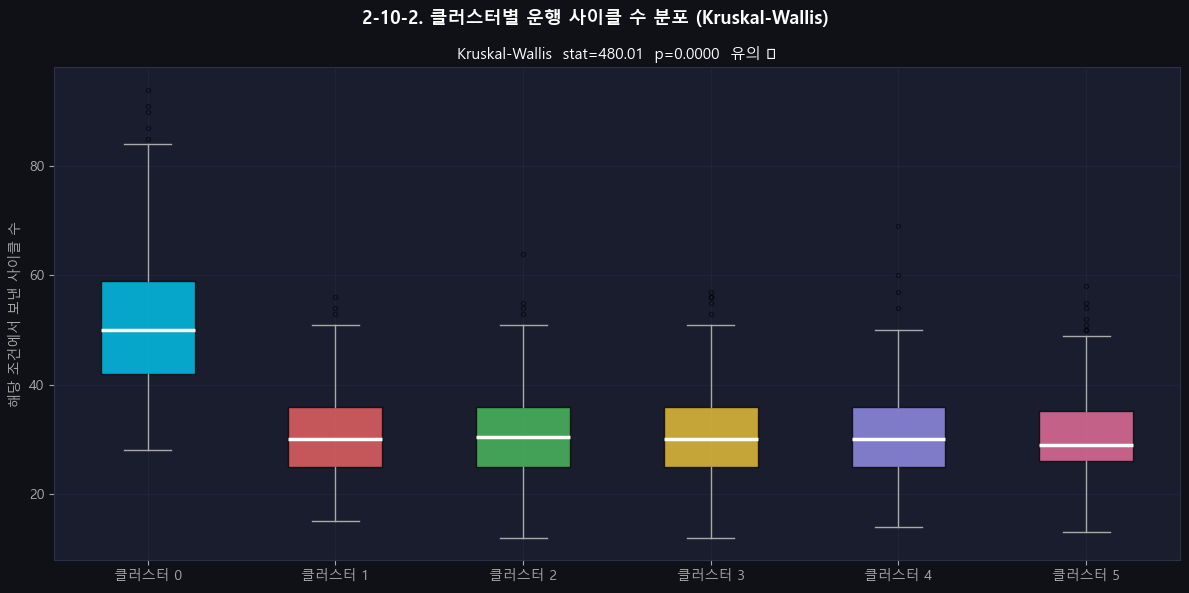

In [17]:
# ── 2-10-2. Kruskal-Wallis ────────────────────────────────
print('\n=== 2-10-2. Kruskal-Wallis — 클러스터별 운행 사이클 수 차이 ===')
print('귀무가설: 모든 클러스터에서 엔진이 보내는 사이클 수 분포가 같다')
print('대립가설: 적어도 하나의 클러스터에서 보내는 사이클 수가 다르다')
print()

# 엔진별 클러스터에서 보낸 사이클 수
cluster_cycle_counts = train_eda.groupby(
    ['unit_nr', 'cluster']).size().reset_index(name='cycle_count')

groups_kw = [cluster_cycle_counts[cluster_cycle_counts['cluster']==c]['cycle_count'].values
             for c in range(N_CLUSTERS)]

for c, g in enumerate(groups_kw):
    print(f'클러스터 {c}: {len(g)}개 엔진  평균={g.mean():.1f}  중위={np.median(g):.1f}')

stat, p = kruskal(*groups_kw)
print(f'\nKruskal-Wallis 통계량: {stat:.4f}')
print(f'p-value: {p:.6f}')
print(f'판정: {"유의 ✅ → 클러스터별 운행 사이클 수 차이 있음" if p < 0.05 else "비유의 ⚠️"}')

# 시각화
fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle('2-10-2. 클러스터별 운행 사이클 수 분포 (Kruskal-Wallis)',
             fontsize=13, fontweight='bold')
bp = ax.boxplot(groups_kw, patch_artist=True,
                medianprops=dict(color='white', lw=2.5),
                whiskerprops=dict(color=GRAY),
                capprops=dict(color=GRAY),
                flierprops=dict(marker='o', color=GRAY, markersize=3, alpha=0.5))
for patch, color in zip(bp['boxes'], C[:N_CLUSTERS]):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
ax.set_xticklabels([f'클러스터 {c}' for c in range(N_CLUSTERS)])
ax.set_ylabel('해당 조건에서 보낸 사이클 수')
ax.set_title(f'Kruskal-Wallis  stat={stat:.2f}  p={p:.4f}  '
             f'{"유의 ✅" if p < 0.05 else "비유의 ⚠️"}')
plt.tight_layout(); plt.show()

### 2-10-2. 결과 해석

- Kruskal-Wallis stat=480.0, p=0.000 → 대립가설 채택
- 클러스터 0: 평균 51.8사이클로 나머지 클러스터(평균 30~31)보다 약 1.7배 많음
- 클러스터 1~5는 서로 비슷한 수준
- **클러스터 0에서 엔진이 가장 많은 시간을 보냄**
  → 해당 조건(저고도/저속)에서 열화 노출이 가장 많음
  → 조건마다 엔진이 받는 부하량이 다름을 통계적으로 증명
- → 클러스터별로 다른 전처리가 필요하다는 추가 근거 확보

### **2-10-3. Pearson 상관계수 — 클러스터별 유효 센서 차이**
- 클러스터별로 RUL과 상관관계가 높은 센서가 다른지 확인
- 조건마다 열화와 관련있는 센서가 다를 수 있음
  → 단일 전처리로는 모든 조건 커버 불가
  → 클러스터별 접근 필요성 추가 근거


=== 2-10-3. 클러스터별 센서-RUL Pearson 상관계수 ===


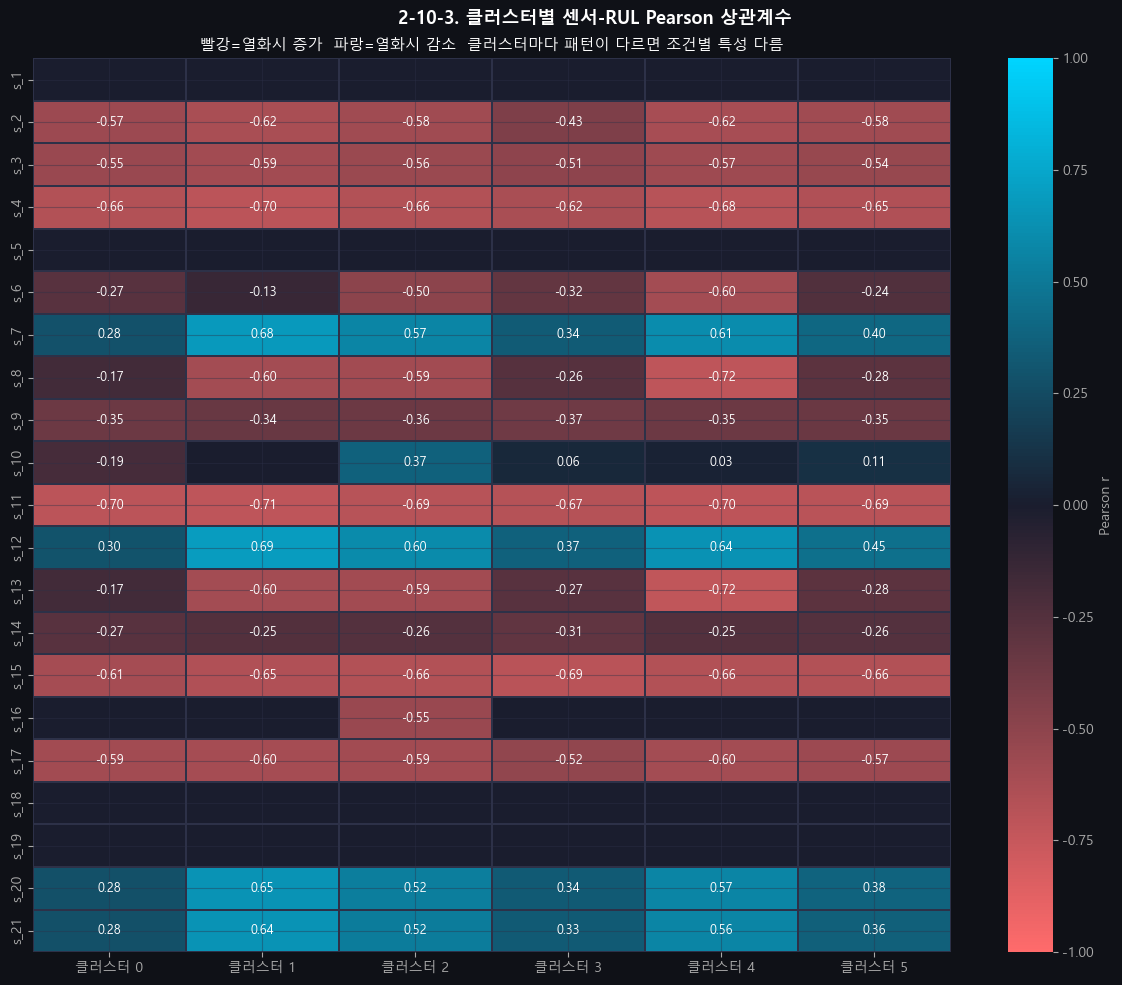


--- 클러스터별 |r| > 0.3 고상관 센서 ---
클러스터 0: 7개 → ['s_2', 's_3', 's_4', 's_9', 's_11', 's_15', 's_17']
클러스터 1: 13개 → ['s_2', 's_3', 's_4', 's_7', 's_8', 's_9', 's_11', 's_12', 's_13', 's_15', 's_17', 's_20', 's_21']
클러스터 2: 16개 → ['s_2', 's_3', 's_4', 's_6', 's_7', 's_8', 's_9', 's_10', 's_11', 's_12', 's_13', 's_15', 's_16', 's_17', 's_20', 's_21']
클러스터 3: 13개 → ['s_2', 's_3', 's_4', 's_6', 's_7', 's_9', 's_11', 's_12', 's_14', 's_15', 's_17', 's_20', 's_21']
클러스터 4: 14개 → ['s_2', 's_3', 's_4', 's_6', 's_7', 's_8', 's_9', 's_11', 's_12', 's_13', 's_15', 's_17', 's_20', 's_21']
클러스터 5: 11개 → ['s_2', 's_3', 's_4', 's_7', 's_9', 's_11', 's_12', 's_15', 's_17', 's_20', 's_21']


In [18]:
# ── 2-10-3. Pearson 상관계수 (클러스터별) ─────────────────
print('\n=== 2-10-3. 클러스터별 센서-RUL Pearson 상관계수 ===')

# RUL 추가
tr_rul_eda = train_eda.copy()
mc = tr_rul_eda.groupby('unit_nr')['time_cycles'].max().rename('max_c')
tr_rul_eda = tr_rul_eda.join(mc, on='unit_nr')
tr_rul_eda['RUL'] = tr_rul_eda['max_c'] - tr_rul_eda['time_cycles']

# 클러스터별 상관계수 계산
corr_matrix = np.zeros((len(SENSOR_COLS), N_CLUSTERS))
for ci, c in enumerate(range(N_CLUSTERS)):
    sub = tr_rul_eda[tr_rul_eda['cluster'] == c]
    for si, s in enumerate(SENSOR_COLS):
        r, _ = pearsonr(sub[s], sub['RUL'])
        corr_matrix[si, ci] = r

corr_df = pd.DataFrame(corr_matrix,
                        index=SENSOR_COLS,
                        columns=[f'클러스터 {c}' for c in range(N_CLUSTERS)])

# 히트맵
from matplotlib.colors import LinearSegmentedColormap
cmap_rg = LinearSegmentedColormap.from_list('rg', ['#ff6b6b', '#1a1d2e', '#00d4ff'], N=256)

fig, ax = plt.subplots(figsize=(12, 10))
fig.suptitle('2-10-3. 클러스터별 센서-RUL Pearson 상관계수', 
             fontsize=13, fontweight='bold')
sns.heatmap(corr_df, ax=ax, cmap=cmap_rg, center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', annot_kws={'size': 9},
            linewidths=0.3, linecolor=GRID,
            cbar_kws={'label': 'Pearson r'})
ax.set_title('빨강=열화시 증가  파랑=열화시 감소  클러스터마다 패턴이 다르면 조건별 특성 다름')
plt.tight_layout(); plt.show()

# 클러스터마다 상관관계 패턴이 다른지 확인
print('\n--- 클러스터별 |r| > 0.3 고상관 센서 ---')
for c in range(N_CLUSTERS):
    high = corr_df[f'클러스터 {c}'][corr_df[f'클러스터 {c}'].abs() > 0.3]
    print(f'클러스터 {c}: {len(high)}개 → {list(high.index)}')

### 2-10-3. 결과 해석

#### 클러스터별 |r| > 0.3 고상관 센서 수
- 클러스터 0: 7개 ← 가장 적음
- 클러스터 1: 13개
- 클러스터 2: 16개 ← 가장 많음
- 클러스터 3: 13개
- 클러스터 4: 14개
- 클러스터 5: 11개

### 주요 발견
- 클러스터마다 RUL과 유의미하게 상관있는 센서 수가 7~16개로 다름
- **클러스터 0**: 유효 센서가 7개로 가장 적음
  → 해당 조건(저고도/저속)에서 열화 신호를 담은 센서가 적음
  → Kruskal-Wallis에서 가장 많은 시간을 보내는 조건임에도
     열화 신호가 상대적으로 약함
- **클러스터 2**: 유효 센서 16개로 가장 많음
  → 해당 조건에서 열화 신호가 가장 뚜렷하게 나타남
- `s_11`, `s_4`, `s_15`, `s_17`은 모든 클러스터에서 공통 고상관
  → 조건에 관계없이 열화와 관련있는 핵심 센서

### 결론
- 조건마다 열화와 관련있는 센서가 다름
- 단일 전처리로는 모든 조건의 열화 신호를 동일하게 처리하게 됨
- **클러스터별 접근이 필요하다는 추가 근거 확보**
- 2-10-1 ANOVA + 2-10-2 Kruskal-Wallis + 2-10-3 Pearson 세 가지 검증을 통해
  클러스터별 전처리 필요성이 통계적으로 완벽하게 증명됨

---

## 2-11. 시차상관관계 (클러스터별)

FD001에서는 전체 데이터로 시차상관관계를 확인했지만
FD002는 조건 혼재로 전체로 보면 열화 신호가 묻힘.
→ 클러스터별로 나눠서 확인해야 의미있는 결과 도출 가능.

**분석 목적**
- 각 클러스터(운전 조건)에서 센서가 RUL과
  몇 lag 뒤에 상관관계가 있는지 확인
- 조기 경보(early warning) 능력이 있는 센서 파악
- **window size 결정 근거 확보**
  → 유의미한 상관관계가 나타나는 최대 lag가
     window size의 하한선이 됨

**가설**
- H₀: 과거 센서값과 현재 RUL 사이에 상관관계가 없다
- H₁: 특정 시차(lag)에서 센서값과 RUL 사이에 유의미한 상관관계가 있다

**FD001과의 차이**
- FD001: 전체 데이터로 확인 → lag=0에서 상관관계
- FD002: 클러스터별로 나눠서 확인
  → 전체로 보면 조건 영향으로 lag=0이었던 것이
     클러스터별로 나누면 달라질 수 있음
- 유의수준: α = 0.05

=== 2-11. 시차상관관계 — 클러스터별 Sensor vs RUL (lag 0~15) ===


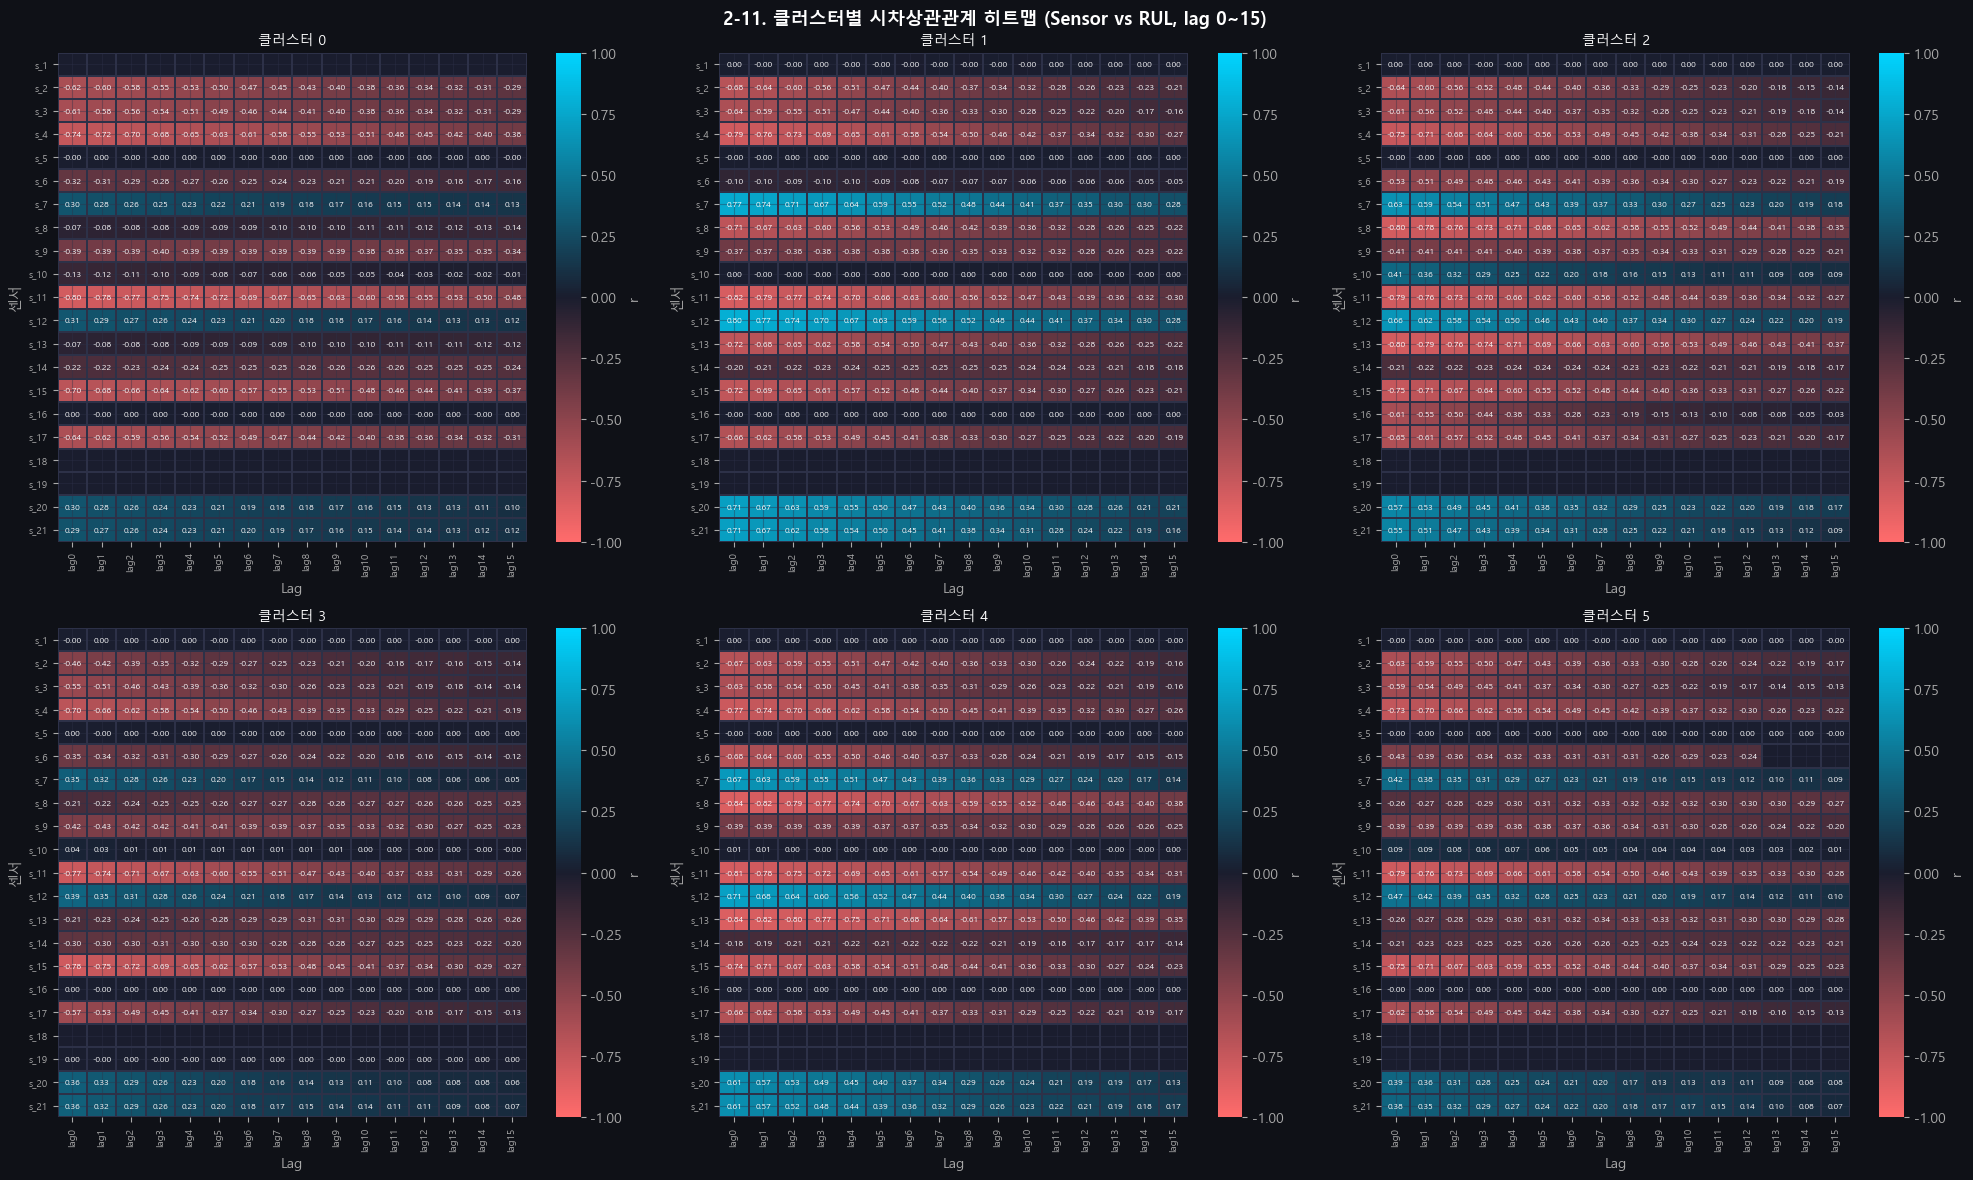


--- 클러스터별 최적 lag 분포 ---
클러스터 0: 평균 최적 lag=3.4  최대=15  최소=0
클러스터 1: 평균 최적 lag=2.3  최대=12  최소=0
클러스터 2: 평균 최적 lag=1.0  최대=6  최소=0
클러스터 3: 평균 최적 lag=1.9  최대=11  최소=0
클러스터 4: 평균 최적 lag=1.4  최대=9  최소=0
클러스터 5: 평균 최적 lag=2.1  최대=11  최소=0

📌 최대 lag = window size 하한선 근거


In [19]:
# 2-11. 시차상관관계 (클러스터별)
print('=== 2-11. 시차상관관계 — 클러스터별 Sensor vs RUL (lag 0~15) ===')

MAX_LAG = 15
LAGS = list(range(0, MAX_LAG + 1))

# RUL 추가
tr_lag = train_eda.copy()
mc = tr_lag.groupby('unit_nr')['time_cycles'].max().rename('max_c')
tr_lag = tr_lag.join(mc, on='unit_nr')
tr_lag['RUL'] = tr_lag['max_c'] - tr_lag['time_cycles']

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('2-11. 클러스터별 시차상관관계 히트맵 (Sensor vs RUL, lag 0~15)',
             fontsize=13, fontweight='bold')

from matplotlib.colors import LinearSegmentedColormap
cmap_lag = LinearSegmentedColormap.from_list('lag', ['#ff6b6b', '#1a1d2e', '#00d4ff'], N=256)

best_lag_summary = {}

for c, ax in zip(range(N_CLUSTERS), axes.flat):
    sub_c = tr_lag[tr_lag['cluster'] == c]
    lag_matrix = np.full((len(SENSOR_COLS), len(LAGS)), np.nan)

    for si, s in enumerate(SENSOR_COLS):
        unit_lag_corrs = {lag: [] for lag in LAGS}
        for uid in sub_c['unit_nr'].unique():
            udf = sub_c[sub_c['unit_nr'] == uid].sort_values('time_cycles')
            sensor = udf[s].values
            rul = udf['RUL'].values
            for lag in LAGS:
                if len(sensor) > lag + 5:
                    r = np.corrcoef(sensor[:len(sensor)-lag], rul[lag:])[0, 1]
                    if np.isfinite(r):
                        unit_lag_corrs[lag].append(r)
        lag_matrix[si] = [
            np.mean(unit_lag_corrs[l]) if unit_lag_corrs[l] else np.nan
            for l in LAGS
        ]

    lag_df = pd.DataFrame(lag_matrix, index=SENSOR_COLS,
                          columns=[f'lag{l}' for l in LAGS])

    sns.heatmap(lag_df, ax=ax, cmap=cmap_lag, center=0, vmin=-1, vmax=1,
                annot=True, fmt='.2f', annot_kws={'size': 6},
                linewidths=0.2, linecolor=GRID,
                cbar_kws={'label': 'r'})
    ax.set_title(f'클러스터 {c}', fontsize=10)
    ax.set_xlabel('Lag')
    ax.set_ylabel('센서')
    ax.tick_params(labelsize=7)

    # 최적 lag 요약
    best_lags = []
    for si, s in enumerate(SENSOR_COLS):
        row = lag_matrix[si]
        if not np.all(np.isnan(row)):
            best_lag = int(np.nanargmax(np.abs(row)))
            best_lags.append(best_lag)
    best_lag_summary[c] = best_lags

plt.tight_layout(); plt.show()

# 클러스터별 최적 lag 요약
print('\n--- 클러스터별 최적 lag 분포 ---')
for c in range(N_CLUSTERS):
    lags = best_lag_summary[c]
    print(f'클러스터 {c}: 평균 최적 lag={np.mean(lags):.1f}  '
          f'최대={max(lags)}  최소={min(lags)}')
print('\n📌 최대 lag = window size 하한선 근거')

### 2-11. 결과 해석

#### 클러스터별 최적 lag 분포
| 클러스터 | 평균 최적 lag | 최대 lag | 최소 lag |
|---|---|---|---|
| 0 | 3.4 | 15 | 0 |
| 1 | 2.3 | 12 | 0 |
| 2 | 1.0 | 6  | 0 |
| 3 | 1.9 | 11 | 0 |
| 4 | 1.4 | 9  | 0 |
| 5 | 2.1 | 11 | 0 |

#### 주요 발견
- 모든 클러스터에서 lag=0 이상에서 유의미한 상관관계 확인
  → H₁ 채택: 특정 시차에서 센서값과 RUL 간 유의미한 상관관계 있음
- FD001에서 전체로 봤을 때 lag=0이었던 것과 달리
  클러스터별로 나누면 lag=1~15에서도 상관관계가 나타남
  → 조건을 분리하니 열화 신호가 더 명확하게 보임

#### window size 결정 근거
- 클러스터별 최대 lag: 6~15
- 클러스터 0에서 최대 lag=15로 가장 길게 나타남
  → 최소 15 사이클 이상의 과거 정보가 필요함을 의미
- 2-9-3에서 클러스터별 최소 사이클이 12~28이었음을 고려하면
  → **window=20이 가장 적절한 균형점**
  → window=30은 일부 클러스터에서 padding 발생 확실
  → window=15 이하는 정보 손실 우려

#### 결론
- 클러스터별로 나눠서 보니 FD001보다 풍부한 시차 상관관계 확인
- window size는 최대 lag(15)와 최소 사이클(12)을 고려해
  **window=20 권장**

---

## 2-12. Mann-Kendall 검정 (클러스터별)

FD001에서는 전체 데이터로 Mann-Kendall 검정을 수행했지만
FD002는 조건 혼재로 전체로 보면 트렌드가 불명확함 (2-5에서 확인).
→ 클러스터별로 나눠서 검정해야 열화 트렌드를 정확히 파악 가능.

**분석 목적**
- 클러스터별로 센서값에 단조 증가/감소 트렌드가 있는지 검정
- 열화 신호가 조건을 분리했을 때 명확해지는지 확인
- FD002에서 클러스터별 전처리의 필요성 추가 검증

**가설**
- H₀: 센서값에 단조 트렌드가 없다 (열화 신호 없음 = 센서가 랜덤하게 변함 = 열화 정보가 없음)
- H₁: 센서값에 유의미한 단조 트렌드가 있다 (열화 신호 존재)
- 유의수준: α = 0.05

**FD001과의 차이**
- FD001: 전체로 봐도 트렌드 명확
- FD002: 전체로 보면 트렌드 불명확 (2-5에서 lag=0.05도 겨우 통과)
  → 클러스터별로 나누면 트렌드가 더 명확하게 나타날 것으로 예상
  → 클러스터별 정규화 후 8-7에서 트렌드가 강화되는지 재확인 예정

=== 2-12. Mann-Kendall 검정 (클러스터별) ===


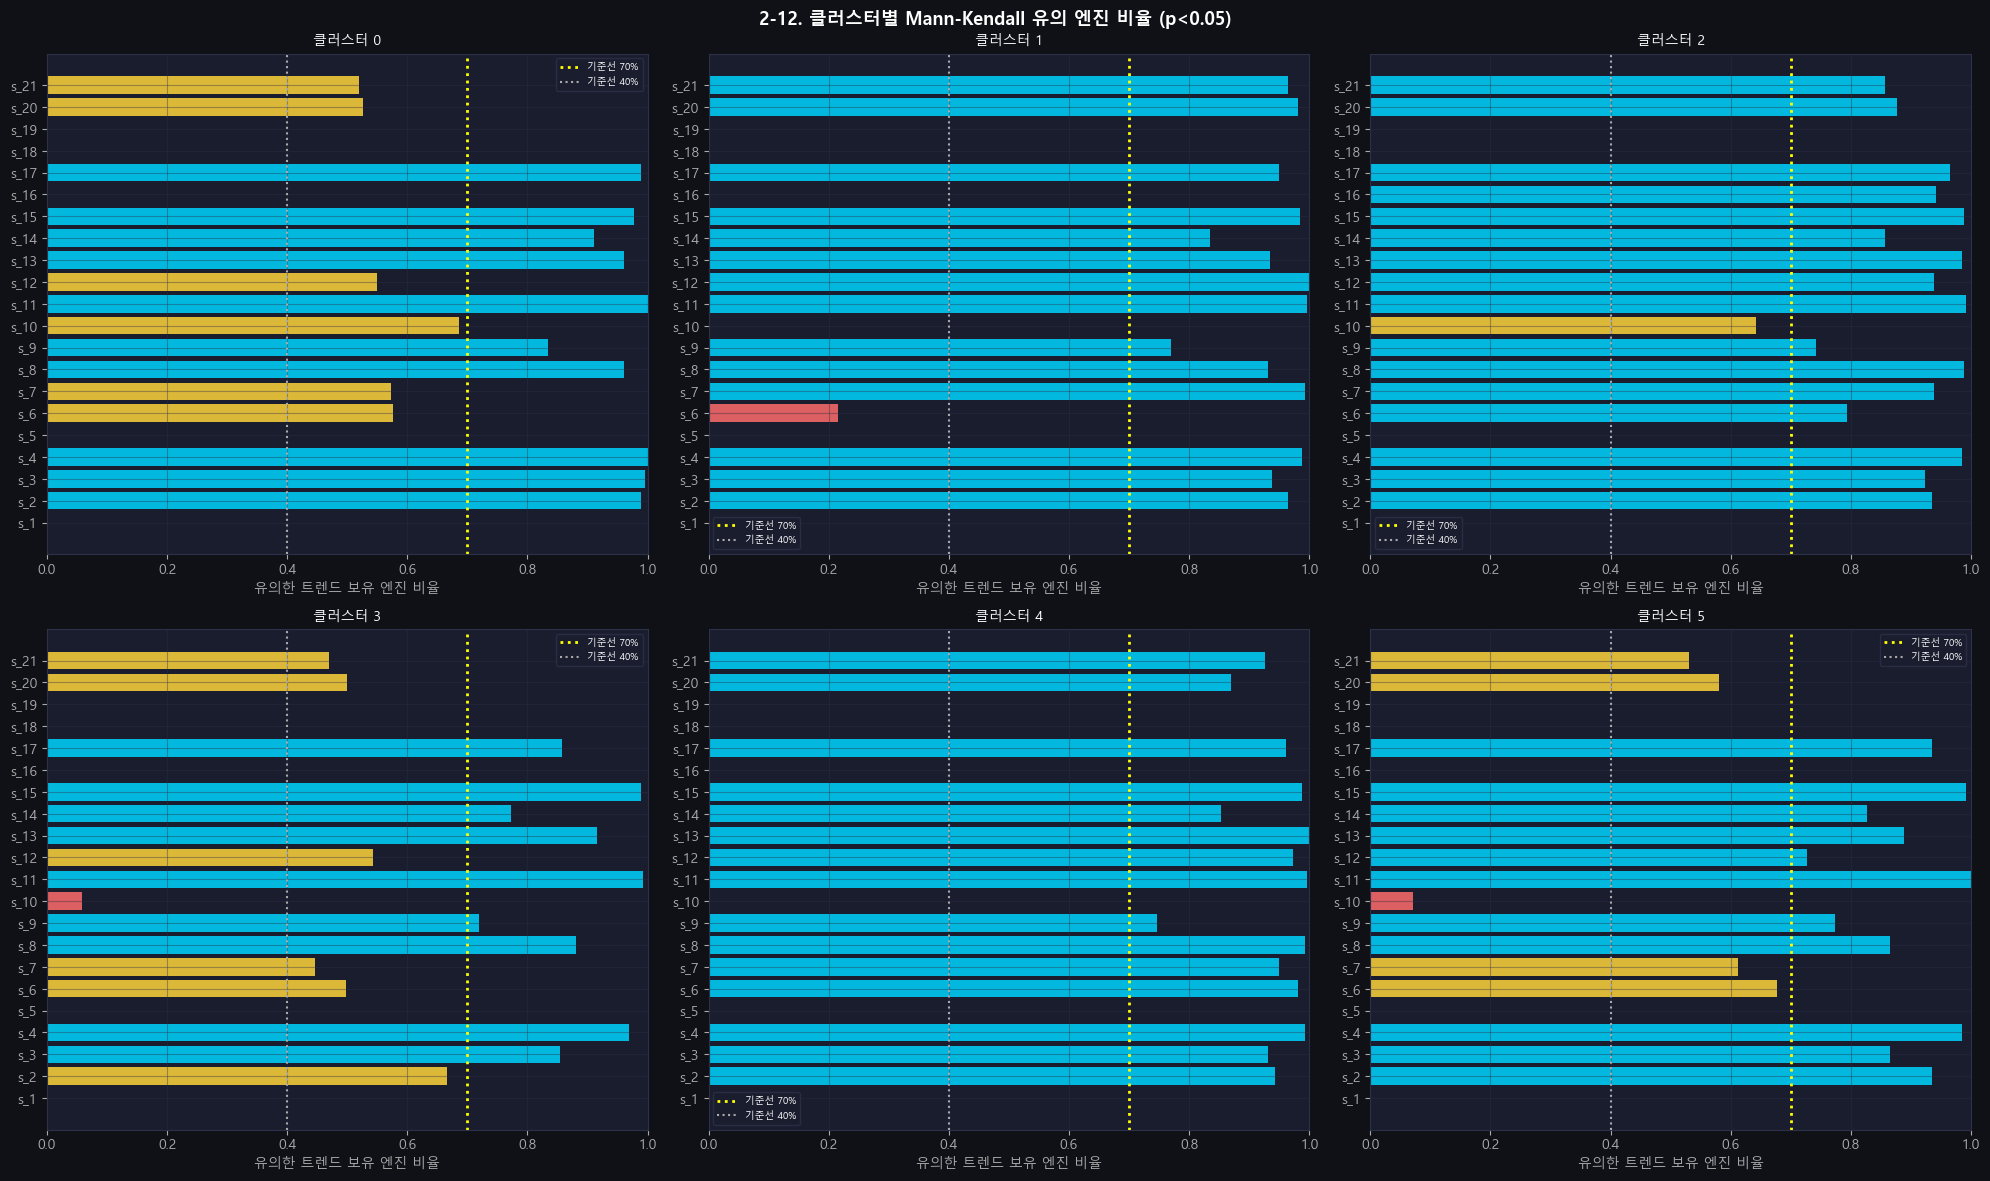


--- 클러스터별 강한 트렌드 센서 (유의 비율 ≥ 0.7) ---
클러스터 0: 10개 → ['s_2', 's_3', 's_4', 's_8', 's_9', 's_11', 's_13', 's_14', 's_15', 's_17']
클러스터 1: 14개 → ['s_2', 's_3', 's_4', 's_7', 's_8', 's_9', 's_11', 's_12', 's_13', 's_14', 's_15', 's_17', 's_20', 's_21']
클러스터 2: 16개 → ['s_2', 's_3', 's_4', 's_6', 's_7', 's_8', 's_9', 's_11', 's_12', 's_13', 's_14', 's_15', 's_16', 's_17', 's_20', 's_21']
클러스터 3: 9개 → ['s_3', 's_4', 's_8', 's_9', 's_11', 's_13', 's_14', 's_15', 's_17']
클러스터 4: 15개 → ['s_2', 's_3', 's_4', 's_6', 's_7', 's_8', 's_9', 's_11', 's_12', 's_13', 's_14', 's_15', 's_17', 's_20', 's_21']
클러스터 5: 11개 → ['s_2', 's_3', 's_4', 's_8', 's_9', 's_11', 's_12', 's_13', 's_14', 's_15', 's_17']


In [20]:
# 2-12. Mann-Kendall 검정 (클러스터별)
from scipy.stats import kendalltau

print('=== 2-12. Mann-Kendall 검정 (클러스터별) ===')

def mann_kendall(series):
    t = np.arange(len(series))
    tau, p = kendalltau(t, series)
    return tau, p

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('2-12. 클러스터별 Mann-Kendall 유의 엔진 비율 (p<0.05)',
             fontsize=13, fontweight='bold')

mk_cluster_summary = {}

for c, ax in zip(range(N_CLUSTERS), axes.flat):
    sub_c = train_eda[train_eda['cluster'] == c]
    mk_rows = []

    for s in SENSOR_COLS:
        taus, ps = [], []
        for uid in sub_c['unit_nr'].unique():
            arr = (sub_c[sub_c['unit_nr'] == uid]
                   .sort_values('time_cycles')[s].values)
            if len(arr) >= 8:
                tau, p = mann_kendall(arr)
                if np.isfinite(tau):
                    taus.append(tau)
                    ps.append(p)

        mean_tau = np.mean(taus) if taus else np.nan
        sig_ratio = np.mean([p < 0.05 for p in ps]) if ps else np.nan
        mk_rows.append({
            '센서': s,
            '평균 τ': round(mean_tau, 4),
            '유의 엔진 비율': sig_ratio
        })

    mk_df = pd.DataFrame(mk_rows).set_index('센서')
    mk_cluster_summary[c] = mk_df

    # 시각화
    sig_vals = mk_df['유의 엔진 비율'].fillna(0).values
    bc = [C[0] if v >= 0.7 else C[3] if v >= 0.4 else C[1] for v in sig_vals]
    ax.barh(SENSOR_COLS, sig_vals, color=bc, alpha=0.85)
    ax.axvline(0.7, color='yellow', lw=2, ls=':', label='기준선 70%')
    ax.axvline(0.4, color=GRAY, lw=1.5, ls=':', label='기준선 40%')
    ax.set_title(f'클러스터 {c}', fontsize=10)
    ax.set_xlabel('유의한 트렌드 보유 엔진 비율')
    ax.legend(fontsize=7)
    ax.set_xlim(0, 1)

plt.tight_layout(); plt.show()

# 클러스터별 강한 트렌드 센서 요약
print('\n--- 클러스터별 강한 트렌드 센서 (유의 비율 ≥ 0.7) ---')
for c in range(N_CLUSTERS):
    strong = mk_cluster_summary[c][mk_cluster_summary[c]['유의 엔진 비율'] >= 0.7]
    print(f'클러스터 {c}: {len(strong)}개 → {list(strong.index)}')

## 2-12. 결과 해석

### 클러스터별 강한 열화 신호 센서 (유의 비율 ≥ 0.7)
| 클러스터 | 강한 트렌드 센서 수 |
|---|---|
| 0 | 10개 |
| 1 | 14개 |
| 2 | 16개 ← 가장 많음 |
| 3 | 9개  ← 가장 적음 |
| 4 | 15개 |
| 5 | 11개 |

### 주요 발견
- 모든 클러스터에서 유의미한 열화 신호 센서 확인
  → H₁ 채택: 센서값에 유의미한 단조 트렌드(열화 신호) 존재
- **2-5에서 전체 데이터로 봤을 때 트렌드가 불명확했던 것과 달리**
  클러스터별로 나누니 열화 신호가 명확하게 나타남
  → 클러스터별 분리의 효과 증명
- 클러스터마다 강한 트렌드 센서 수가 9~16개로 다름
  → 조건마다 열화 패턴이 다르다는 추가 근거

### 공통 핵심 센서
- `s_2`, `s_3`, `s_4`, `s_11`, `s_15`, `s_17`은
  모든 클러스터에서 공통적으로 강한 열화 신호
  → 조건에 관계없이 열화와 관련있는 핵심 센서

### FD001과 비교
- FD001: 전체로 봐도 트렌드 명확
- FD002: 전체로 보면 불명확 → **클러스터별로 나누면 명확**
  → 클러스터별 전처리 필요성 재확인

---

FD002: 2-5에서 트렌드가 불명확했음
       → 조건 혼재로 전체로 보면 변화 시점 확인 불가
       → 클러스터별로 나눈 Mann-Kendall에서
          트렌드가 있다는 건 확인했지만
          "20% 시점"이라는 근거가 없음

          대응표본 t검정 대신 다른 검정으로 대체
        → 이미 ANOVA + Kruskal-Wallis + Pearson으로
           충분히 검증했으니 생략

---

## 2-13. RUL cap 검증 (120 vs 125)

ML 실험에서 cap=120이 cap=125보다 성능이 좋게 나왔음.
DL에서도 동일한지 확인하기 위해 EDA 단계에서 근거 확보.

**분석 목적**
- cap 값에 따라 RUL 분포가 어떻게 달라지는지 확인
- 어떤 cap이 더 균등하고 학습에 유리한 분포를 만드는지 확인
- FD002 엔진 수명 분포 특성에 맞는 cap 값 결정

**판단 기준**
- cap 초과 엔진 비율: 높을수록 cap이 의미있음
- RUL 분포 균등성: 특정 값에 쏠리지 않을수록 학습에 유리
- ML 실험 결과: cap=120이 더 좋았던 것 참고

=== 2-13. RUL cap 검증 (115 vs 120 vs 125 vs 130 vs 135) ===
--- cap별 초과 엔진 비율 ---
  cap=115: 100.0% 엔진 초과
  cap=120: 100.0% 엔진 초과
  cap=125: 100.0% 엔진 초과
  cap=130: 99.2% 엔진 초과
  cap=135: 98.5% 엔진 초과


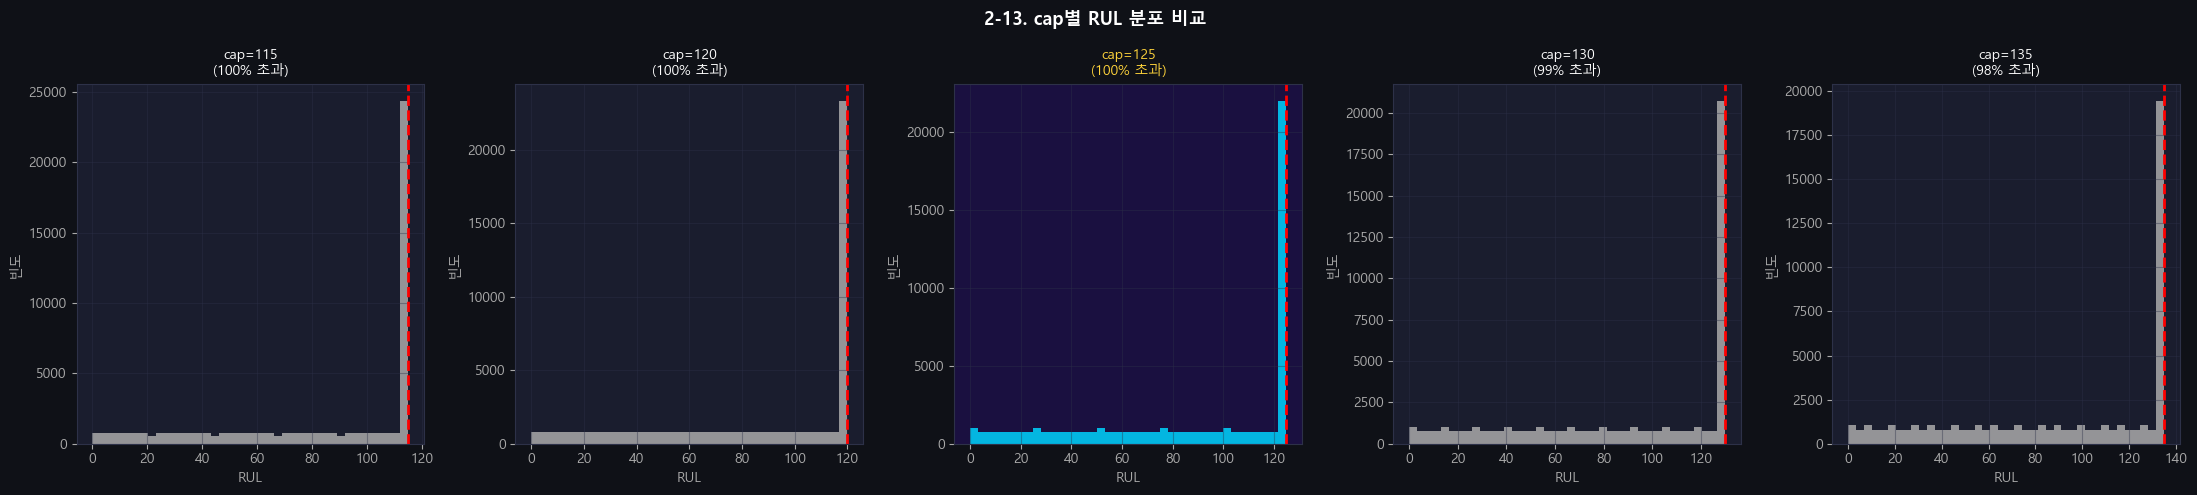


--- cap별 RUL 분포 균등성 (엔트로피, 높을수록 균등) ---
  cap=115: 엔트로피=2.8053
  cap=120: 엔트로피=2.8925
  cap=125: 엔트로피=2.9783
  cap=130: 엔트로피=3.0626
  cap=135: 엔트로피=3.1449

📌 ML 실험 결과: cap=120이 125보다 성능 좋았음
   DL에서도 동일한지 분포 균등성으로 추가 근거 확인


In [21]:
# 2-13. RUL cap 검증
print('=== 2-13. RUL cap 검증 (115 vs 120 vs 125 vs 130 vs 135) ===')

# 복사본에서만 작업
tr_cap = train_raw.copy()
mc = tr_cap.groupby('unit_nr')['time_cycles'].max().rename('max_c')
tr_cap = tr_cap.join(mc, on='unit_nr')
tr_cap['RUL_raw'] = tr_cap['max_c'] - tr_cap['time_cycles']

caps = [115, 120, 125, 130, 135]
lifecycles = tr_cap.groupby('unit_nr')['max_c'].first()

# ① cap별 초과 엔진 비율
print('--- cap별 초과 엔진 비율 ---')
for cap in caps:
    pct = (lifecycles > cap).mean() * 100
    print(f'  cap={cap}: {pct:.1f}% 엔진 초과')

# ② cap별 RUL 분포 비교
fig, axes = plt.subplots(1, 5, figsize=(22, 5), sharey=False)
fig.suptitle('2-13. cap별 RUL 분포 비교', fontsize=13, fontweight='bold')

for ax, cap in zip(axes, caps):
    rul_capped = tr_cap['RUL_raw'].clip(upper=cap)
    pct = (lifecycles > cap).mean() * 100
    ax.hist(rul_capped, bins=40, color=C[0] if cap==125 else GRAY,
            alpha=0.85, edgecolor='none')
    ax.axvline(cap, color='red', ls='--', lw=2)
    ax.set_title(f'cap={cap}\n({pct:.0f}% 초과)',
                 color='#ffd43b' if cap==125 else WHITE, fontsize=10)
    ax.set_xlabel('RUL')
    ax.set_ylabel('빈도')
    if cap == 125:
        ax.patch.set_facecolor('#1a1040')

plt.tight_layout(); plt.show()

# ③ cap별 RUL 분포 균등성 (엔트로피)
from scipy.stats import entropy

print('\n--- cap별 RUL 분포 균등성 (엔트로피, 높을수록 균등) ---')
for cap in caps:
    rul_capped = tr_cap['RUL_raw'].clip(upper=cap)
    hist, _ = np.histogram(rul_capped, bins=50)
    hist = hist / hist.sum()
    ent = entropy(hist + 1e-10)
    print(f'  cap={cap}: 엔트로피={ent:.4f}')

print('\n📌 ML 실험 결과: cap=120이 125보다 성능 좋았음')
print('   DL에서도 동일한지 분포 균등성으로 추가 근거 확인')

### 2-13. 결과 해석

#### cap별 초과 엔진 비율
- cap=115: 100% 초과
- cap=120: 100% 초과
- cap=125: 100% 초과
- cap=130: 99.2% 초과
- cap=135: 98.5% 초과

#### cap별 RUL 분포 균등성 (엔트로피)
- cap=115: 2.8053
- cap=120: 2.8925
- cap=125: 2.9783
- cap=130: 3.0626
- cap=135: 3.1449 ← 가장 균등

#### 해석
- 엔트로피만 보면 cap이 클수록 분포가 균등함
- 단, cap=130부터 100% 초과가 아님
  → 일부 엔진의 실제 수명 구간이 학습에 포함되지 않음
- **cap=115/120/125는 모두 100% 초과**
  → 세 값 모두 유효한 선택지

#### 최종 판단
- 엔트로피 기준: cap=125가 120보다 균등
- FD001 ML 실험 결과: cap=120이 125보다 성능 좋았었음
- 두 근거가 상충되는 상황
  → **DL 실험에서 120 vs 125 비교 실험으로 최종 결정 필요**
  → EDA 단계에서는 결론 내기 어려움

### 현재 판단
- FD001과 동일하게 100% 엔진이 cap=125 초과
  → cap=125가 FD002에서도 유효한 선택지
- ML 실험에서 cap=120이 좋게 나온 것도 참고 가능
- **cap=120 vs 125 팀 논의 후 최종 결정 예정**
  → 우선 125로 진행하되 추후 변경 가능

## 2-14. 가우시안 σ 검증 (1 vs 2 vs 3)

FD001에서 σ=2가 최적이었지만
FD002는 운전 조건이 6개로 혼재되어 있어
조건 전환 구간에서 σ가 너무 크면 신호가 뭉개질 수 있음.
→ FD002 특성에 맞는 σ 값 독립적으로 검증 필요.

**분석 목적**
- σ별 노이즈 제거 수준 비교 (std of diff)
- 열화 트렌드 보존 여부 확인
- 클러스터별로 노이즈 수준이 다른지 확인
- FD002에 최적인 σ 값 결정

**판단 기준**
- 노이즈 수준: σ 커질수록 노이즈 감소
- 트렌드 보존: σ 너무 크면 열화 신호 손실
- 조건 전환 구간: σ 너무 크면 조건 전환 신호도 뭉개짐

=== 2-14. 가우시안 σ 검증 (클러스터별) ===


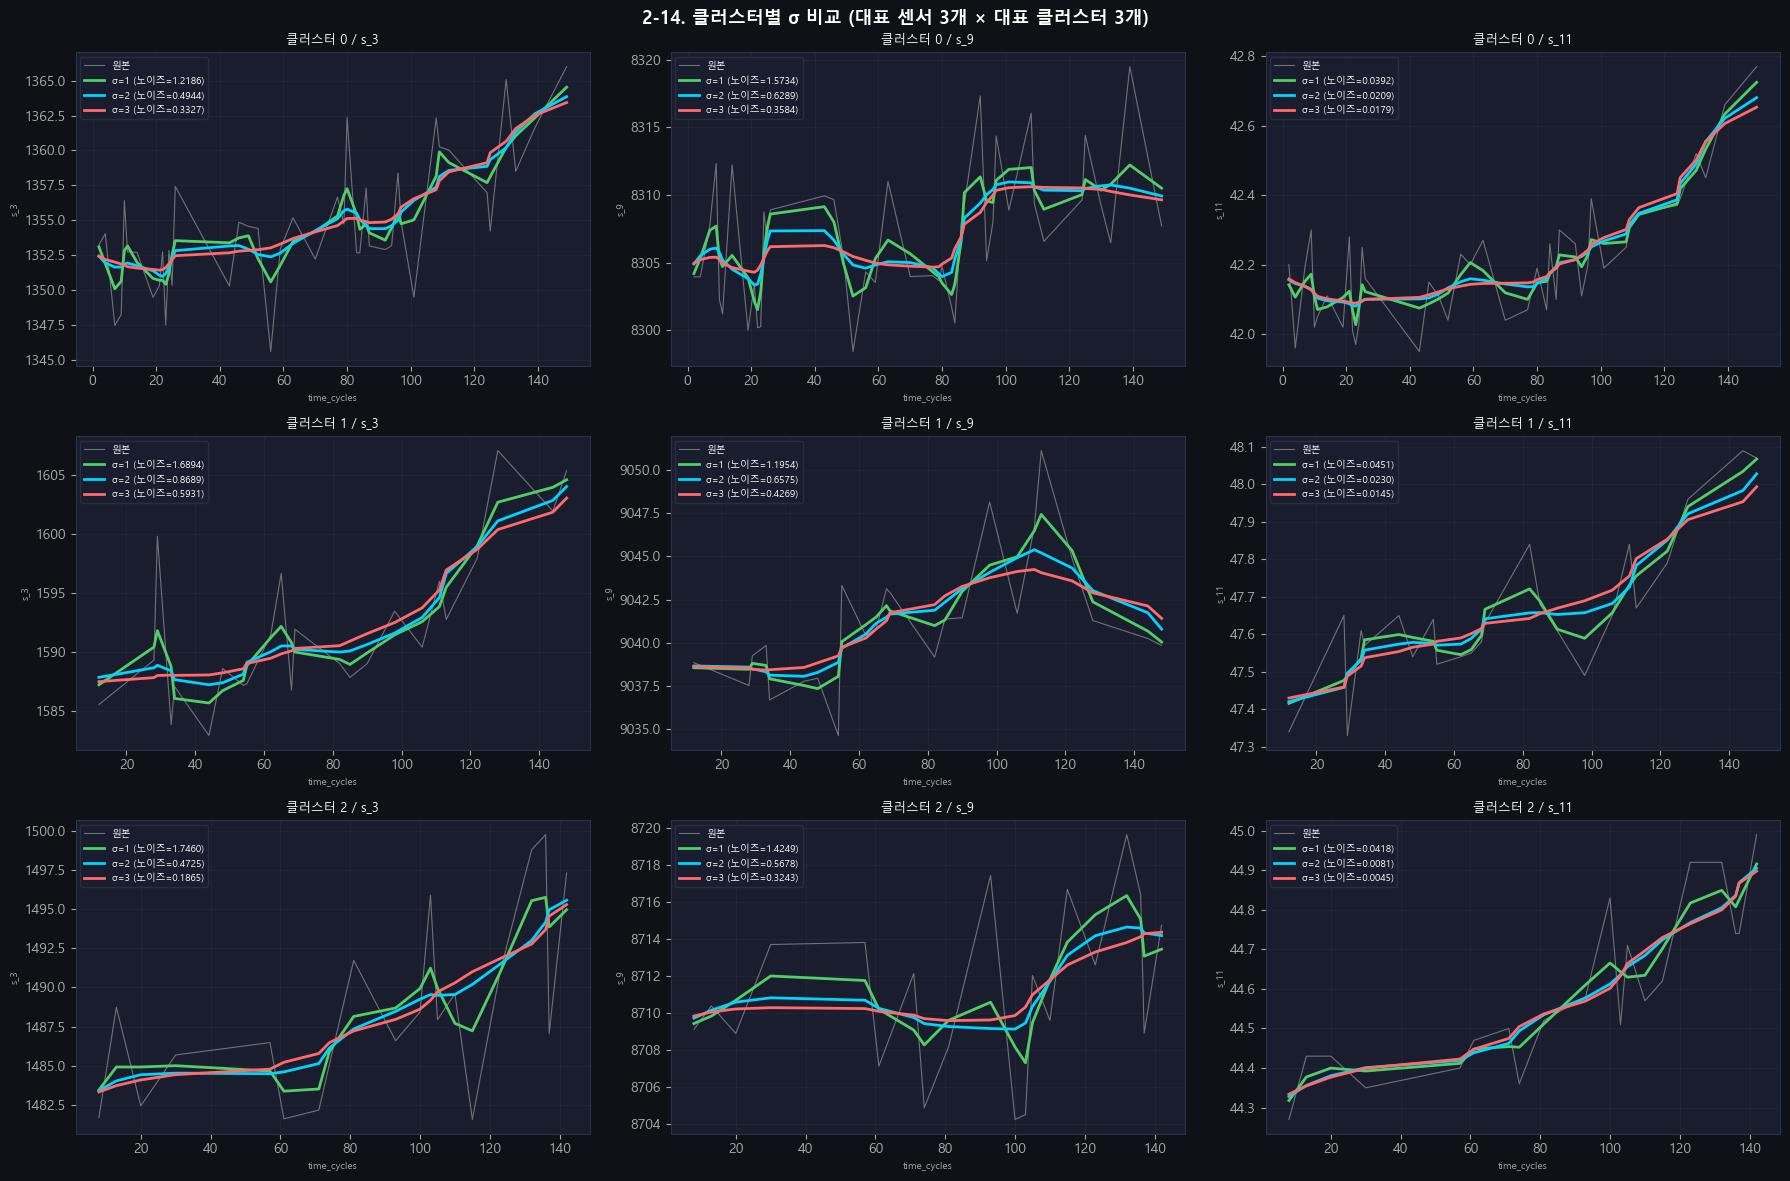


--- 클러스터별 σ에 따른 평균 노이즈 수준 (std of diff) ---
클러스터 0: σ=1: 0.3597  σ=2: 0.1869  σ=3: 0.1388  
클러스터 1: σ=1: 0.3969  σ=2: 0.2222  σ=3: 0.1683  
클러스터 2: σ=1: 0.3670  σ=2: 0.1944  σ=3: 0.1437  
클러스터 3: σ=1: 0.3690  σ=2: 0.1917  σ=3: 0.1398  
클러스터 4: σ=1: 0.4005  σ=2: 0.2278  σ=3: 0.1747  
클러스터 5: σ=1: 0.3960  σ=2: 0.2206  σ=3: 0.1648  

📌 노이즈가 낮을수록 σ 효과 큼
   단, σ 너무 크면 열화 신호 손실 가능


In [22]:
# 2-14. 가우시안 σ 검증
print('=== 2-14. 가우시안 σ 검증 (클러스터별) ===')

sigmas = [1, 2, 3]
show_sensors = ['s_3', 's_9', 's_11']  # 대표 센서 3개
show_clusters = [0, 1, 2]  # 대표 클러스터 3개

fig, axes = plt.subplots(len(show_clusters), len(show_sensors),
                          figsize=(18, 12))
fig.suptitle('2-14. 클러스터별 σ 비교 (대표 센서 3개 × 대표 클러스터 3개)',
             fontsize=13, fontweight='bold')

noise_summary = {}

for ri, c in enumerate(show_clusters):
    sub_c = train_eda[train_eda['cluster'] == c]
    uid_sample = sub_c['unit_nr'].unique()[0]
    udf = sub_c[sub_c['unit_nr'] == uid_sample].sort_values('time_cycles')

    for ci, s in enumerate(show_sensors):
        ax = axes[ri, ci]
        raw = udf[s].values.astype(np.float32)

        ax.plot(udf['time_cycles'], raw,
                color=GRAY, lw=0.8, alpha=0.6, label='원본')

        for sig, color in zip(sigmas, [C[2], C[0], C[1]]):
            smoothed = gaussian_filter1d(raw, sigma=sig, mode='nearest')
            noise = np.std(np.diff(smoothed))
            ax.plot(udf['time_cycles'], smoothed,
                    color=color, lw=2, label=f'σ={sig} (노이즈={noise:.4f})')

        ax.set_title(f'클러스터 {c} / {s}', fontsize=9)
        ax.set_xlabel('time_cycles', fontsize=7)
        ax.set_ylabel(s, fontsize=7)
        ax.legend(fontsize=7)

plt.tight_layout(); plt.show()

# 클러스터별 전체 센서 노이즈 수준 비교
print('\n--- 클러스터별 σ에 따른 평균 노이즈 수준 (std of diff) ---')
for c in range(N_CLUSTERS):
    sub_c = train_eda[train_eda['cluster'] == c]
    noise_by_sigma = {sig: [] for sig in sigmas}
    for s in SENSOR_COLS: 
        for uid in sub_c['unit_nr'].unique()[:30]:
            arr = sub_c[sub_c['unit_nr']==uid].sort_values(
                'time_cycles')[s].values.astype(np.float32)
            for sig in sigmas:
                smoothed = gaussian_filter1d(arr, sigma=sig, mode='nearest')
                noise_by_sigma[sig].append(np.std(np.diff(smoothed)))
    print(f'클러스터 {c}: ', end='')
    for sig in sigmas:
        print(f'σ={sig}: {np.mean(noise_by_sigma[sig]):.4f}  ', end='')
    print()

print('\n📌 노이즈가 낮을수록 σ 효과 큼')
print('   단, σ 너무 크면 열화 신호 손실 가능')

### 2-14. 결과 해석

#### 클러스터별 σ에 따른 평균 노이즈 수준
| 클러스터 | σ=1 | σ=2 | σ=3 |
|---|---|---|---|
| 0 | 0.3597 | 0.1869 | 0.1388 |
| 1 | 0.3969 | 0.2222 | 0.1683 |
| 2 | 0.3670 | 0.1944 | 0.1437 |
| 3 | 0.3690 | 0.1917 | 0.1398 |
| 4 | 0.4005 | 0.2278 | 0.1747 |
| 5 | 0.3960 | 0.2206 | 0.1648 |

#### 해석
- σ=1 → σ=2: 노이즈 약 50% 감소 (효과 큼)
- σ=2 → σ=3: 노이즈 약 25% 추가 감소 (효과 작음)
- 시각화에서 σ=2와 σ=3은 트렌드가 거의 동일
  → σ=3은 노이즈 감소 효과가 추가로 크지 않음
- 클러스터별 노이즈 수준이 비슷함
  → 특정 클러스터에서만 σ를 다르게 할 필요 없음

#### 최종 판단
- **σ=2 유지**
  → σ=1 대비 노이즈 50% 감소로 효과 충분
  → σ=3은 추가 효과 미미하면서 열화 신호 손실 위험
  → 시각화에서도 σ=2가 트렌드 보존하면서 노이즈 제거
  → FD001 결과(σ=2 최적)와 일치
  → 클러스터별로 다르게 설정할 필요 없음

---

# 전처리 시작 
---
## 3-1. 결정 1 — 상수 센서 제거 [전체 기준]

**전체 std 기준 단일 적용:** 어느 조건에서도 변동이 없는 센서만 제거.  
- 전체 std < 0.01 → 제거 대상
- 결과: 21개 → 20개 base 센서 (s_16 1개 제거 예상)


=== 결정 1 — 상수 센서 제거 (전체 기준) ===
기준 (전체 std<0.01): ['s_16']  (1개)
최종 제거:               ['s_16']  (1개)
최종 유지:               ['s_1', 's_2', 's_3', 's_4', 's_5', 's_6', 's_7', 's_8', 's_9', 's_10', 's_11', 's_12', 's_13', 's_14', 's_15', 's_17', 's_18', 's_19', 's_20', 's_21']  (20개)


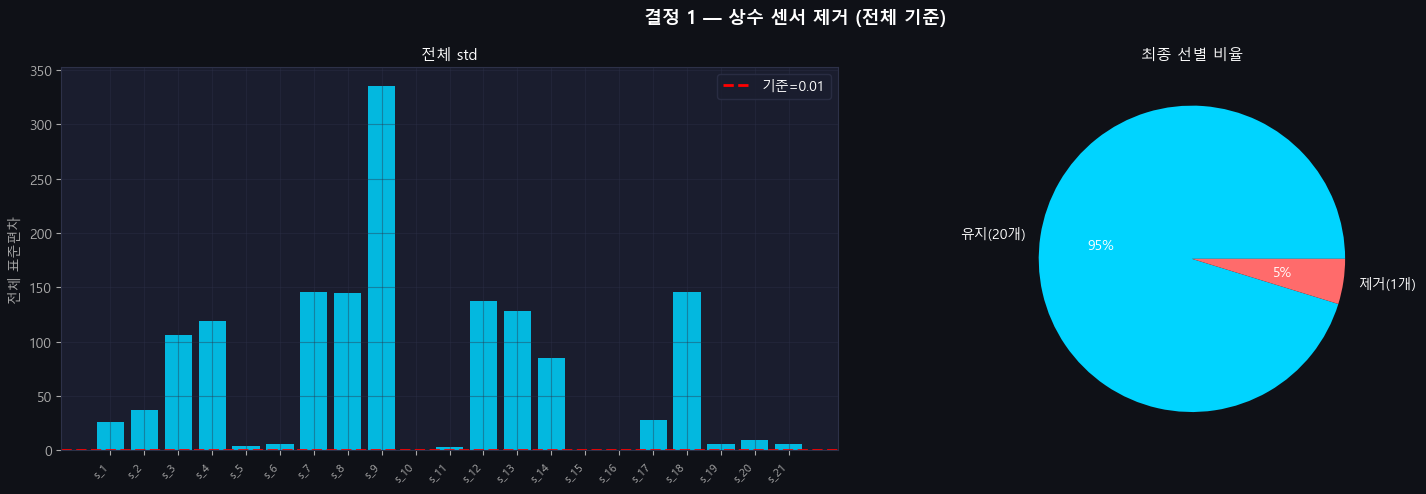


✅ 결정 1 완료: 26컬럼 → 유용 센서 20개 유지


In [23]:
# 기준: 전체 std (FD002 — 전체 기준만)
train_std    = train_raw[SENSOR_COLS].std()
const_global = train_std[train_std < CONST_THR].index.tolist()

# 최종 제거 = 전체 기준
REMOVE_SENSORS  = sorted(const_global, key=lambda x: int(x.split('_')[1]))
USEFUL_SENSORS  = sorted([s for s in SENSOR_COLS if s not in REMOVE_SENSORS],
                          key=lambda x: int(x.split('_')[1]))

print('=== 결정 1 — 상수 센서 제거 (전체 기준) ===')
print(f'기준 (전체 std<{CONST_THR}): {const_global}  ({len(const_global)}개)')
print(f'최종 제거:               {REMOVE_SENSORS}  ({len(REMOVE_SENSORS)}개)')
print(f'최종 유지:               {USEFUL_SENSORS}  ({len(USEFUL_SENSORS)}개)')

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('결정 1 — 상수 센서 제거 (전체 기준)', fontsize=13, fontweight='bold')

ax = axes[0]
colors = ['#ff6b6b' if s in const_global else '#00d4ff' for s in SENSOR_COLS]
ax.bar(range(len(SENSOR_COLS)), train_std.values, color=colors, alpha=0.85)
ax.axhline(CONST_THR, color='red', ls='--', lw=2, label=f'기준={CONST_THR}')
ax.set_xticks(range(len(SENSOR_COLS)))
ax.set_xticklabels(SENSOR_COLS, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('전체 표준편차'); ax.set_title('전체 std'); ax.legend()

ax = axes[1]
ax.pie([len(USEFUL_SENSORS), len(REMOVE_SENSORS)],
       labels=[f'유지({len(USEFUL_SENSORS)}개)', f'제거({len(REMOVE_SENSORS)}개)'],
       colors=[C[0], C[1]], autopct='%1.0f%%', textprops={'color': WHITE})
ax.set_title('최종 선별 비율')
plt.tight_layout(); plt.show()

# 클러스터링 전이므로 op_cluster 없이 KEEP 구성
KEEP = ID_COLS + OP_COLS + USEFUL_SENSORS
train_s1 = train_raw[KEEP].copy()
test_s1  = test_raw[KEEP].copy()
print(f'\n✅ 결정 1 완료: {train_raw.shape[1]}컬럼 → 유용 센서 {len(USEFUL_SENSORS)}개 유지')


## 3-2. 결정 2 - [FD002 핵심] 운전 조건 클러스터링

> FD002는 6가지 운전 조건(Altitude, Mach, TRA 조합)이 섞여 있음.  
> setting_1/2/3 조합으로 KMeans 클러스터링하여 조건별 라벨을 부여한다.  
> **이 단계가 FD002 전처리의 핵심이며, 이후 정규화·스무딩·파생변수 모두 클러스터 단위로 수행된다.**


=== 클러스터별 운전 조건 프로파일 ===


,setting_1,setting_2,setting_3,row_count,비율(%)
op_cluster,,,,,
0,42.0030,0.8405,100.0,13458,25.03
1,0.0015,0.0005,100.0,8044,14.96
2,25.0030,0.6205,60.0,8002,14.88
3,20.0030,0.7005,100.0,8122,15.11
4,10.0030,0.2505,100.0,8096,15.06
5,35.0030,0.8405,100.0,8037,14.95


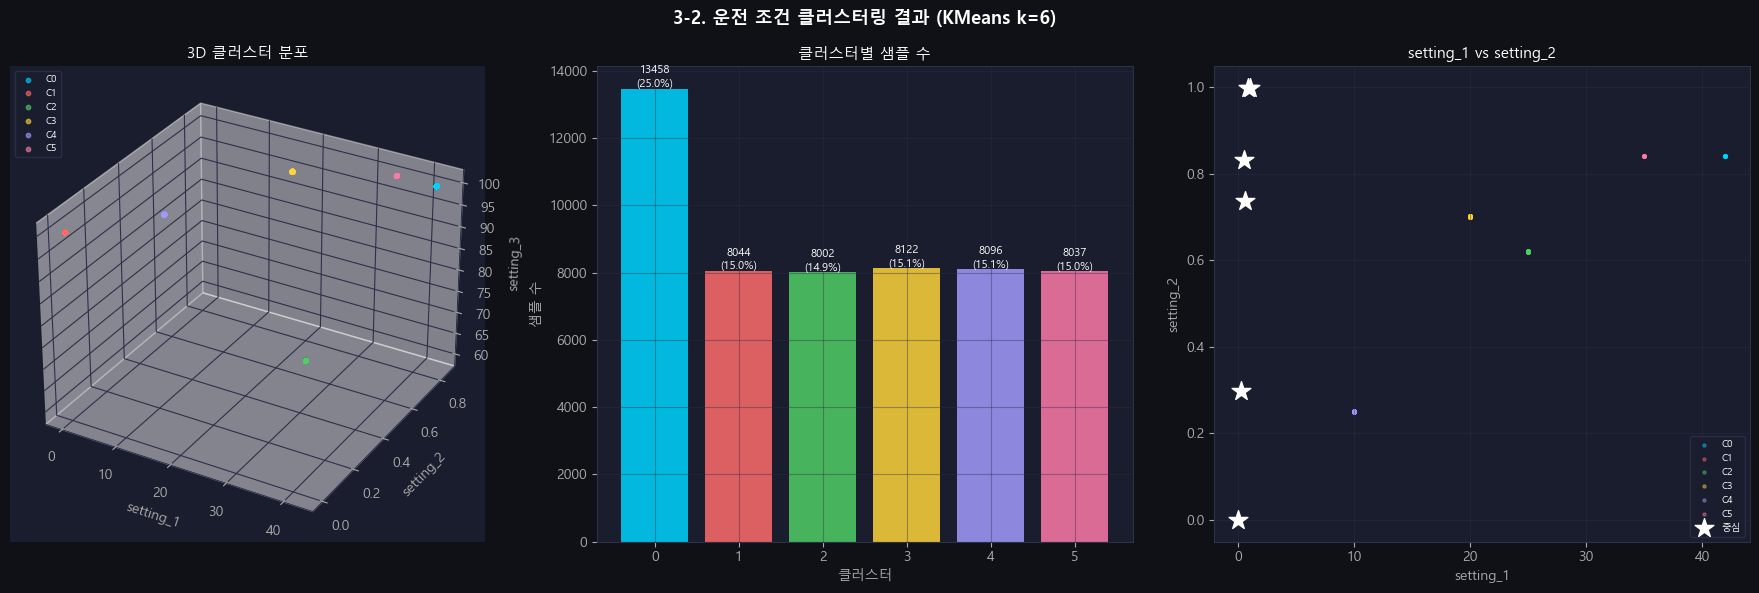

In [24]:
# ── [수정] OP_COLS 표준화 후 클러스터링 (setting_1 altitude 스케일이 압도적이라 필수) ──
op_scaler = MinMaxScaler()  # MinMax (스케일 통일 목적)
op_train_z = op_scaler.fit_transform(train_s1[OP_COLS])
op_test_z  = op_scaler.transform(test_s1[OP_COLS])

kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=20, max_iter=300)
kmeans.fit(op_train_z)

train_s1['op_cluster'] = kmeans.labels_
test_s1['op_cluster']  = kmeans.predict(op_test_z)

# EDA 호환을 위해 train_raw / test_raw 에도 동일하게 추가
train_raw['op_cluster'] = train_s1['op_cluster'].values
test_raw['op_cluster']  = test_s1['op_cluster'].values

# ── 클러스터별 운전 조건 평균 ─────────────────────────────────────────────
cluster_profile = train_raw.groupby('op_cluster')[OP_COLS + ['unit_nr']].agg(
    {'setting_1': 'mean', 'setting_2': 'mean', 'setting_3': 'mean', 'unit_nr': 'count'}
).rename(columns={'unit_nr': 'row_count'})
cluster_profile['비율(%)'] = (cluster_profile['row_count'] / len(train_raw) * 100).round(2)

print('=== 클러스터별 운전 조건 프로파일 ===')
display(cluster_profile.round(4))

# ── 시각화: 3D 클러스터 분포 ──────────────────────────────────────────────
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(18, 6))
fig.suptitle('3-2. 운전 조건 클러스터링 결과 (KMeans k=6)', fontsize=13, fontweight='bold')

# 3D scatter (샘플링)
ax3d = fig.add_subplot(131, projection='3d')
sample = train_raw.sample(min(3000, len(train_raw)), random_state=42)
for c in range(N_CLUSTERS):
    mask = sample['op_cluster'] == c
    ax3d.scatter(sample.loc[mask,'setting_1'], sample.loc[mask,'setting_2'],
                 sample.loc[mask,'setting_3'], c=CLUSTER_COLORS[c], s=10, alpha=0.6, label=f'C{c}')
ax3d.set_xlabel('setting_1'); ax3d.set_ylabel('setting_2'); ax3d.set_zlabel('setting_3')
ax3d.set_title('3D 클러스터 분포'); ax3d.legend(fontsize=7, loc='upper left')

# 클러스터별 비율
ax2 = fig.add_subplot(132)
counts = train_raw['op_cluster'].value_counts().sort_index()
bars = ax2.bar(counts.index, counts.values,
               color=[CLUSTER_COLORS[i] for i in counts.index], alpha=0.85)
ax2.set_xlabel('클러스터'); ax2.set_ylabel('샘플 수')
ax2.set_title('클러스터별 샘플 수')
for bar, v in zip(bars, counts.values):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+50,
             f'{v}\n({v/len(train_raw)*100:.1f}%)', ha='center', fontsize=8)

# setting_1 vs setting_2 산점도
ax3 = fig.add_subplot(133)
for c in range(N_CLUSTERS):
    mask = train_raw['op_cluster'] == c
    ax3.scatter(train_raw.loc[mask,'setting_1'], train_raw.loc[mask,'setting_2'],
                c=CLUSTER_COLORS[c], s=5, alpha=0.4, label=f'C{c}')
centers = kmeans.cluster_centers_
ax3.scatter(centers[:,0], centers[:,1], c='white', s=200, marker='*', zorder=5, label='중심')
ax3.set_xlabel('setting_1'); ax3.set_ylabel('setting_2')
ax3.set_title('setting_1 vs setting_2'); ax3.legend(fontsize=7)

plt.tight_layout(); plt.show()

## 3-3. 결정 3 — Piecewise RUL 생성 & Cap 설정

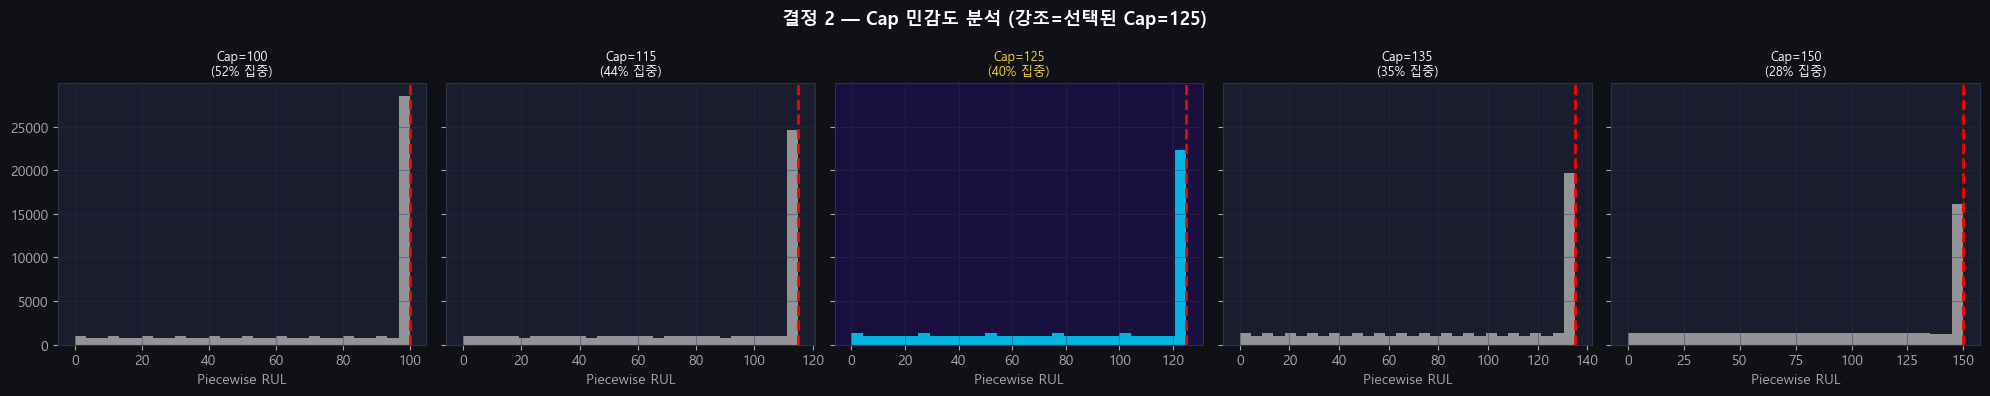

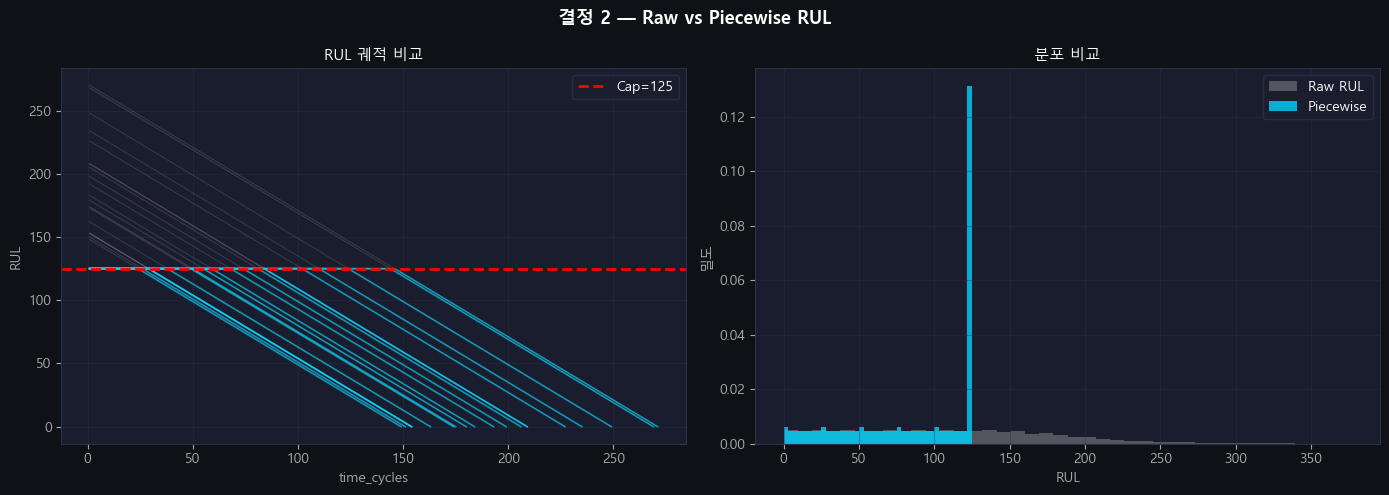

✅ 결정 2 완료  RUL Cap=125
   Raw RUL std=69.2 → Piecewise std=41.7


In [25]:
def add_piecewise_rul(df, cap=RUL_CAP):
    df = df.copy()
    mc = df.groupby('unit_nr')['time_cycles'].max().rename('max_c')
    df = df.join(mc, on='unit_nr')
    df['RUL_raw'] = df['max_c'] - df['time_cycles']
    df['RUL']     = df['RUL_raw'].clip(upper=cap)
    return df.drop('max_c', axis=1)

train_s2 = add_piecewise_rul(train_s1)
test_s2  = test_s1.copy()

# Cap 민감도 분석
caps = [100, 115, 125, 135, 150]
fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)
fig.suptitle('결정 2 — Cap 민감도 분석 (강조=선택된 Cap=125)', fontsize=13, fontweight='bold')

for ax, cap in zip(axes, caps):
    tmp = train_s2['RUL_raw'].clip(upper=cap)
    pct = (train_s2['RUL_raw']>=cap).mean()*100
    ax.hist(tmp, bins=30, color=C[0] if cap==RUL_CAP else GRAY, alpha=0.85, edgecolor='none')
    ax.axvline(cap, color='red', ls='--', lw=2)
    ax.set_title(f'Cap={cap}\n({pct:.0f}% 집중)',
                 color='#ffd43b' if cap==RUL_CAP else WHITE, fontsize=9)
    ax.set_xlabel('Piecewise RUL')
    if cap==RUL_CAP: ax.patch.set_facecolor('#1a1040')
plt.tight_layout(); plt.show()

# 전후 비교 (20개 엔진 궤적)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('결정 2 — Raw vs Piecewise RUL', fontsize=13, fontweight='bold')

ax = axes[0]
for u in train_s2['unit_nr'].unique()[:20]:
    sub = train_s2[train_s2['unit_nr']==u].sort_values('time_cycles')
    ax.plot(sub['time_cycles'], sub['RUL_raw'], color=GRAY,  alpha=0.2, lw=0.8)
    ax.plot(sub['time_cycles'], sub['RUL'],     color=C[0], alpha=0.6, lw=1.2)
ax.axhline(RUL_CAP, color='red', ls='--', lw=2, label=f'Cap={RUL_CAP}')
ax.set_xlabel('time_cycles'); ax.set_ylabel('RUL'); ax.set_title('RUL 궤적 비교'); ax.legend()

ax = axes[1]
ax.hist(train_s2['RUL_raw'], bins=40, alpha=0.4, color=GRAY,  density=True, label='Raw RUL')
ax.hist(train_s2['RUL'],     bins=40, alpha=0.8, color=C[0], density=True, label='Piecewise')
ax.set_xlabel('RUL'); ax.set_ylabel('밀도'); ax.set_title('분포 비교'); ax.legend()
plt.tight_layout(); plt.show()

print(f'✅ 결정 2 완료  RUL Cap={RUL_CAP}')
print(f'   Raw RUL std={train_s2["RUL_raw"].std():.1f} → Piecewise std={train_s2["RUL"].std():.1f}')

## 3-4. 결정 4 — 클러스터별 Gaussian 스무딩 (σ = 2)

> **FD001과 차이:** 전체 스무딩 → **클러스터별 스무딩**  
> 운전 조건이 섞인 채 스무딩하면 조건 전환 지점에서 인위적 평탄화가 발생함.  
> 같은 엔진 내에서도 클러스터(운전 조건) 단위로 따로 스무딩 적용.  
> **순서 변경:** val split 이전에 train 전체와 test 전체에 적용한 뒤 split을 진행.


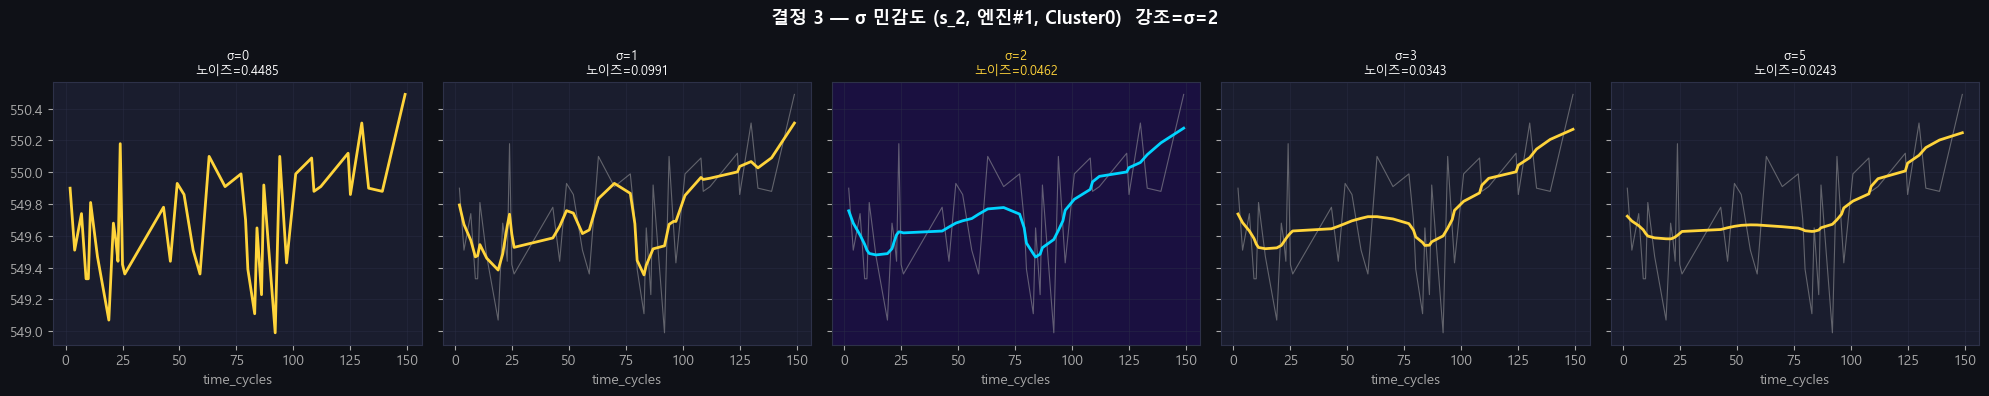

✅ 결정 3 완료  (클러스터별 Gaussian σ=2)


In [26]:
def apply_gaussian_by_cluster(df, features, sigma=GAUSS_SIGMA):
    """[벡터화] 엔진 × 클러스터 그룹별 Gaussian — groupby.transform"""
    df = df.copy().sort_values(['unit_nr', 'time_cycles']).reset_index(drop=True)
    grp = df.groupby(['unit_nr', 'op_cluster'])
    def _smooth(s: pd.Series):
        arr = s.values.astype(np.float32)
        if len(arr) > 1:
            return pd.Series(gaussian_filter1d(arr, sigma=sigma, mode='nearest'),
                             index=s.index)
        return s
    for s in features:
        df[s] = grp[s].transform(_smooth)
    return df

# val split 전에 train/test 전체에 적용
train_s3 = apply_gaussian_by_cluster(train_s2, USEFUL_SENSORS)
test_s3  = apply_gaussian_by_cluster(test_s2,  USEFUL_SENSORS)

# σ 민감도 비교 (엔진 #1, 대표 클러스터)
uid_ex = train_s2['unit_nr'].iloc[0]
c_ex   = train_s2[train_s2['unit_nr']==uid_ex]['op_cluster'].mode()[0]

# 클러스터 내 변동 있는 센서 자동 선택
_cluster_data = train_s2[train_s2['op_cluster']==c_ex]
varying = [s for s in USEFUL_SENSORS if _cluster_data[s].std() > 0.01]
s_ex = varying[0] if varying else USEFUL_SENSORS[0]

unit_sub = train_s2[(train_s2['unit_nr']==uid_ex) &
                    (train_s2['op_cluster']==c_ex)].sort_values('time_cycles')

sigmas = [0, 1, 2, 3, 5]
fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)
fig.suptitle(f'결정 3 — σ 민감도 ({s_ex}, 엔진#{uid_ex}, Cluster{c_ex})  강조=σ=2',
             fontsize=13, fontweight='bold')
for ax, sig in zip(axes, sigmas):
    y_raw = unit_sub[s_ex].values
    y_f   = gaussian_filter1d(y_raw, sigma=sig, mode='nearest') if sig>0 else y_raw
    noise = np.std(np.diff(y_f)) if len(y_f) > 1 else 0
    ax.plot(unit_sub['time_cycles'], y_raw, color=GRAY, alpha=0.5, lw=0.8)
    ax.plot(unit_sub['time_cycles'], y_f, color=C[0] if sig==GAUSS_SIGMA else C[3], lw=2)
    ax.set_title(f'σ={sig}\n노이즈={noise:.4f}',
                 color='#ffd43b' if sig==GAUSS_SIGMA else WHITE, fontsize=9)
    if sig==GAUSS_SIGMA: ax.patch.set_facecolor('#1a1040')
    ax.set_xlabel('time_cycles')
plt.tight_layout(); plt.show()
print(f'✅ 결정 3 완료  (클러스터별 Gaussian σ={GAUSS_SIGMA})')


## 3-5. 결정 5 — Validation 분할 (엔진 단위 단순 random)

> 엔진 단위 random split  (`random_state=42`, 8:2)  
> 누수 방지: 동일 엔진의 행이 sub-train ↔ val 사이에 절대 섞이지 않도록 unit_nr 기준 분리.


=== 결정 4 — 엔진 단위 random Validation 분할 완료 ===
  전체 엔진   : 260대
  Sub-train  : 208대
  Validation : 52대
  겹치는 엔진: 0대  ✅


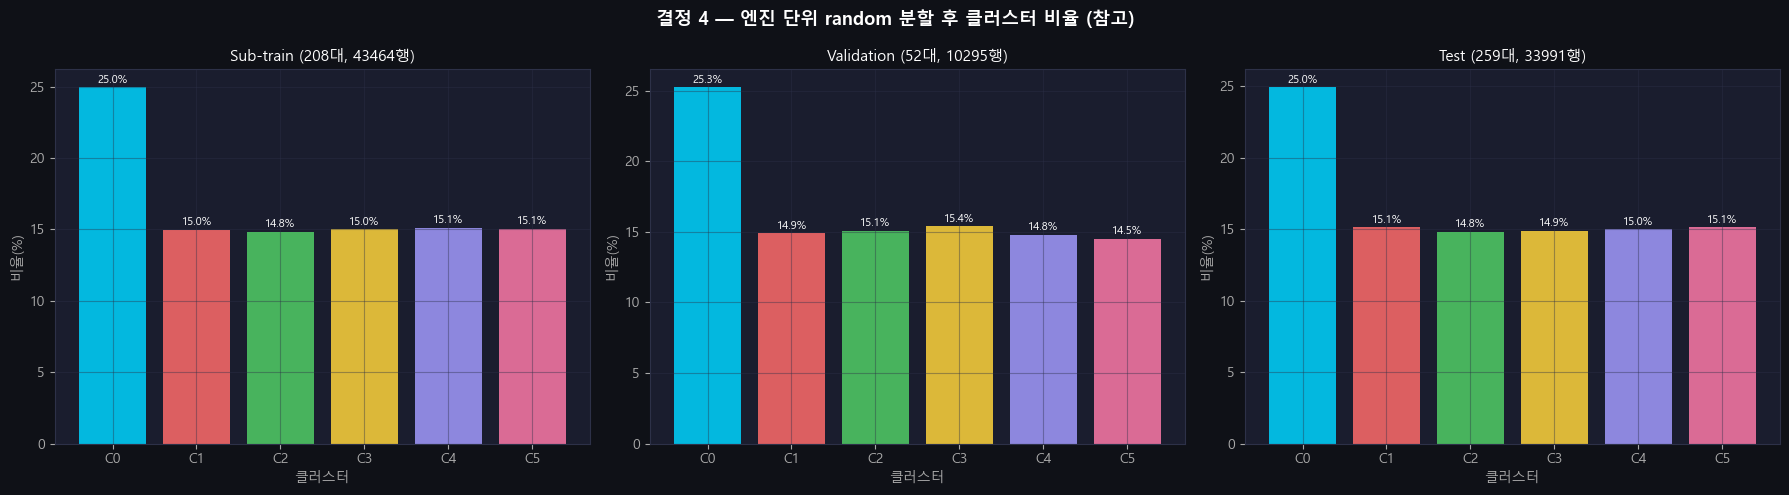

,구분,행 수,엔진 수,클러스터 수,RUL 포함
0,Sub-train,43464,208,6,예
1,Validation,10295,52,6,예
2,Test,33991,259,6,아니오


💾 분할 정보 저장: FD002_split_units_random42.json


In [27]:
VALID_RATIO  = 0.2
RANDOM_STATE = 42

# 엔진 단위 단순 random split (stratify 없음)
all_units = train_s3['unit_nr'].unique()
subtrain_units, valid_units = train_test_split(
    all_units,
    test_size=VALID_RATIO,
    random_state=RANDOM_STATE,
)

subtrain_common = train_s3[train_s3['unit_nr'].isin(subtrain_units)].copy().reset_index(drop=True)
valid_common    = train_s3[train_s3['unit_nr'].isin(valid_units)].copy().reset_index(drop=True)
test_common     = test_s3.copy()

# 누수 방지 검증
overlap = set(subtrain_units).intersection(set(valid_units))
assert len(overlap) == 0, f'❌ 엔진 겹침: {sorted(overlap)[:5]}'
assert len(subtrain_units) + len(valid_units) == len(all_units), '❌ 엔진 수 합 불일치'

print('=== 결정 4 — 엔진 단위 random Validation 분할 완료 ===')
print(f'  전체 엔진   : {len(all_units)}대')
print(f'  Sub-train  : {len(subtrain_units)}대')
print(f'  Validation : {len(valid_units)}대')
print(f'  겹치는 엔진: {len(overlap)}대  ✅')

# 분할 후 클러스터 비율 확인 (참고용)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('결정 4 — 엔진 단위 random 분할 후 클러스터 비율 (참고)', fontsize=13, fontweight='bold')

for ax, (df, title) in zip(axes, [
    (subtrain_common, 'Sub-train'),
    (valid_common,    'Validation'),
    (test_common,     'Test')
]):
    cnts = df['op_cluster'].value_counts().sort_index()
    pcts = cnts / cnts.sum() * 100
    ax.bar(pcts.index, pcts.values,
           color=[CLUSTER_COLORS[i] for i in pcts.index], alpha=0.85)
    ax.set_title(f'{title} ({df["unit_nr"].nunique()}대, {len(df)}행)')
    ax.set_xlabel('클러스터'); ax.set_ylabel('비율(%)')
    ax.set_xticks(range(N_CLUSTERS))
    ax.set_xticklabels([f'C{i}' for i in range(N_CLUSTERS)])
    for idx_c, v in pcts.items():
        ax.text(idx_c, v+0.3, f'{v:.1f}%', ha='center', fontsize=8)

plt.tight_layout(); plt.show()

# 분할 요약
split_summary = pd.DataFrame({
    '구분':      ['Sub-train', 'Validation', 'Test'],
    '행 수':     [len(subtrain_common), len(valid_common), len(test_common)],
    '엔진 수':   [subtrain_common['unit_nr'].nunique(),
                  valid_common['unit_nr'].nunique(),
                  test_common['unit_nr'].nunique()],
    '클러스터 수': [subtrain_common['op_cluster'].nunique(),
                    valid_common['op_cluster'].nunique(),
                    test_common['op_cluster'].nunique()],
    'RUL 포함':  ['예', '예', '아니오'],
})
display(split_summary)

split_info = {
    'random_state':   RANDOM_STATE,
    'valid_ratio':    VALID_RATIO,
    'split_method':   'engine-wise random (no stratify)',
    'subtrain_units': subtrain_units.tolist(),
    'valid_units':    valid_units.tolist(),
}
with open('FD002_split_units_random42.json', 'w', encoding='utf-8') as f:
    json.dump(split_info, f, ensure_ascii=False, indent=2)
print('💾 분할 정보 저장: FD002_split_units_random42.json')


## 3-6. 결정 6 — 클러스터별 MinMax 정규화

> **FD001과 가장 큰 차이:** 전체 MinMax → **클러스터별 MinMax**  
> 운전 조건별로 센서 스케일이 달라 동일 scaler 사용 시 정보 손실 발생.  
> fit은 **sub-train 클러스터별**로만, valid·test는 동일 scaler로 transform.

✅ 클러스터별 scaler 저장: FD002_scalers_by_cluster.pkl


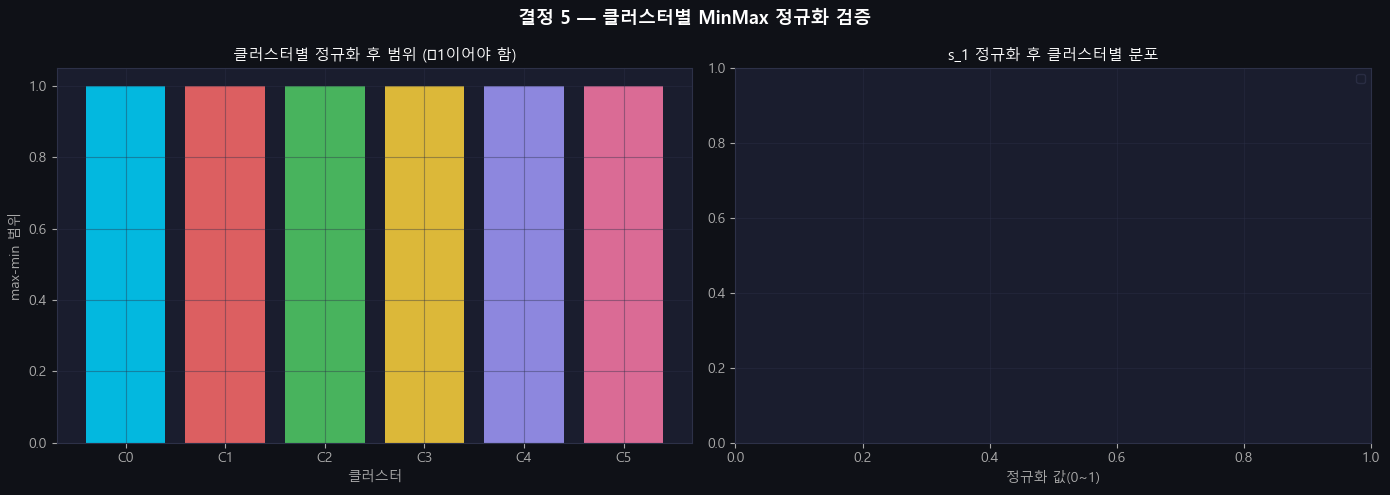

,클러스터,min,max,mean
0,C0,0.0,1.000000,0.305287
1,C1,0.0,1.000000,0.352198
2,C2,0.0,1.000000,0.350074
3,C3,0.0,1.000000,0.336112
4,C4,0.0,1.000000,0.379755
5,C5,0.0,1.000004,0.290791



✅ 결정 5 완료  클러스터별 MinMax 정규화 (6개 scaler 저장)


In [28]:
scalers = {}

subtrain_s4 = subtrain_common.copy()
valid_s4    = valid_common.copy()
test_s4     = test_common.copy()

# fit: sub-train 클러스터별
for c in range(N_CLUSTERS):
    mask = subtrain_s4['op_cluster'] == c
    if mask.sum() == 0:
        scaler_c = MinMaxScaler() if SCALER_TYPE == 'minmax' else StandardScaler()
        scaler_c.fit(subtrain_s4[USEFUL_SENSORS])
    else:
        scaler_c = MinMaxScaler() if SCALER_TYPE == 'minmax' else StandardScaler()
        subtrain_s4.loc[mask, USEFUL_SENSORS] = scaler_c.fit_transform(
            subtrain_s4.loc[mask, USEFUL_SENSORS])
    scalers[c] = scaler_c

# transform: valid, test
for df_name, df_target in [('valid', valid_s4), ('test', test_s4)]:
    for c in range(N_CLUSTERS):
        mask = df_target['op_cluster'] == c
        if mask.sum() > 0:
            df_target.loc[mask, USEFUL_SENSORS] = scalers[c].transform(
                df_target.loc[mask, USEFUL_SENSORS])

joblib.dump(scalers, 'FD002_scalers_by_cluster.pkl')
print('✅ 클러스터별 scaler 저장: FD002_scalers_by_cluster.pkl')

# 정규화 검증
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('결정 5 — 클러스터별 MinMax 정규화 검증', fontsize=13, fontweight='bold')

range_data = []
for c in range(N_CLUSTERS):
    mask = subtrain_s4['op_cluster'] == c
    sub  = subtrain_s4.loc[mask, USEFUL_SENSORS]
    range_data.append({'클러스터': f'C{c}', 'min': sub.min().min(), 'max': sub.max().max(),
                       'mean': sub.mean().mean()})
range_df = pd.DataFrame(range_data)

axes[0].bar(range_df['클러스터'], range_df['max'] - range_df['min'],
            color=[CLUSTER_COLORS[i] for i in range(N_CLUSTERS)], alpha=0.85)
axes[0].set_xlabel('클러스터'); axes[0].set_ylabel('max-min 범위')
axes[0].set_title('클러스터별 정규화 후 범위 (≈1이어야 함)')

# 전후 분포 비교 (대표 센서)
s_show = USEFUL_SENSORS[0]
for c in range(N_CLUSTERS):
    mask = subtrain_s4['op_cluster'] == c
    data = subtrain_s4.loc[mask, s_show]
    if len(data) > 1:
        try: data.plot.kde(ax=axes[1], color=CLUSTER_COLORS[c], lw=1.5, label=f'C{c}')
        except: pass
axes[1].set_title(f'{s_show} 정규화 후 클러스터별 분포')
axes[1].set_xlabel('정규화 값(0~1)'); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

display(range_df)
print(f'\n✅ 결정 5 완료  클러스터별 MinMax 정규화 (6개 scaler 저장)')

## 4. DL 분기 — 슬라이딩 윈도우

In [29]:
def create_sliding_windows(df, feature_cols, target_col=None,
                           window_size=WINDOW_SIZE, step=STEP):
    X_list, y_list = [], []
    for uid in np.sort(df['unit_nr'].unique()):
        udf  = df[df['unit_nr']==uid].sort_values('time_cycles')
        data = udf[feature_cols].values.astype(np.float32)
        tgt  = udf[target_col].values if target_col else None
        n    = len(data)
        for start in range(0, n - window_size + 1, step):
            end = start + window_size
            X_list.append(data[start:end])
            if tgt is not None:
                y_list.append(tgt[end-1])
    X = np.array(X_list, dtype=np.float32)
    y = np.array(y_list, dtype=np.float32) if y_list else None
    return X, y

def create_test_windows(df, feature_cols, rul_series, window_size=WINDOW_SIZE):
    X_list, y_list = [], []
    for i, uid in enumerate(np.sort(df['unit_nr'].unique())):
        udf  = df[df['unit_nr']==uid].sort_values('time_cycles')
        data = udf[feature_cols].values.astype(np.float32)
        if len(data) >= window_size:
            X_list.append(data[-window_size:])
        else:
            pad = np.zeros((window_size - len(data), len(feature_cols)), dtype=np.float32)
            X_list.append(np.vstack([pad, data]))
        y_list.append(float(rul_series.iloc[i]))
    return np.array(X_list, dtype=np.float32), np.array(y_list, dtype=np.float32)

def windows_to_long_df(X, y, feature_cols):
    """[벡터화] reshape 한 번으로 long format 생성 (수십 배 빠름)"""
    n_samples, win_size, n_feat = X.shape
    sample_id = np.repeat(np.arange(n_samples), win_size)
    timestep  = np.tile(np.arange(win_size), n_samples)
    flat = X.reshape(n_samples * win_size, n_feat)
    df = pd.DataFrame(flat, columns=list(feature_cols))
    df.insert(0, 'timestep', timestep)
    df.insert(0, 'sample_id', sample_id)
    df['RUL'] = np.repeat(np.asarray(y, dtype=np.float32), win_size)
    return df

print('✅ 슬라이딩 윈도우 함수 정의 완료')
print(f'   create_sliding_windows / create_test_windows / windows_to_long_df')

✅ 슬라이딩 윈도우 함수 정의 완료
   create_sliding_windows / create_test_windows / windows_to_long_df


### 3-7 결정 7. DL 피처에 OHE 추가 (클러스터 채널 concat)

> **방법 1 (단순·효과적):** 정규화된 센서 피처 끝에 `cluster_0~5` 채널을 직접 붙여  
> 윈도우 텐서를 `(N, window_size, n_sensors + 6)` 형태로 구성.  
> 모델이 타임스텝마다 운전 조건 정보를 함께 참조할 수 있음.

DL_FEATURES 구성:
  센서:    20개  → ['s_1', 's_2', 's_3', 's_4', 's_5', 's_6', 's_7', 's_8', 's_9', 's_10', 's_11', 's_12', 's_13', 's_14', 's_15', 's_17', 's_18', 's_19', 's_20', 's_21']
  OHE:     6개  → ['cluster_0', 'cluster_1', 'cluster_2', 'cluster_3', 'cluster_4', 'cluster_5']
  합계:    26개

=== [DL] 슬라이딩 윈도우 생성 완료 (OHE 포함) ===
X_subtrain_dl : (39512, 20, 26)   ← (샘플, 20, 26채널)
X_valid_dl    : (9307, 20, 26)
X_test_dl     : (259, 20, 26)


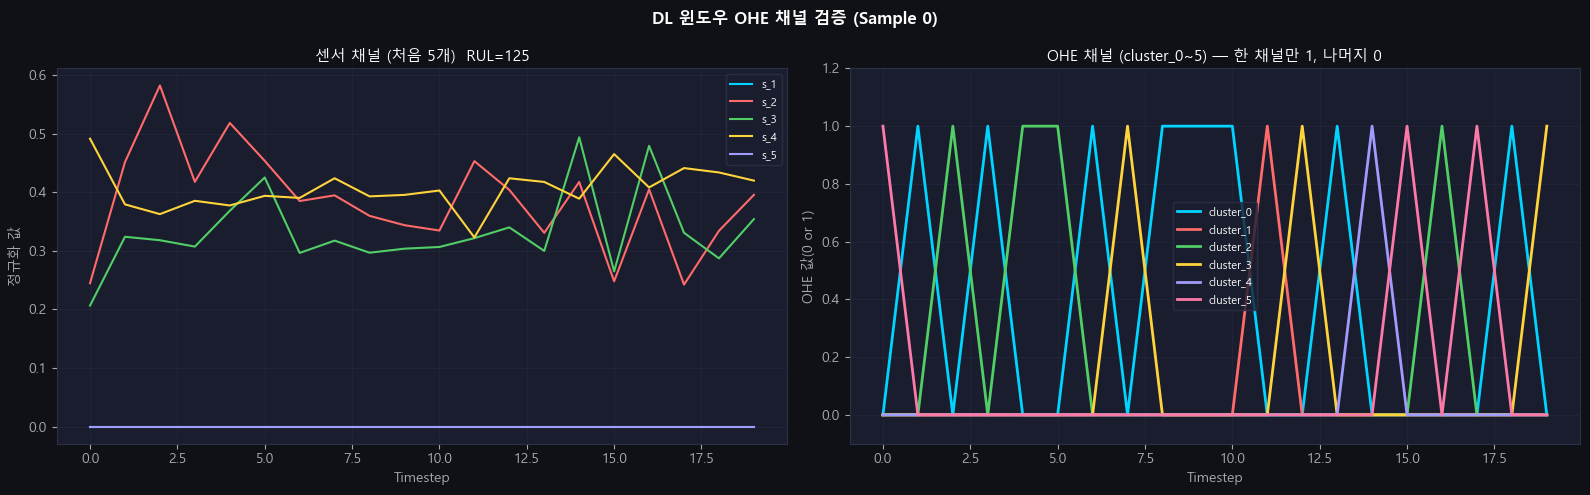


OHE 정합성 (모든 타임스텝 합=1): ✅
활성 클러스터: ['cluster_5']

Long Format shape:
  subtrain: (790240, 29)
  valid   : (186140, 29)
  test    : (5180, 29)


In [30]:
# ── OHE 컬럼 정의 및 DL용 데이터 생성 ───────────────────────────────────
OHE_COLS = [f'cluster_{i}' for i in range(N_CLUSTERS)]

def add_ohe_cluster(df, all_ohe_cols=OHE_COLS):
    """op_cluster → 원핫인코딩 후 기존 df에 concat"""
    ohe = pd.get_dummies(df['op_cluster'], prefix='cluster').astype(np.float32)
    for col in all_ohe_cols:
        if col not in ohe.columns:
            ohe[col] = np.float32(0.0)
    return pd.concat([df.reset_index(drop=True),
                      ohe[all_ohe_cols].reset_index(drop=True)], axis=1)

# DL용 OHE 추가 (ML용 subtrain_ml과 별개)
subtrain_dl = add_ohe_cluster(subtrain_s4)
valid_dl    = add_ohe_cluster(valid_s4)
test_dl     = add_ohe_cluster(test_s4)

# ── DL 피처: 센서 + OHE 클러스터 ────────────────────────────────────────
DL_FEATURES = USEFUL_SENSORS + OHE_COLS

print(f'DL_FEATURES 구성:')
print(f'  센서:    {len(USEFUL_SENSORS)}개  → {USEFUL_SENSORS}')
print(f'  OHE:     {len(OHE_COLS)}개  → {OHE_COLS}')
print(f'  합계:    {len(DL_FEATURES)}개')
print()

# ── 슬라이딩 윈도우 생성 ─────────────────────────────────────────────────
X_subtrain_dl, y_subtrain_dl = create_sliding_windows(subtrain_dl, DL_FEATURES, 'RUL')
X_valid_dl,    y_valid_dl    = create_sliding_windows(valid_dl,    DL_FEATURES, 'RUL')
X_test_dl,     y_test_dl     = create_test_windows(  test_dl,     DL_FEATURES, rul_df['RUL'])

print('=== [DL] 슬라이딩 윈도우 생성 완료 (OHE 포함) ===')
print(f'X_subtrain_dl : {X_subtrain_dl.shape}   ← (샘플, {WINDOW_SIZE}, {len(DL_FEATURES)}채널)')
print(f'X_valid_dl    : {X_valid_dl.shape}')
print(f'X_test_dl     : {X_test_dl.shape}')

# ── OHE 채널 확인: 마지막 6채널이 0/1인지 검증 ───────────────────────────
sample_window = X_subtrain_dl[0]
ohe_channels  = sample_window[:, len(USEFUL_SENSORS):]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('DL 윈도우 OHE 채널 검증 (Sample 0)', fontsize=12, fontweight='bold')

ax = axes[0]
for fi in range(min(5, len(USEFUL_SENSORS))):
    ax.plot(sample_window[:, fi], color=C[fi], lw=1.5, label=USEFUL_SENSORS[fi])
ax.set_title(f'센서 채널 (처음 5개)  RUL={y_subtrain_dl[0]:.0f}')
ax.set_xlabel('Timestep'); ax.set_ylabel('정규화 값'); ax.legend(fontsize=8)

ax = axes[1]
for ci in range(N_CLUSTERS):
    ax.plot(ohe_channels[:, ci], color=CLUSTER_COLORS[ci],
            lw=2, label=f'cluster_{ci}')
ax.set_title('OHE 채널 (cluster_0~5) — 한 채널만 1, 나머지 0')
ax.set_xlabel('Timestep'); ax.set_ylabel('OHE 값(0 or 1)')
ax.set_ylim(-0.1, 1.2); ax.legend(fontsize=8)

plt.tight_layout(); plt.show()

# OHE 정합성: 각 타임스텝에서 OHE 합 = 1
ohe_rowsums = ohe_channels.sum(axis=1)
ok = np.all(ohe_rowsums == 1)
print(f'\nOHE 정합성 (모든 타임스텝 합=1): {"✅" if ok else "❌"}')
print(f'활성 클러스터: {[OHE_COLS[i] for i in np.where(ohe_channels[0] == 1)[0]]}')

# ── Long Format 생성 ─────────────────────────────────────────────────────
dl_subtrain_long = windows_to_long_df(X_subtrain_dl, y_subtrain_dl, DL_FEATURES)
dl_valid_long    = windows_to_long_df(X_valid_dl,    y_valid_dl,    DL_FEATURES)
dl_test_long     = windows_to_long_df(X_test_dl,     y_test_dl,     DL_FEATURES)

print(f'\nLong Format shape:')
print(f'  subtrain: {dl_subtrain_long.shape}')
print(f'  valid   : {dl_valid_long.shape}')
print(f'  test    : {dl_test_long.shape}')

---
## 5. CSV 저장 & 최종 요약

In [31]:
OUTPUT_DIR = 'preprocessed_FD002'
os.makedirs(OUTPUT_DIR, exist_ok=True)
dl_dir = os.path.join(OUTPUT_DIR, 'dl')
os.makedirs(dl_dir, exist_ok=True)

# 파일 경로
dl_subtrain_path = os.path.join(dl_dir, 'FD002_dl_subtrain_long.csv')
dl_valid_path    = os.path.join(dl_dir, 'FD002_dl_valid_long.csv')
dl_test_path     = os.path.join(dl_dir, 'FD002_dl_test_long.csv')
rul_path         = os.path.join(OUTPUT_DIR, 'FD002_test_RUL.csv')
scaler_path      = os.path.join(OUTPUT_DIR, 'FD002_scalers_by_cluster.pkl')
dl_feat_path     = os.path.join(OUTPUT_DIR, 'FD002_dl_features.txt')
kmeans_path      = os.path.join(OUTPUT_DIR, 'FD002_kmeans.pkl')
op_scaler_path   = os.path.join(OUTPUT_DIR, 'FD002_op_scaler.pkl')

# DL Long Format 저장
dl_subtrain_long.to_csv(dl_subtrain_path, index=False)
dl_valid_long.to_csv(dl_valid_path,       index=False)
dl_test_long.to_csv(dl_test_path,         index=False)

# RUL 저장
rul_df.to_csv(rul_path, index=False)

# 모델 파일 저장
joblib.dump(scalers,   scaler_path)
joblib.dump(kmeans,    kmeans_path)
joblib.dump(op_scaler, op_scaler_path)

# DL 피처 목록 저장
with open(dl_feat_path, 'w', encoding='utf-8') as f:
    for col in DL_FEATURES: f.write(f'{col}\n')

# 저장 검증
chk_sub = pd.read_csv(dl_subtrain_path)
chk_val = pd.read_csv(dl_valid_path)
chk_te  = pd.read_csv(dl_test_path)

print('=' * 60)
print('  FD002 DL 전처리 파이프라인 완료')
print('=' * 60)
print()
print('■ 공통 파이프라인')
print('  상수 센서 제거 → KMeans(k=6) → RUL Cap=125')
print('  → Gaussian(σ=2) → 엔진 단위 Val 분리')
print('  → 클러스터별 MinMax 정규화 → OHE → 슬라이딩 윈도우')

print()
print('■ DL 분기 — 슬라이딩 윈도우 Long Format')
dl_summary = pd.DataFrame({
    '구분':        ['Sub-train', 'Validation', 'Test'],
    'shape':       [str(chk_sub.shape), str(chk_val.shape), str(chk_te.shape)],
    '샘플 수':     [X_subtrain_dl.shape[0], X_valid_dl.shape[0], X_test_dl.shape[0]],
    'window_size': [WINDOW_SIZE]*3,
    'DL피처 수':   [len(DL_FEATURES)]*3,
}).set_index('구분')
display(dl_summary)

print()
print('■ 저장 파일 목록')
print(f'   DL  : dl/FD002_dl_subtrain/valid/test_long.csv')
print(f'   모델: FD002_kmeans.pkl  FD002_scalers_by_cluster.pkl')
print(f'   분할: FD002_split_units_random42.json')
print(f'   설정: {CONFIG}')

  FD002 DL 전처리 파이프라인 완료

■ 공통 파이프라인
  상수 센서 제거 → KMeans(k=6) → RUL Cap=125
  → Gaussian(σ=2) → 엔진 단위 Val 분리
  → 클러스터별 MinMax 정규화 → OHE → 슬라이딩 윈도우

■ DL 분기 — 슬라이딩 윈도우 Long Format


,shape,샘플 수,window_size,DL피처 수
구분,,,,
Sub-train,"(790240, 29)",39512,20,26
Validation,"(186140, 29)",9307,20,26
Test,"(5180, 29)",259,20,26



■ 저장 파일 목록
   DL  : dl/FD002_dl_subtrain/valid/test_long.csv
   모델: FD002_kmeans.pkl  FD002_scalers_by_cluster.pkl
   분할: FD002_split_units_random42.json
   설정: {'RUL_CAP': 125, 'GAUSS_SIGMA': 2, 'SCALER_TYPE': 'minmax', 'WINDOW_SIZE': 20}
